<a href="https://colab.research.google.com/github/MrSirBeta/ProgrammingAssignment2RStudio/blob/main/AT_IT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas matplotlib openpyxl

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Subir el archivo desde Google Colab
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Leer el archivo Excel (desde la fila 2, por eso header=1)
df = pd.read_excel(file_name, header=1)


Saving 2024.xlsx to 2024 (1).xlsx


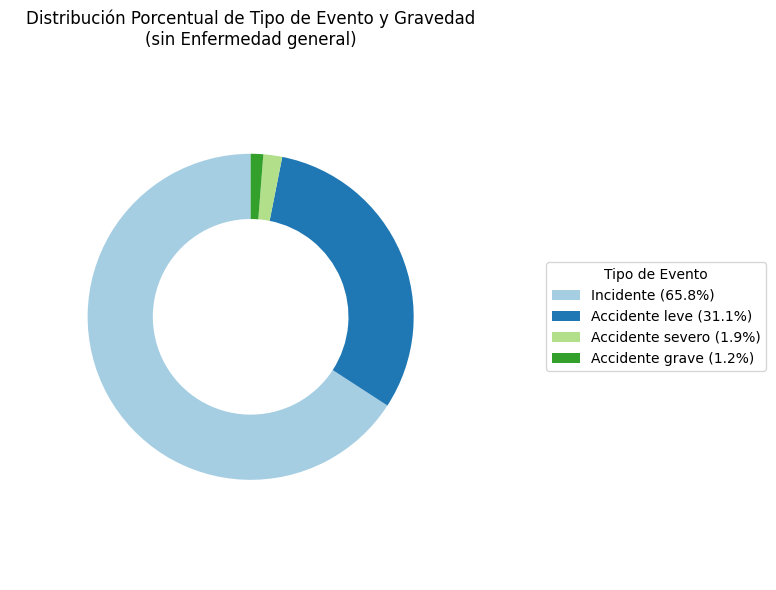

In [ ]:
import matplotlib.pyplot as plt

# Limpiar los nombres de las columnas
df.columns = df.columns.str.replace('\n', ' ', regex=True).str.strip()

# FILTRO: Eliminar registros donde el tipo de evento sea "Enfermedad general"
df = df[df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].str.strip().str.lower() != 'enfermedad general']

# Contar ocurrencias por tipo de evento y gravedad
eventos_gravedad_counts = df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].value_counts()

# Calcular porcentajes
total = eventos_gravedad_counts.sum()
labels_con_porcentaje = [
    f"{label} ({count / total:.1%})"
    for label, count in zip(eventos_gravedad_counts.index, eventos_gravedad_counts.values)
]

# Crear gráfico circular
plt.figure(figsize=(8, 6))
plt.pie(
    eventos_gravedad_counts,
    startangle=90,
    colors=plt.cm.Paired.colors,
    labels=None,
    wedgeprops=dict(width=0.4)  # Donut-style para mejor visibilidad
)

# Leyenda al costado con porcentajes
plt.legend(
    labels=labels_con_porcentaje,
    title="Tipo de Evento",
    bbox_to_anchor=(1.1, 0.5),
    loc="center left"
)

plt.title('Distribución Porcentual de Tipo de Evento y Gravedad\n(sin Enfermedad general)')
plt.axis('equal')
plt.tight_layout()
plt.show()


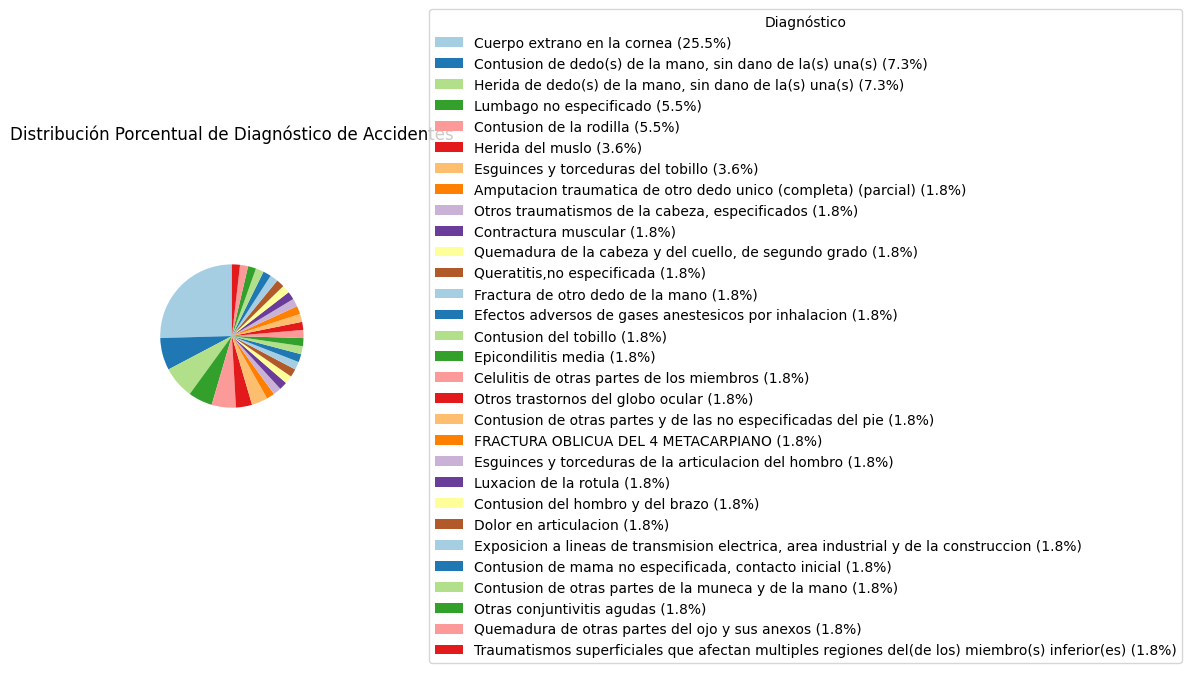

In [ ]:
import matplotlib.pyplot as plt

# Limpiar los nombres de las columnas
df.columns = df.columns.str.replace('\n', ' ', regex=True).str.strip()

# FILTRO: Eliminar registros donde el diagnóstico sea "Enfermedad general"
df = df[df['DESCRIPCIÓN DE DIAGNOSTICO'].str.strip().str.lower() != 'enfermedad general']

# Contar ocurrencias por diagnóstico
eventos_gravedad_counts = df['DESCRIPCIÓN DE DIAGNOSTICO'].value_counts()

# Calcular porcentajes
total = eventos_gravedad_counts.sum()
labels_con_porcentaje = [
    f"{label} ({count / total:.1%})"
    for label, count in zip(eventos_gravedad_counts.index, eventos_gravedad_counts.values)
]

# Crear gráfico circular sin etiquetas ni porcentajes dentro
plt.figure(figsize=(12, 6))
plt.pie(
    eventos_gravedad_counts,
    startangle=90,
    colors=plt.cm.Paired.colors
)

# Leyenda con porcentajes al costado
plt.legend(
    labels=labels_con_porcentaje,
    title="Diagnóstico",
    bbox_to_anchor=(1.1, 0.5),
    loc="center left"
)

plt.title('Distribución Porcentual de Diagnóstico de Accidentes')
plt.axis('equal')
plt.tight_layout()
plt.show()


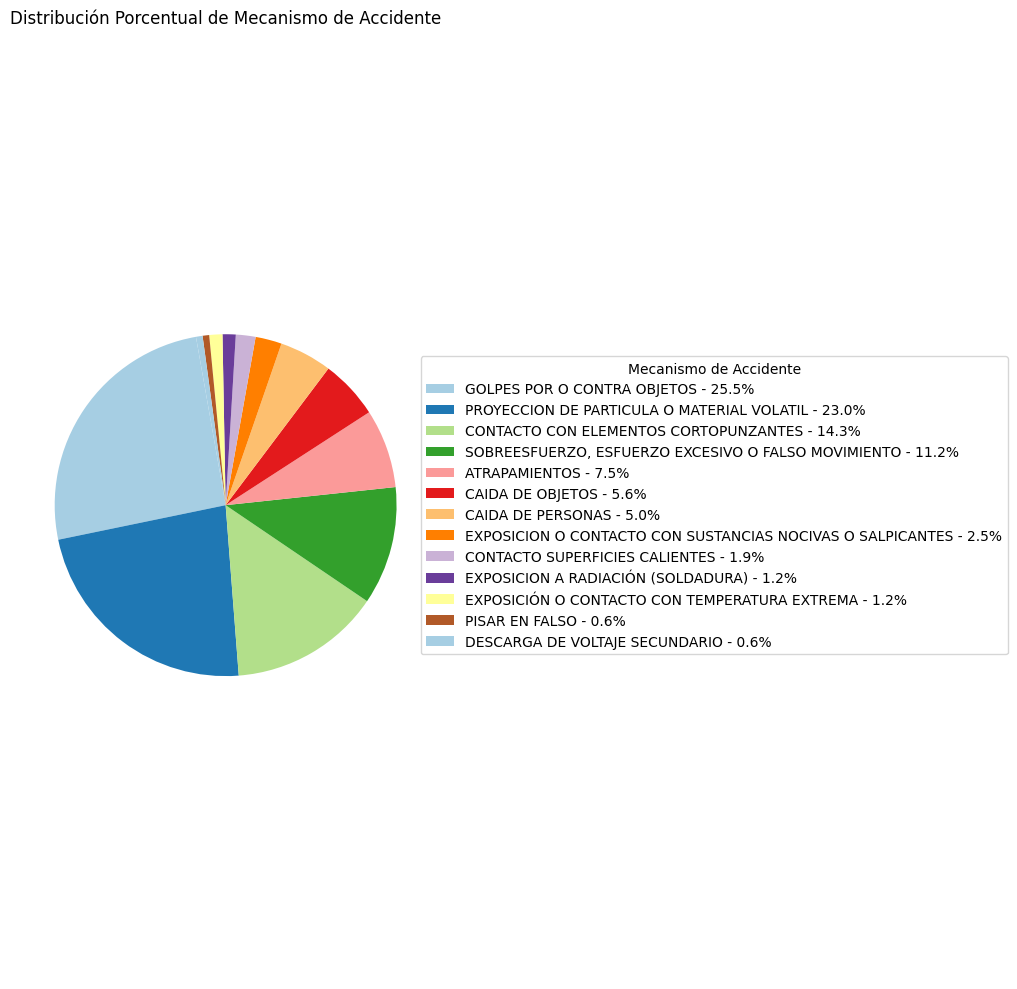

In [ ]:
# Filtrar datos válidos
df = df[df['MECANISMO DE ACCIDENTE'].notna()]

# Contar mecanismos de accidente
mecanismo_counts = df['MECANISMO DE ACCIDENTE'].str.strip().value_counts()

# Calcular etiquetas con porcentaje para la leyenda
labels = [f"{label} - {count / mecanismo_counts.sum() * 100:.1f}%"
          for label, count in mecanismo_counts.items()]

# Crear gráfico de torta
plt.figure(figsize=(10, 10))
plt.pie(mecanismo_counts, startangle=100, colors=plt.cm.Paired.colors)
plt.title('Distribución Porcentual de Mecanismo de Accidente')
plt.axis('equal')  # Para mantener el círculo perfecto

# Leyenda al costado
plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0.5), title="Mecanismo de Accidente")
plt.tight_layout()
plt.show()


/tmp/ipython-input-3737700182.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


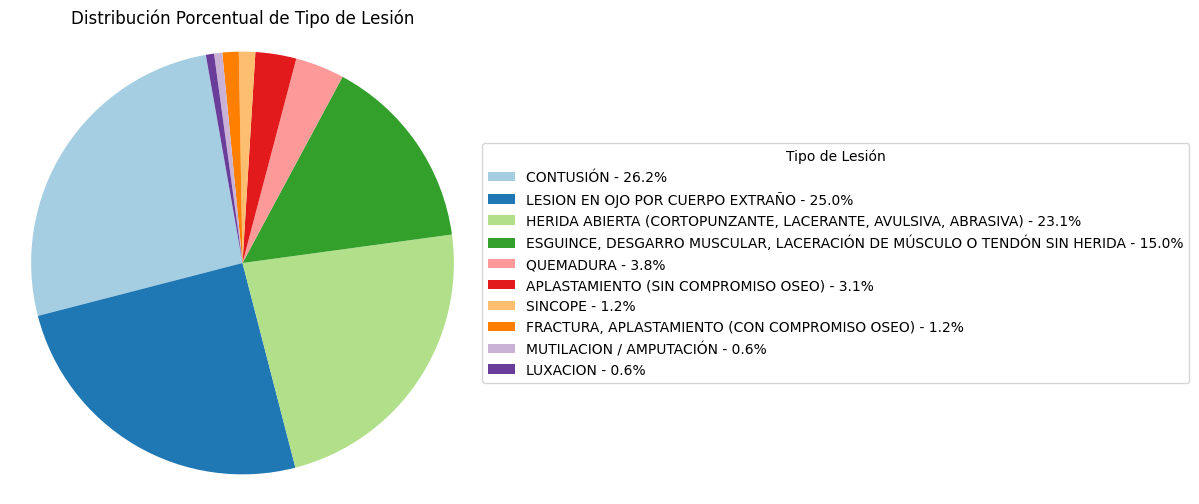

In [ ]:
# Filtrar datos válidos
df = df[df['TIPO DE LESIÓN'].notna()]

# Contar tipos de lesión
tipos_lesion_counts = df['TIPO DE LESIÓN'].str.strip().value_counts()

# Calcular porcentajes manualmente para la leyenda
labels = [f"{label} - {count / tipos_lesion_counts.sum() * 100:.1f}%"
          for label, count in tipos_lesion_counts.items()]

# Gráfico circular sin texto dentro
plt.figure(figsize=(6, 6))
plt.pie(tipos_lesion_counts, startangle=100, colors=plt.cm.Paired.colors)
plt.title('Distribución Porcentual de Tipo de Lesión')
plt.axis('equal')  # Para que sea un círculo

# Leyenda al costado con porcentajes
plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0.5), title="Tipo de Lesión")
plt.tight_layout()
plt.show()



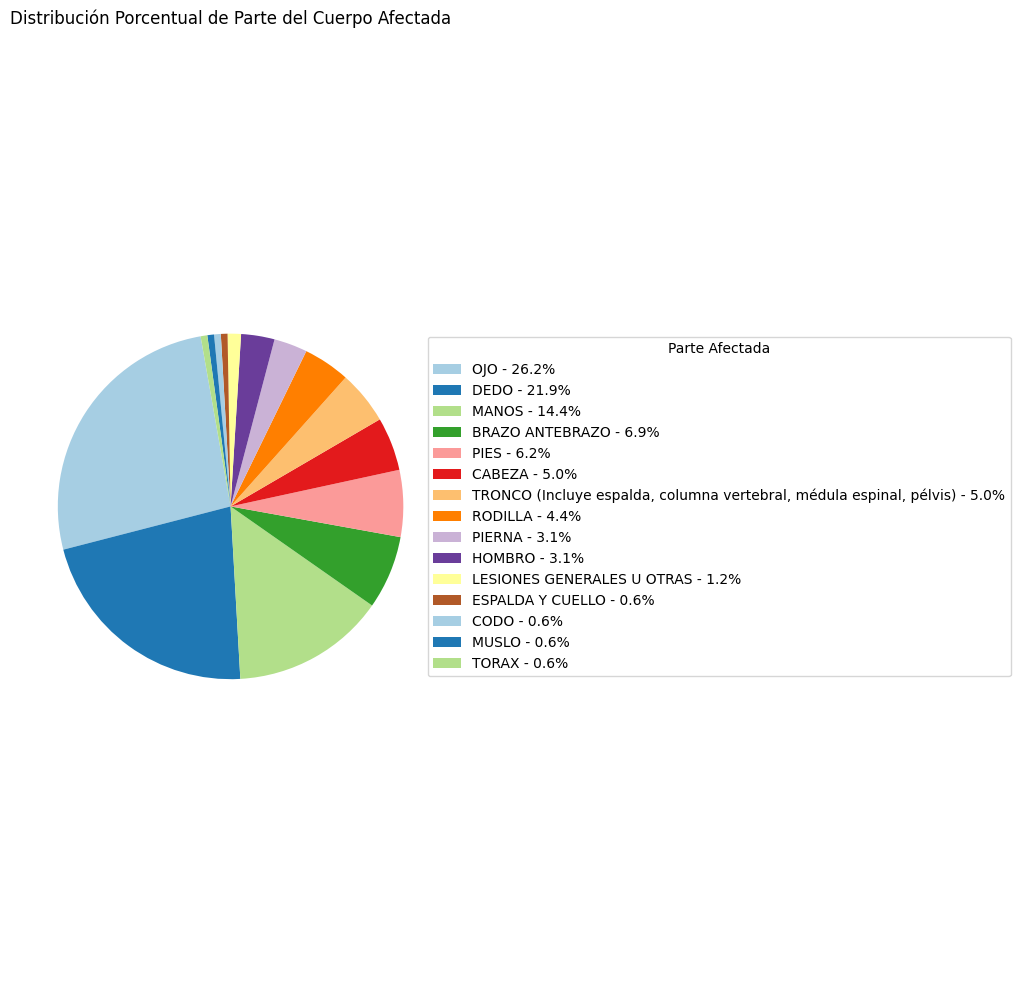

In [ ]:
# Filtrar datos válidos
df = df[df['PARTE DEL CUERPO AFECTADA'].notna()]

# Contar partes del cuerpo afectadas
parte_afectada_counts = df['PARTE DEL CUERPO AFECTADA'].str.strip().value_counts()

# Calcular etiquetas con porcentaje
labels = [f"{label} - {count / parte_afectada_counts.sum() * 100:.1f}%"
          for label, count in parte_afectada_counts.items()]

# Crear gráfico de torta
plt.figure(figsize=(10, 10))
plt.pie(parte_afectada_counts, startangle=100, colors=plt.cm.Paired.colors)
plt.title('Distribución Porcentual de Parte del Cuerpo Afectada')
plt.axis('equal')

# Leyenda externa con porcentajes
plt.legend(labels, loc='center left', bbox_to_anchor=(1, 0.5), title="Parte Afectada")
plt.tight_layout()
plt.show()


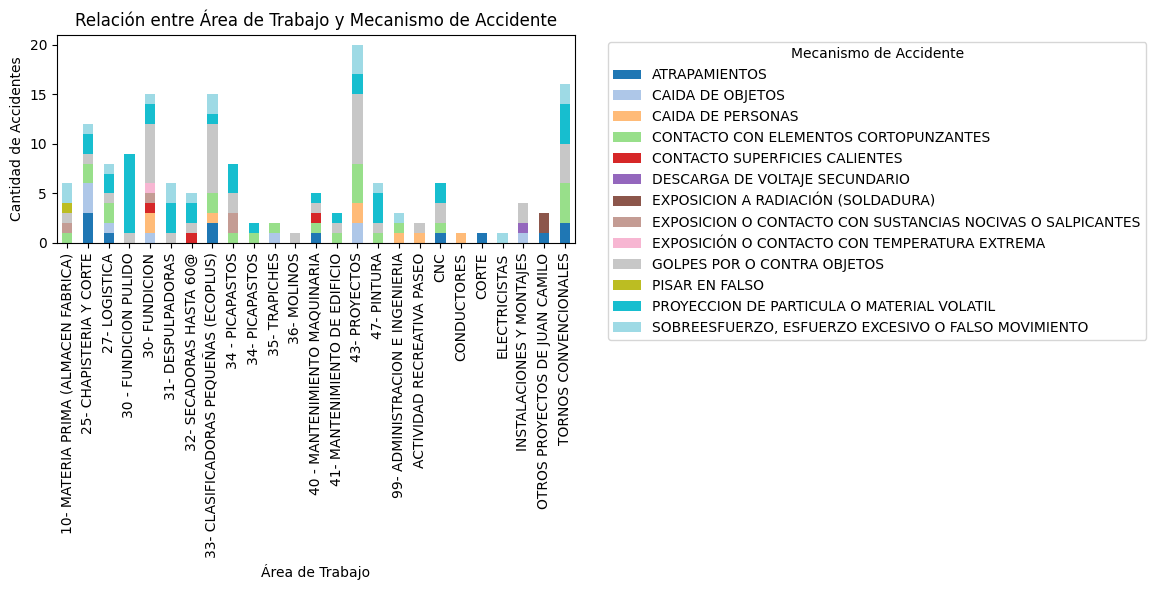

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar datos válidos
df_filtered = df[df['ÁREA DE TRABAJO'].notna() & df['MECANISMO DE ACCIDENTE'].notna()]

# Tabla cruzada
tabla_cruzada = pd.crosstab(df_filtered['ÁREA DE TRABAJO'].str.strip(),
                             df_filtered['MECANISMO DE ACCIDENTE'].str.strip())

# Crear gráfico de barras apiladas
tabla_cruzada.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')
plt.title('Relación entre Área de Trabajo y Mecanismo de Accidente')
plt.xlabel('Área de Trabajo')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(rotation=90)
plt.legend(title='Mecanismo de Accidente', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


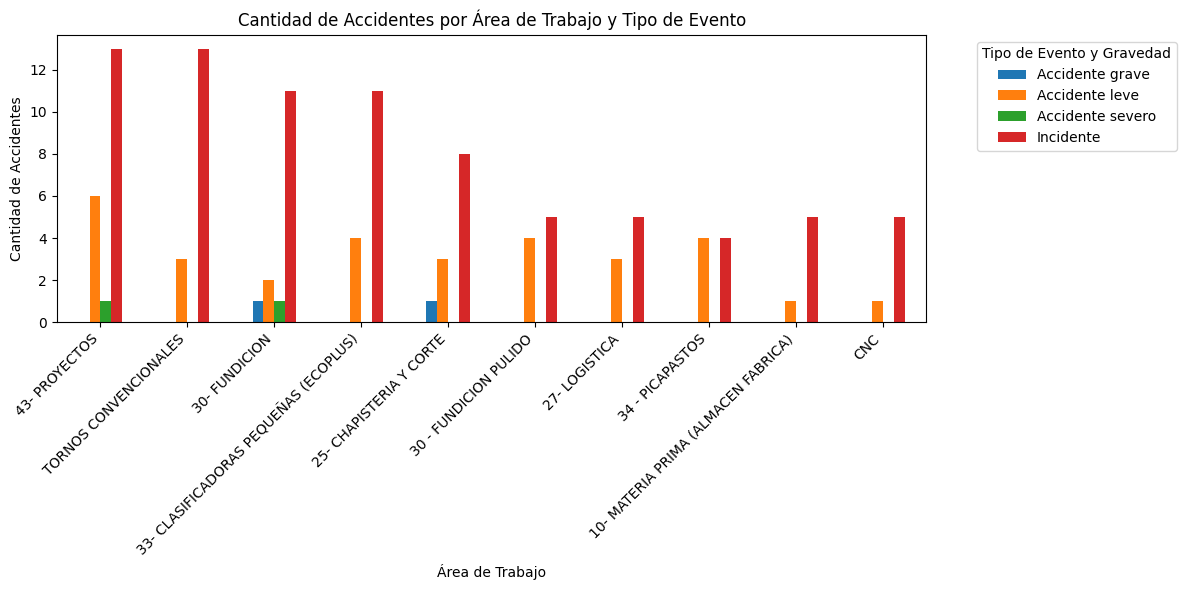

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrar datos válidos
df_filtered = df[
    df['ÁREA DE TRABAJO'].notna() &
    df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna()
]

# Crear tabla cruzada
tabla_eventos = pd.crosstab(
    df_filtered['ÁREA DE TRABAJO'].str.strip(),
    df_filtered['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].str.strip()
)

# Seleccionar solo las 10 áreas con más registros (opcional)
tabla_eventos = tabla_eventos.loc[tabla_eventos.sum(axis=1).sort_values(ascending=False).head(10).index]

# Graficar barras agrupadas
tabla_eventos.plot(kind='bar', figsize=(12, 6))
plt.title('Cantidad de Accidentes por Área de Trabajo y Tipo de Evento')
plt.xlabel('Área de Trabajo')
plt.ylabel('Cantidad de Accidentes')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Evento y Gravedad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


/tmp/ipython-input-163390148.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', len(mecanismos))


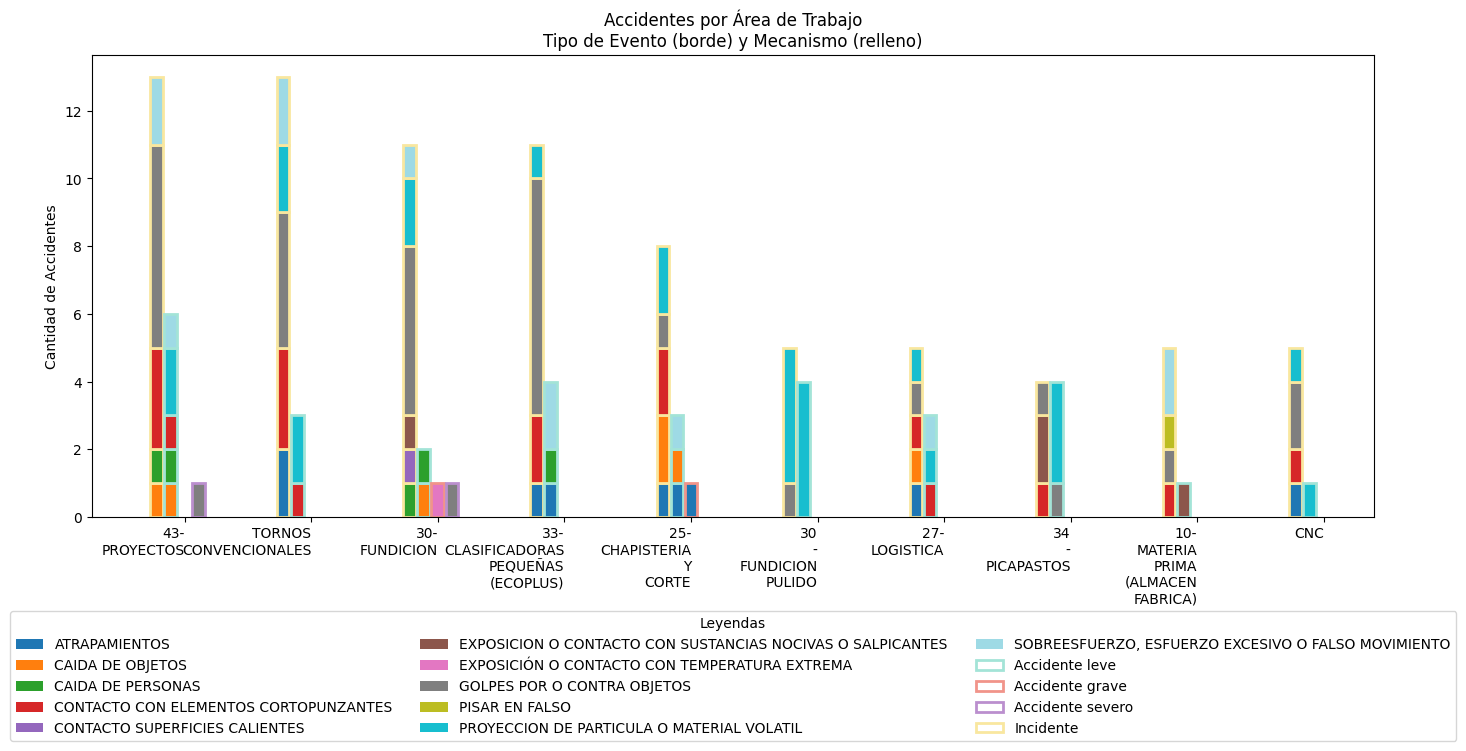

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Filtrado previo (si ya lo tienes, puedes omitir esto)
df_filtered = df[
    df['ÁREA DE TRABAJO'].notna() &
    df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df['MECANISMO DE ACCIDENTE'].notna()
]

top_areas = df_filtered['ÁREA DE TRABAJO'].value_counts().nlargest(10).index
df_top = df_filtered[df_filtered['ÁREA DE TRABAJO'].isin(top_areas)]

pivot = pd.pivot_table(
    df_top,
    index=['ÁREA DE TRABAJO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    aggfunc='size',
    fill_value=0
).reset_index()

areas = top_areas.tolist()
tipos_evento = df_top['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].unique().tolist()
mecanismos = pivot.columns[2:]

# Asignar colores
color_map = plt.cm.get_cmap('tab20', len(mecanismos))
mecanismo_colores = {mec: color_map(i) for i, mec in enumerate(mecanismos)}

evento_colores = {
    'Accidente leve': '#A3E4D7',
    'Accidente grave': '#F1948A',
    'Accidente severo': '#BB8FCE',  # <- NUEVO
    'Incidente': '#F9E79F'
}

group_width = 0.8
bar_width = group_width / len(tipos_evento)
x_ticks = []
x_labels = []
positions = []

for i, area in enumerate(areas):
    base_x = i * (1 + group_width)
    for j, tipo in enumerate(tipos_evento):
        x = base_x + j * bar_width
        positions.append((area, tipo, x))
        if tipo == tipos_evento[0]:
            x_ticks.append(base_x + group_width / 2)
            x_labels.append(area)

x_labels = [label.replace(' ', '\n') for label in x_labels]

# Gráfico
fig, ax = plt.subplots(figsize=(19, 6))

for area, tipo, x in positions:
    row = pivot[(pivot['ÁREA DE TRABAJO'] == area) & (pivot['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'] == tipo)]
    if not row.empty:
        bottom = 0
        for mecanismo in mecanismos:
            height = row.iloc[0][mecanismo]
            if height > 0:
                ax.bar(
                    x,
                    height,
                    bottom=bottom,
                    width=bar_width * 0.9,
                    color=mecanismo_colores[mecanismo],
                    edgecolor=evento_colores.get(tipo,'gray'),
                    linewidth=2
                )
                bottom += height

# Ejes y títulos
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=0, ha='right')
ax.set_ylabel("Cantidad de Accidentes")
ax.set_title("Accidentes por Área de Trabajo\nTipo de Evento (borde) y Mecanismo (relleno)")

# Leyenda de mecanismos
legend_mecanismos = [Patch(facecolor=color, label=mec) for mec, color in mecanismo_colores.items()]
legend_eventos = [Patch(facecolor='white', edgecolor=color, linewidth=2, label=evento) for evento, color in evento_colores.items()]

# Colocar leyendas
ax.legend(handles=legend_mecanismos + legend_eventos,
          title='Leyendas',
          loc='lower center',
          bbox_to_anchor=(0.5, -0.5),
          ncol=3)


plt.subplots_adjust(right=0.8)  # Deja espacio para las leyendas a la derecha
plt.show()



/tmp/ipython-input-3402365044.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', len(mecanismos))


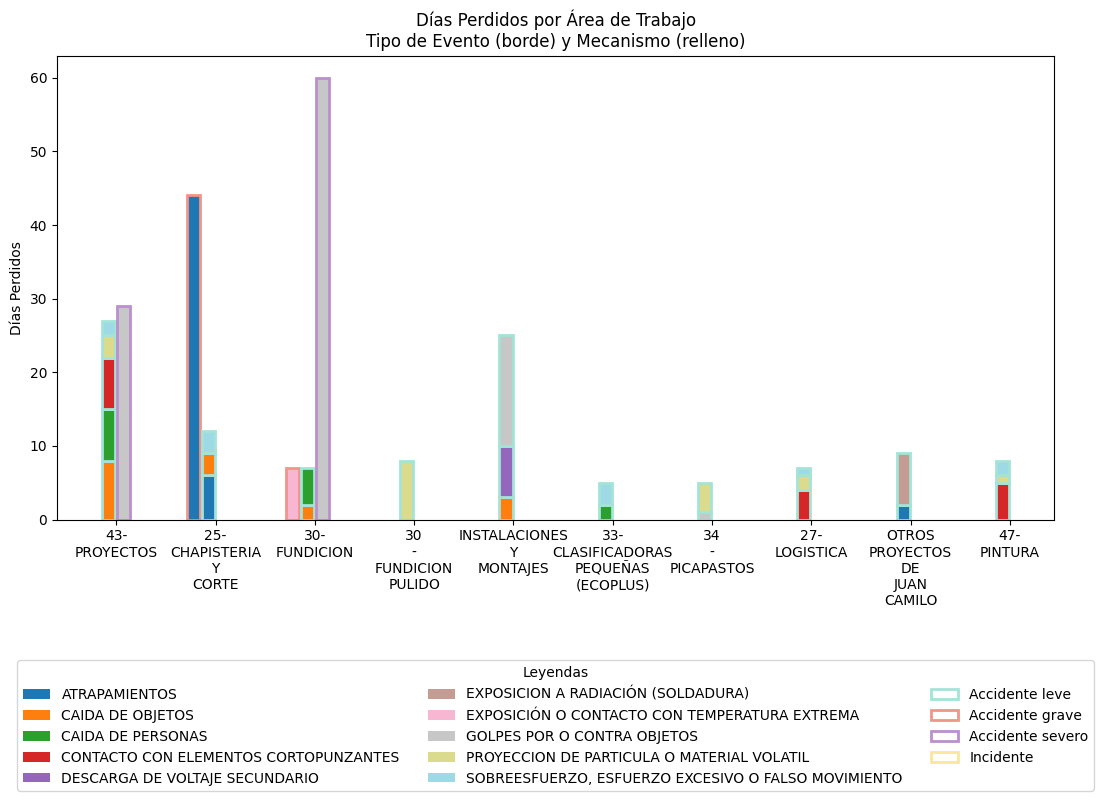

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Filtrado previo
df_filtered = df[
    df['ÁREA DE TRABAJO'].notna() &
    df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df['MECANISMO DE ACCIDENTE'].notna() &
    df['DÍAS PERDIDOS'].notna()
]

top_areas = df_filtered['ÁREA DE TRABAJO'].value_counts().nlargest(10).index
df_top = df_filtered[df_filtered['ÁREA DE TRABAJO'].isin(top_areas)]

# CAMBIO CLAVE: usar sum en lugar de size
pivot = pd.pivot_table(
    df_top,
    index=['ÁREA DE TRABAJO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    values='DÍAS PERDIDOS',
    aggfunc='sum',
    fill_value=0
).reset_index()

areas = top_areas.tolist()
tipos_evento = df_top['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].unique().tolist()
mecanismos = pivot.columns[2:]

# Asignar colores
color_map = plt.cm.get_cmap('tab20', len(mecanismos))
mecanismo_colores = {mec: color_map(i) for i, mec in enumerate(mecanismos)}

evento_colores = {
    'Accidente leve': '#A3E4D7',
    'Accidente grave': '#F1948A',
    'Accidente severo': '#BB8FCE',  # <- NUEVO
    'Incidente': '#F9E79F'
}

group_width = 0.8
bar_width = group_width / len(tipos_evento)
x_ticks = []
x_labels = []
positions = []

for i, area in enumerate(areas):
    base_x = i * (1 + group_width)
    for j, tipo in enumerate(tipos_evento):
        x = base_x + j * bar_width
        positions.append((area, tipo, x))
        if tipo == tipos_evento[0]:
            x_ticks.append(base_x + group_width / 2)
            x_labels.append(area)

x_labels = [label.replace(' ', '\n') for label in x_labels]

# Gráfico
fig, ax = plt.subplots(figsize=(19, 8))

for area, tipo, x in positions:
    row = pivot[(pivot['ÁREA DE TRABAJO'] == area) & (pivot['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'] == tipo)]
    if not row.empty:
        bottom = 0
        for mecanismo in mecanismos:
            height = row.iloc[0][mecanismo]
            if height > 0:
                ax.bar(
                    x,
                    height,
                    bottom=bottom,
                    width=bar_width * 0.9,
                    color=mecanismo_colores[mecanismo],
                    edgecolor=evento_colores.get(tipo, 'gray'),
                    linewidth=2
                )
                bottom += height

# Ejes y títulos
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=0, ha='center')
ax.set_ylabel("Días Perdidos")
ax.set_title("Días Perdidos por Área de Trabajo\nTipo de Evento (borde) y Mecanismo (relleno)")

# Leyendas
legend_mecanismos = [Patch(facecolor=color, label=mec) for mec, color in mecanismo_colores.items()]
legend_eventos = [Patch(facecolor='white', edgecolor=color, linewidth=2, label=evento) for evento, color in evento_colores.items()]

ax.legend(handles=legend_mecanismos + legend_eventos,
          title='Leyendas',
          loc='lower center',
          bbox_to_anchor=(0.5, -0.6),
          ncol=3)

plt.subplots_adjust(right=0.65, bottom=0.3)
plt.show()


/tmp/ipython-input-2574223494.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', len(mecanismos))


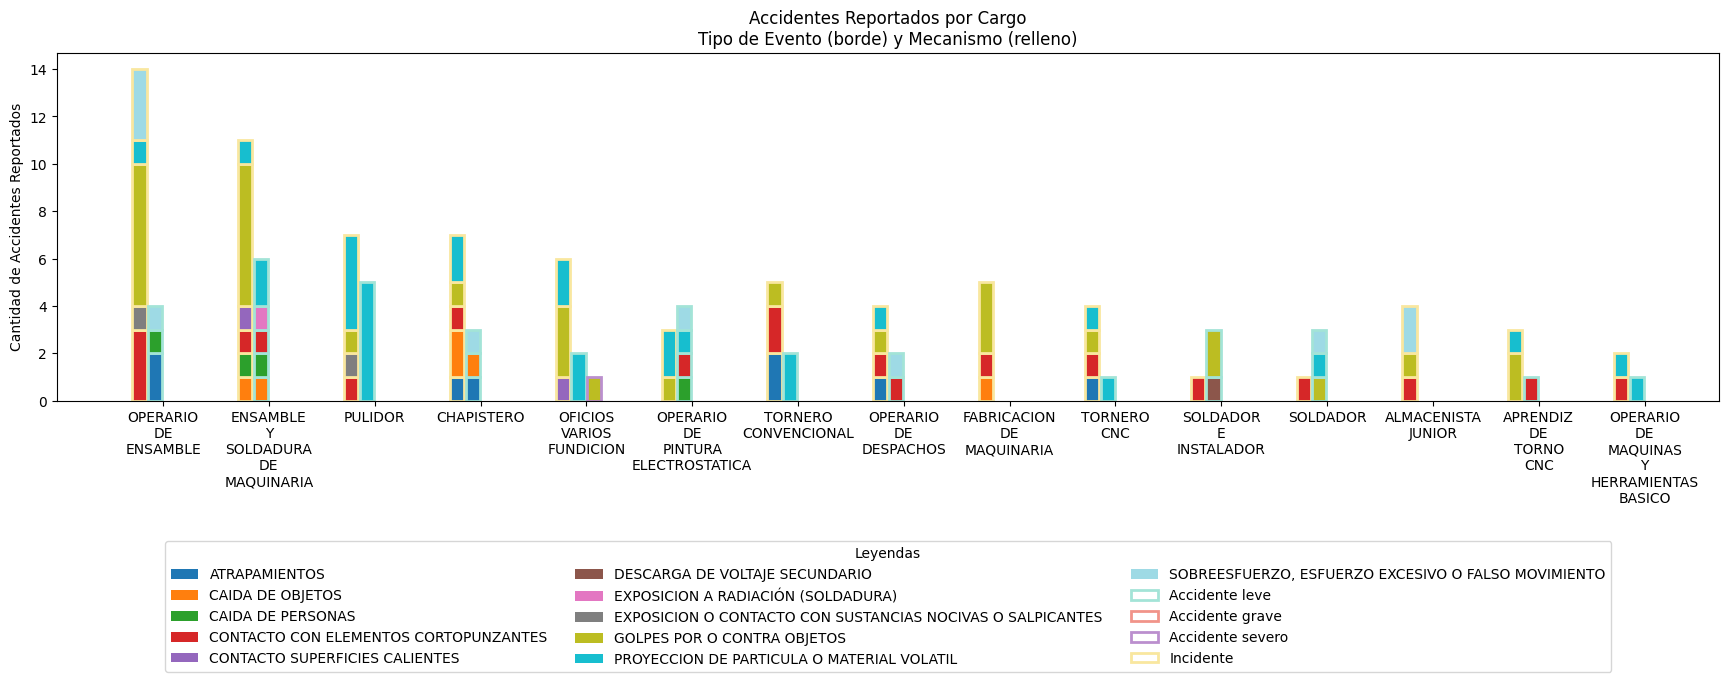

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Filtrado
df_filtered = df[
    df['CARGO'].notna() &
    df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df['MECANISMO DE ACCIDENTE'].notna()
]

# Top 5 cargos con más reportes
top_cargos = df_filtered['CARGO'].value_counts().nlargest(15).index
df_top = df_filtered[df_filtered['CARGO'].isin(top_cargos)]

# Pivot para contar accidentes por combinación
pivot = pd.pivot_table(
    df_top,
    index=['CARGO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    aggfunc='size',
    fill_value=0
).reset_index()

cargos = top_cargos.tolist()
tipos_evento = df_top['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].unique().tolist()
mecanismos = pivot.columns[2:]

# Colores
color_map = plt.cm.get_cmap('tab20', len(mecanismos))
mecanismo_colores = {mec: color_map(i) for i, mec in enumerate(mecanismos)}

evento_colores = {
    'Accidente leve': '#A3E4D7',
    'Accidente grave': '#F1948A',
    'Accidente severo': '#BB8FCE',
    'Incidente': '#F9E79F'
}

group_width = 0.8
bar_width = group_width / len(tipos_evento)
x_ticks = []
x_labels = []
positions = []

for i, cargo in enumerate(cargos):
    base_x = i * (1 + group_width)
    for j, tipo in enumerate(tipos_evento):
        x = base_x + j * bar_width
        positions.append((cargo, tipo, x))
        if tipo == tipos_evento[0]:
            x_ticks.append(base_x + group_width / 2)
            x_labels.append(cargo)

x_labels = [label.replace(' ', '\n') for label in x_labels]

# Gráfico
fig, ax = plt.subplots(figsize=(19, 6))

for cargo, tipo, x in positions:
    row = pivot[(pivot['CARGO'] == cargo) & (pivot['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'] == tipo)]
    if not row.empty:
        bottom = 0
        for mecanismo in mecanismos:
            height = row.iloc[0][mecanismo]
            if height > 0:
                ax.bar(
                    x,
                    height,
                    bottom=bottom,
                    width=bar_width * 0.9,
                    color=mecanismo_colores[mecanismo],
                    edgecolor=evento_colores.get(tipo, 'gray'),
                    linewidth=2
                )
                bottom += height

# Ejes y título
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=0, ha='center')
ax.set_ylabel("Cantidad de Accidentes Reportados")
ax.set_title("Accidentes Reportados por Cargo\nTipo de Evento (borde) y Mecanismo (relleno)")

# Leyendas
legend_mecanismos = [Patch(facecolor=color, label=mec) for mec, color in mecanismo_colores.items()]
legend_eventos = [Patch(facecolor='white', edgecolor=color, linewidth=2, label=evento) for evento, color in evento_colores.items()]

ax.legend(handles=legend_mecanismos + legend_eventos,
          title='Leyendas',
          loc='lower center',
          bbox_to_anchor=(0.5, -0.8),
          ncol=3)

plt.subplots_adjust(right=1, bottom=0.3)
plt.show()


/tmp/ipython-input-1124170902.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', len(mecanismos))


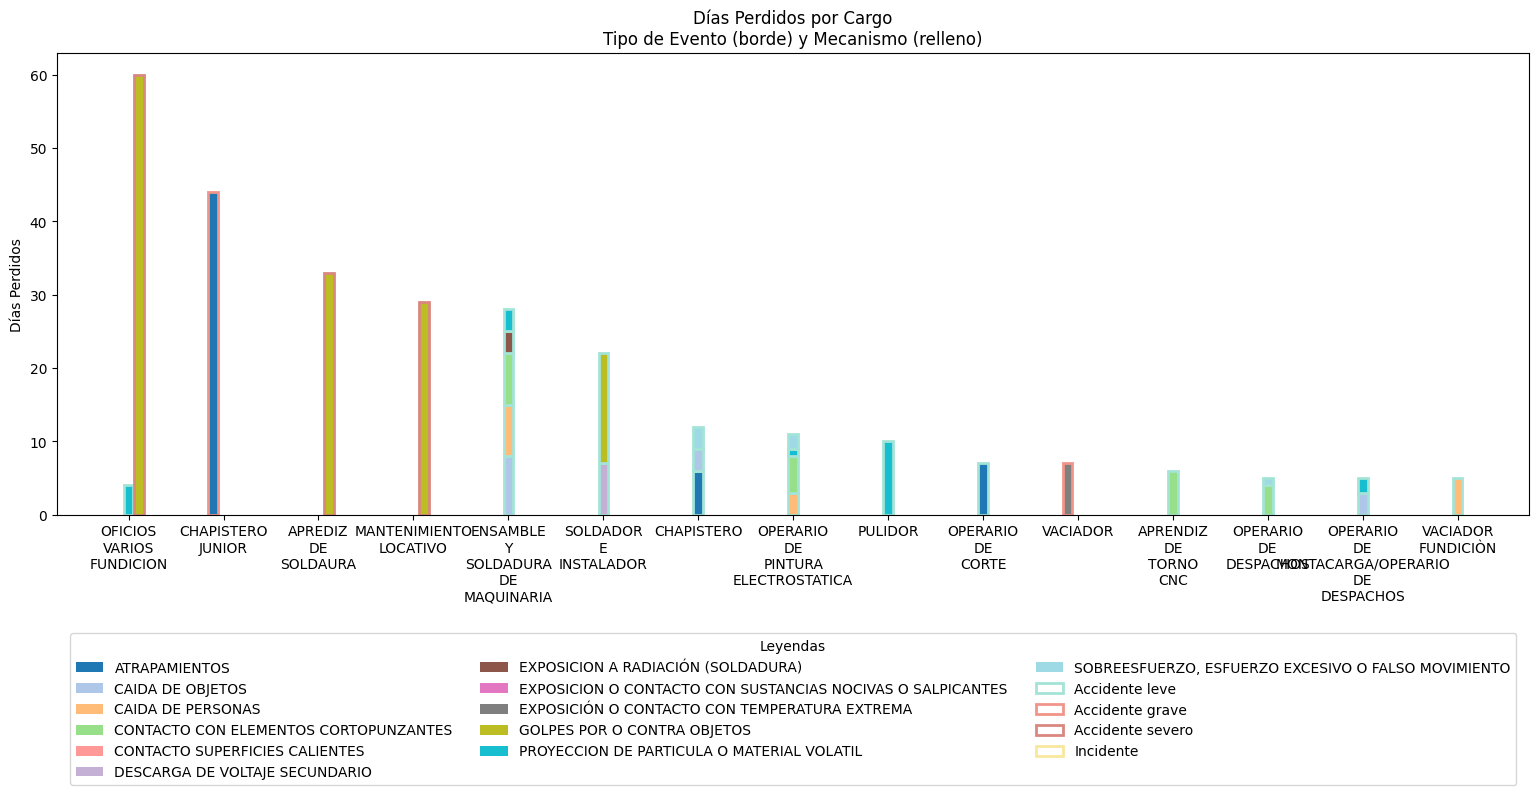

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Filtrar y preparar datos
df['DÍAS PERDIDOS'] = pd.to_numeric(df['DÍAS PERDIDOS'], errors='coerce').fillna(0)
df['CARGO'] = df['CARGO'].str.strip()
df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'] = df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].str.strip()

df_filtered = df[
    df['CARGO'].notna() &
    df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df['MECANISMO DE ACCIDENTE'].notna()
]

# Top cargos + asegurar ASM incluido
top_cargos = df_filtered.groupby('CARGO')['DÍAS PERDIDOS'].sum().nlargest(15).index.tolist()
if 'ASM' not in top_cargos and 'ASM' in df_filtered['CARGO'].unique():
    top_cargos.append('ASM')

df_top = df_filtered[df_filtered['CARGO'].isin(top_cargos)]

# Pivot para días perdidos
pivot = pd.pivot_table(
    df_top,
    index=['CARGO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    values='DÍAS PERDIDOS',
    aggfunc='sum',
    fill_value=0
).reset_index()

cargos = top_cargos
tipos_evento = df_top['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].unique().tolist()
mecanismos = pivot.columns[2:]

# Colores
color_map = plt.cm.get_cmap('tab20', len(mecanismos))
mecanismo_colores = {mec: color_map(i) for i, mec in enumerate(mecanismos)}

evento_colores = {
    'Accidente leve': '#A3E4D7',
    'Accidente grave': '#F1948A',
    'Accidente severo': '#D98880',
    'Incidente': '#F9E79F'
}

group_width = 0.8
bar_width = group_width / len(tipos_evento)
x_ticks = []
x_labels = []
positions = []

for i, cargo in enumerate(cargos):
    base_x = i * (1 + group_width)
    for j, tipo in enumerate(tipos_evento):
        x = base_x + j * bar_width
        positions.append((cargo, tipo, x))
        if tipo == tipos_evento[0]:
            x_ticks.append(base_x + group_width / 2)
            x_labels.append(cargo)

x_labels = [label.replace(' ', '\n') for label in x_labels]

# Gráfico
fig, ax = plt.subplots(figsize=(19, 6))

for cargo, tipo, x in positions:
    row = pivot[(pivot['CARGO'] == cargo) & (pivot['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'] == tipo)]
    if not row.empty:
        bottom = 0
        for mecanismo in mecanismos:
            height = row.iloc[0][mecanismo]
            if height > 0:
                ax.bar(
                    x,
                    height,
                    bottom=bottom,
                    width=bar_width * 0.9,
                    color=mecanismo_colores[mecanismo],
                    edgecolor=evento_colores.get(tipo, 'gray'),
                    linewidth=2
                )
                bottom += height

# Ejes y títulos
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=0, ha='center')
ax.set_ylabel("Días Perdidos")
ax.set_title("Días Perdidos por Cargo\nTipo de Evento (borde) y Mecanismo (relleno)")

# Leyendas
legend_mecanismos = [Patch(facecolor=color, label=mec) for mec, color in mecanismo_colores.items()]
legend_eventos = [Patch(facecolor='white', edgecolor=color, linewidth=2, label=evento) for evento, color in evento_colores.items()]

ax.legend(handles=legend_mecanismos + legend_eventos,
          title='Leyendas',
          loc='lower center',
          bbox_to_anchor=(0.5, -0.6),
          ncol=3)

plt.subplots_adjust(right=0.9)
plt.show()


/tmp/ipython-input-1793837714.py:36: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab20', len(mecanismos))


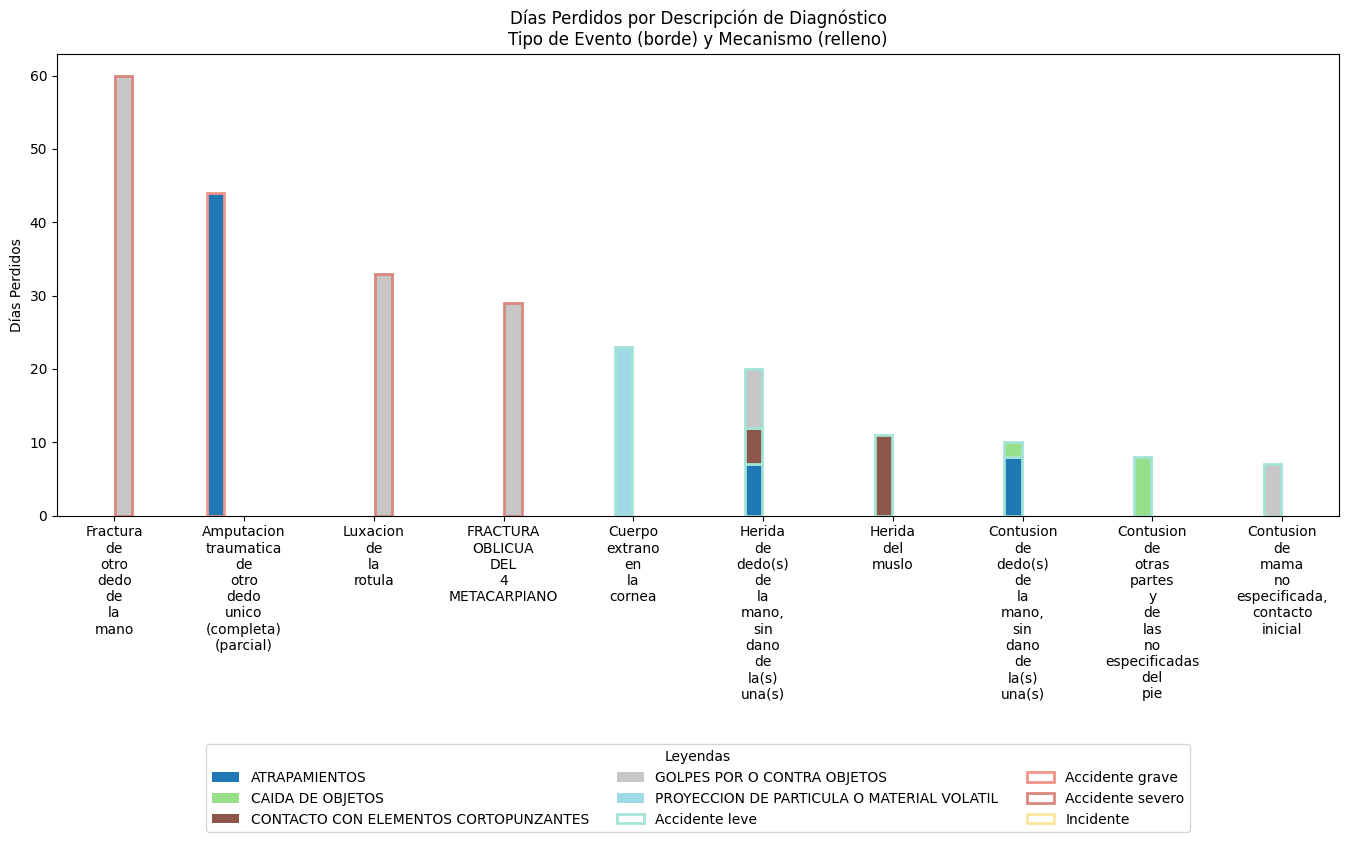

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Aseguramos datos limpios
df['DÍAS PERDIDOS'] = pd.to_numeric(df['DÍAS PERDIDOS'], errors='coerce').fillna(0)
df['DESCRIPCIÓN DE DIAGNOSTICO'] = df['DESCRIPCIÓN DE DIAGNOSTICO'].str.strip()
df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'] = df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].str.strip()

# Filtrar datos válidos
df_filtered = df[
    df['DESCRIPCIÓN DE DIAGNOSTICO'].notna() &
    df['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df['MECANISMO DE ACCIDENTE'].notna()
]

# Top 6 descripciones de diagnóstico con más días perdidos
top_desc = df_filtered.groupby('DESCRIPCIÓN DE DIAGNOSTICO')['DÍAS PERDIDOS'].sum().nlargest(10).index
df_top = df_filtered[df_filtered['DESCRIPCIÓN DE DIAGNOSTICO'].isin(top_desc)]

# Pivot para graficar
pivot = pd.pivot_table(
    df_top,
    index=['DESCRIPCIÓN DE DIAGNOSTICO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    values='DÍAS PERDIDOS',
    aggfunc='sum',
    fill_value=0
).reset_index()

descripciones = top_desc.tolist()
tipos_evento = df_top['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].unique().tolist()
mecanismos = pivot.columns[2:]

# Colores
color_map = plt.cm.get_cmap('tab20', len(mecanismos))
mecanismo_colores = {mec: color_map(i) for i, mec in enumerate(mecanismos)}
evento_colores = {
    'Accidente leve': '#A3E4D7',
    'Accidente grave': '#F1948A',
    'Accidente severo': '#D98880',
    'Incidente': '#F9E79F'
}

# Posiciones
group_width = 0.8
bar_width = group_width / len(tipos_evento)
x_ticks, x_labels, positions = [], [], []

for i, desc in enumerate(descripciones):
    base_x = i * (1 + group_width)
    for j, tipo in enumerate(tipos_evento):
        x = base_x + j * bar_width
        positions.append((desc, tipo, x))
        if tipo == tipos_evento[0]:
            x_ticks.append(base_x + group_width / 2)
            x_labels.append(desc)

x_labels = [label.replace(' ', '\n') for label in x_labels]

# Graficar
fig, ax = plt.subplots(figsize=(19, 6))

for desc, tipo, x in positions:
    row = pivot[(pivot['DESCRIPCIÓN DE DIAGNOSTICO'] == desc) & (pivot['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'] == tipo)]
    if not row.empty:
        bottom = 0
        for mecanismo in mecanismos:
            height = row.iloc[0][mecanismo]
            if height > 0:
                ax.bar(
                    x,
                    height,
                    bottom=bottom,
                    width=bar_width * 0.9,
                    color=mecanismo_colores[mecanismo],
                    edgecolor=evento_colores.get(tipo, 'gray'),
                    linewidth=2
                )
                bottom += height

# Ejes y título
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=0, ha='center')
ax.set_ylabel("Días Perdidos")
ax.set_title("Días Perdidos por Descripción de Diagnóstico\nTipo de Evento (borde) y Mecanismo (relleno)")

# Leyendas
legend_mecanismos = [Patch(facecolor=color, label=mec) for mec, color in mecanismo_colores.items()]
legend_eventos = [Patch(facecolor='white', edgecolor=color, linewidth=2, label=evento) for evento, color in evento_colores.items()]

ax.legend(handles=legend_mecanismos + legend_eventos,
          title='Leyendas',
          loc='lower center',
          bbox_to_anchor=(0.5, -0.7),
          ncol=3)

plt.subplots_adjust(right=0.8)
plt.show()


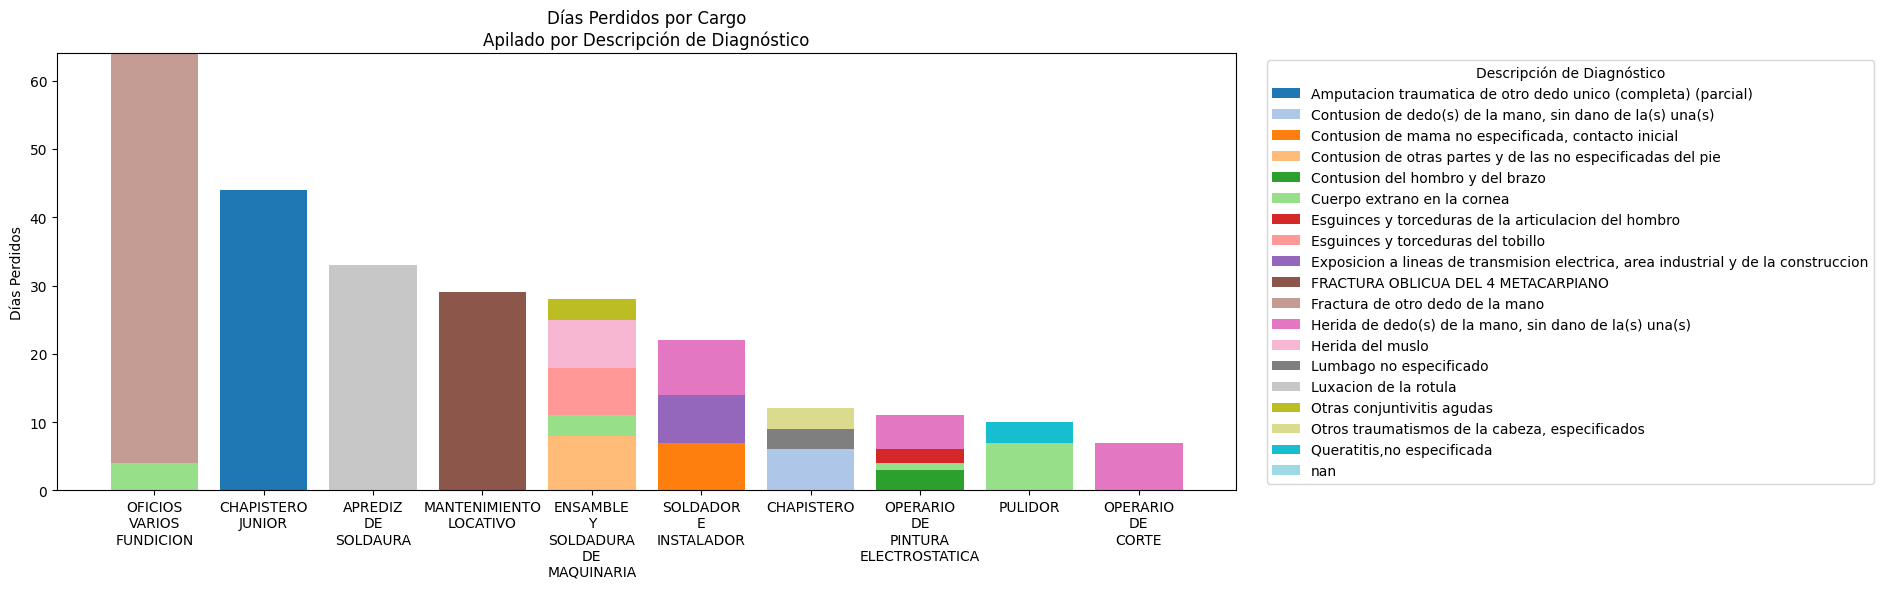

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib  # Para usar colormaps.get_cmap correctamente

# Asegurarse de que los datos estén limpios
df['DÍAS PERDIDOS'] = pd.to_numeric(df['DÍAS PERDIDOS'], errors='coerce').fillna(0)
df['CARGO'] = df['CARGO'].astype(str).str.strip()
df['DESCRIPCIÓN DE DIAGNOSTICO'] = df['DESCRIPCIÓN DE DIAGNOSTICO'].astype(str).str.strip()

# Filtrar los datos válidos
df_filtered = df[
    df['CARGO'].notna() &
    df['DESCRIPCIÓN DE DIAGNOSTICO'].notna()
]

# Top 10 cargos con más días perdidos
top_cargos = df_filtered.groupby('CARGO')['DÍAS PERDIDOS'].sum().nlargest(10).index
df_top = df_filtered[df_filtered['CARGO'].isin(top_cargos)]

# Tabla dinámica
pivot = pd.pivot_table(
    df_top,
    index='CARGO',
    columns='DESCRIPCIÓN DE DIAGNOSTICO',
    values='DÍAS PERDIDOS',
    aggfunc='sum',
    fill_value=0
)

# Reordenar por los cargos principales
pivot = pivot.loc[top_cargos]

# Colores para cada diagnóstico (actualizado)
colormap = matplotlib.colormaps.get_cmap('tab20').resampled(len(pivot.columns))
desc_diag_colores = {desc: colormap(i) for i, desc in enumerate(pivot.columns)}

# Crear gráfico
fig, ax = plt.subplots(figsize=(19, 6))
bottom = [0] * len(pivot)

for desc_diag in pivot.columns:
    valores = pivot[desc_diag].values
    ax.bar(
        pivot.index,
        valores,
        bottom=bottom,
        label=desc_diag,
        color=desc_diag_colores[desc_diag]
    )
    bottom = [sum(x) for x in zip(bottom, valores)]

# Ejes y estilos (corregido)
ax.set_ylabel("Días Perdidos")
ax.set_title("Días Perdidos por Cargo\nApilado por Descripción de Diagnóstico")
ax.set_xticks(range(len(pivot.index)))
ax.set_xticklabels([c.replace(" ", "\n") for c in pivot.index], rotation=0, ha='center')

# Leyenda
ax.legend(title="Descripción de Diagnóstico", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


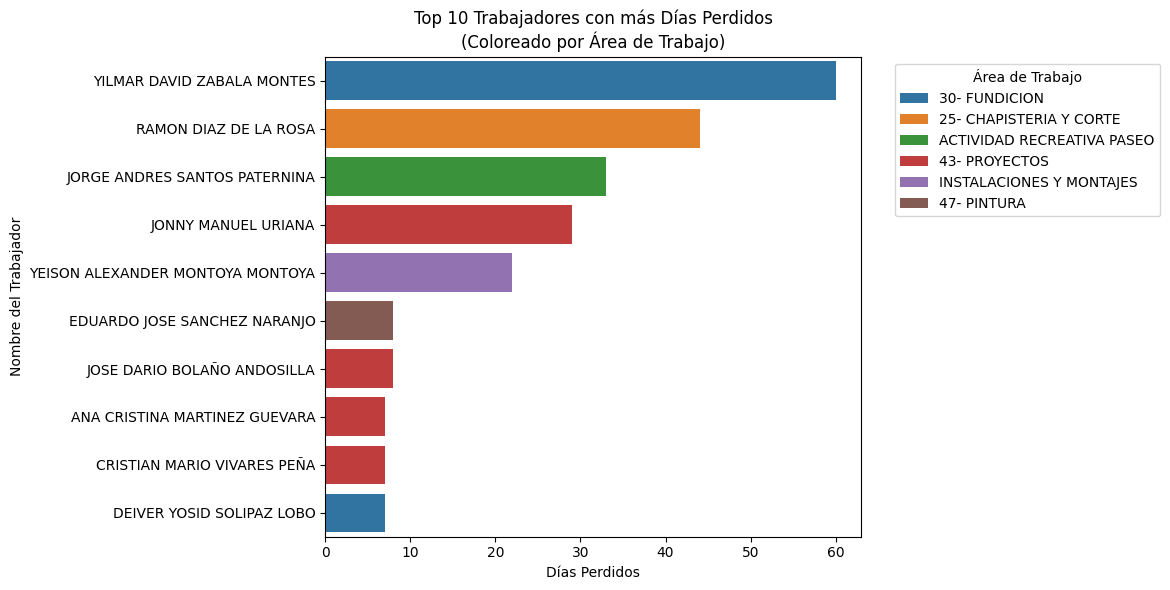

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurar que los datos sean correctos
df['DÍAS PERDIDOS'] = pd.to_numeric(df['DÍAS PERDIDOS'], errors='coerce').fillna(0)
df['NOMBRES'] = df['NOMBRES'].astype(str).str.strip()
df['ÁREA DE TRABAJO'] = df['ÁREA DE TRABAJO'].astype(str).str.strip()

# Agrupación por nombre y área de trabajo
dias_perdidos_top = df.groupby(['NOMBRES', 'ÁREA DE TRABAJO'])['DÍAS PERDIDOS'].sum().nlargest(10).reset_index()

# Gráfico
plt.figure(figsize=(12, 6))
sns.barplot(
    data=dias_perdidos_top,
    x='DÍAS PERDIDOS',
    y='NOMBRES',
    hue='ÁREA DE TRABAJO',
    dodge=False,
    palette='tab10'
)

plt.title("Top 10 Trabajadores con más Días Perdidos\n(Coloreado por Área de Trabajo)")
plt.xlabel("Días Perdidos")
plt.ylabel("Nombre del Trabajador")
plt.legend(title="Área de Trabajo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


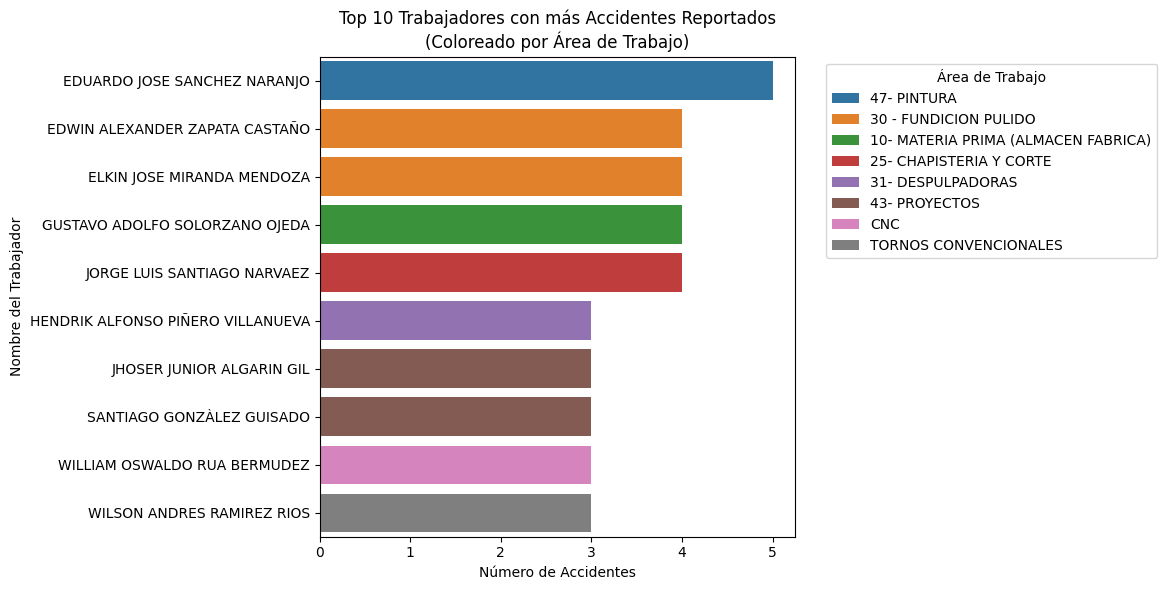

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Quitar filas con valores nulos reales o texto 'nan'
df_limpio = df[
    df['NOMBRES'].notna() &
    df['ÁREA DE TRABAJO'].notna() &
    (df['NOMBRES'].astype(str).str.lower() != 'nan') &
    (df['ÁREA DE TRABAJO'].astype(str).str.lower() != 'nan')
]

# Agrupar número de accidentes por trabajador y área
accidentes_top = (
    df_limpio
    .groupby(['NOMBRES', 'ÁREA DE TRABAJO'])
    .size()
    .reset_index(name='Nº ACCIDENTES')
)

# Obtener top 10 trabajadores con más accidentes
accidentes_top = accidentes_top.nlargest(10, 'Nº ACCIDENTES')

# Crear gráfico
plt.figure(figsize=(12, 6))
sns.barplot(
    data=accidentes_top,
    x='Nº ACCIDENTES',
    y='NOMBRES',
    hue='ÁREA DE TRABAJO',
    dodge=False,
    palette='tab10'
)

plt.title("Top 10 Trabajadores con más Accidentes Reportados\n(Coloreado por Área de Trabajo)")
plt.xlabel("Número de Accidentes")
plt.ylabel("Nombre del Trabajador")
plt.legend(title="Área de Trabajo", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


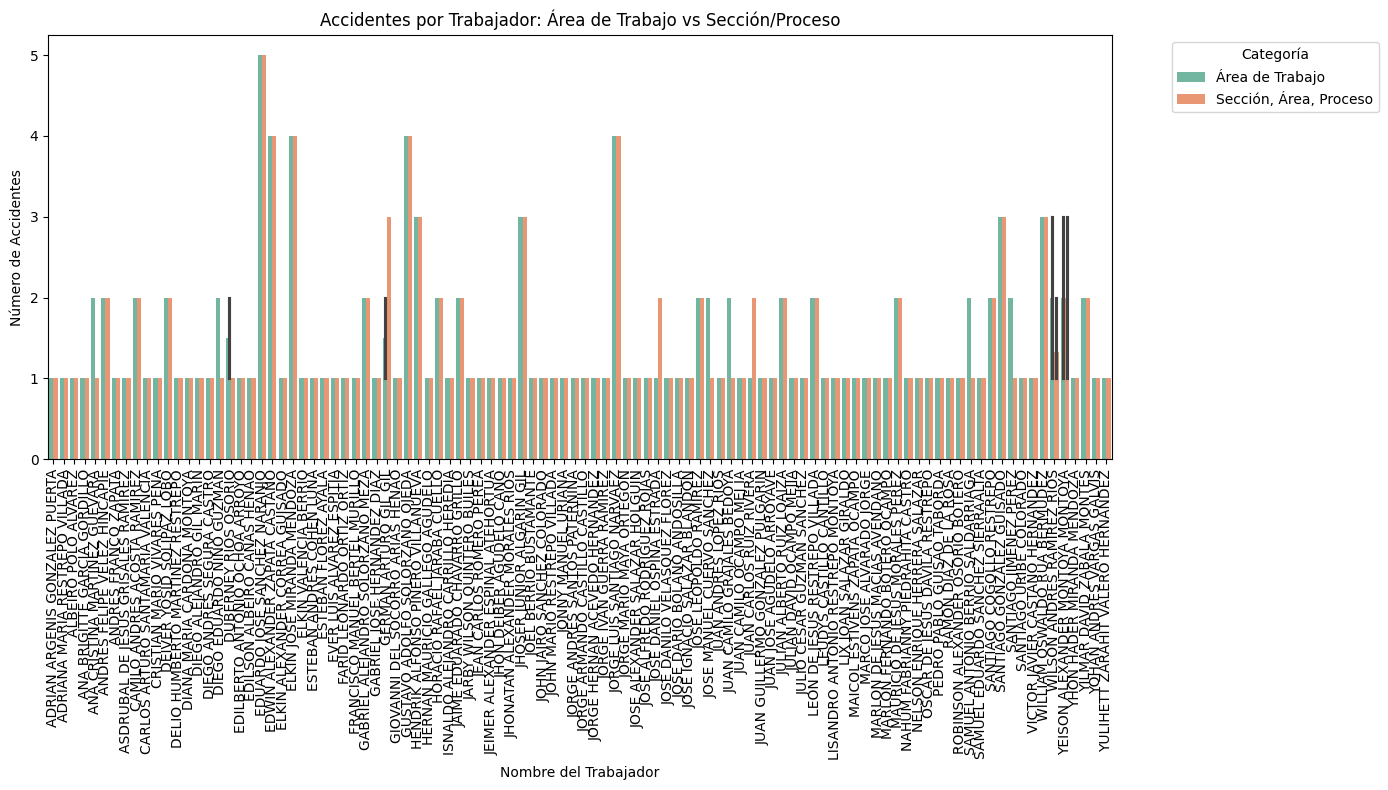

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 1: Eliminar valores nulos en las columnas relevantes
df_limpio = df.dropna(subset=['NOMBRES', 'ÁREA DE TRABAJO', 'SECCIÓN, ÁREA, PROCESO DONDE SE ACCIDENTE'])

# Paso 2: Agrupar los accidentes por trabajador y las dos categorías
accidentes_por_area = (
    df_limpio.groupby(['NOMBRES', 'ÁREA DE TRABAJO'])
    .size()
    .reset_index(name='Nº ACCIDENTES')
)

accidentes_por_seccion = (
    df_limpio.groupby(['NOMBRES', 'SECCIÓN, ÁREA, PROCESO DONDE SE ACCIDENTE'])
    .size()
    .reset_index(name='Nº ACCIDENTES')
)

# Paso 3: Añadir columna para diferenciar las categorías
accidentes_por_area['Categoría'] = 'Área de Trabajo'
accidentes_por_seccion['Categoría'] = 'Sección, Área, Proceso'

# Paso 4: Combinar ambos DataFrames en uno solo
accidentes_comb = pd.concat([accidentes_por_area, accidentes_por_seccion])

# Paso 5: Crear gráfico de barras
plt.figure(figsize=(14, 8))
sns.barplot(
    data=accidentes_comb,
    x='NOMBRES',
    y='Nº ACCIDENTES',
    hue='Categoría',
    dodge=True,
    palette='Set2'
)

plt.title("Accidentes por Trabajador: Área de Trabajo vs Sección/Proceso")
plt.xlabel("Nombre del Trabajador")
plt.ylabel("Número de Accidentes")
plt.xticks(rotation=90)  # Para mejorar la legibilidad de los nombres
plt.legend(title="Categoría", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Registros de accidentes que superan el 70% del rango intercuartílico:
                                NOMBRES  \
8              LIX JOAN SALAZAR GIRALDO   
20       LEON DE JESUS RESTREPO VILLADA   
21             JHON DEIBER AGUDELO CANO   
22                JOSE LEOPOLDO RAMIREZ   
26       EDWIN ALEXANDER ZAPATA CASTAÑO   
29       EDWIN ALEXANDER ZAPATA CASTAÑO   
34           ELKIN JOSE MIRANDA MENDOZA   
43       JAIME EDUARADO CHAVARRO GRILLO   
48            DEIVER YOSID SOLIPAZ LOBO   
49      JORGE ARMANDO CASTILLO CASTILLO   
52    HENDRIK ALFONSO PIÑERO VILLANUEVA   
53            ESTEBAN ANDRES COHEN LUNA   
58       JORGE HERNAN ACEVEDO HERNANDEZ   
59           YOHAN ANDRES VARGAS GALVIS   
64         ANA BRIGITTE GARCIA GORDILLO   
66              JUAN CARLOS RUIZ RIVERA   
67             LEUDYS CASTILLO CANTILLO   
68         ANDRES FELIPE VELEZ HINCAPIE   
69               JUAN ANDRES LOPEZ RIOS   
72                 DUBERNEY RIOS OSORIO   
79    SAMUEL ANTONIO BERRIO

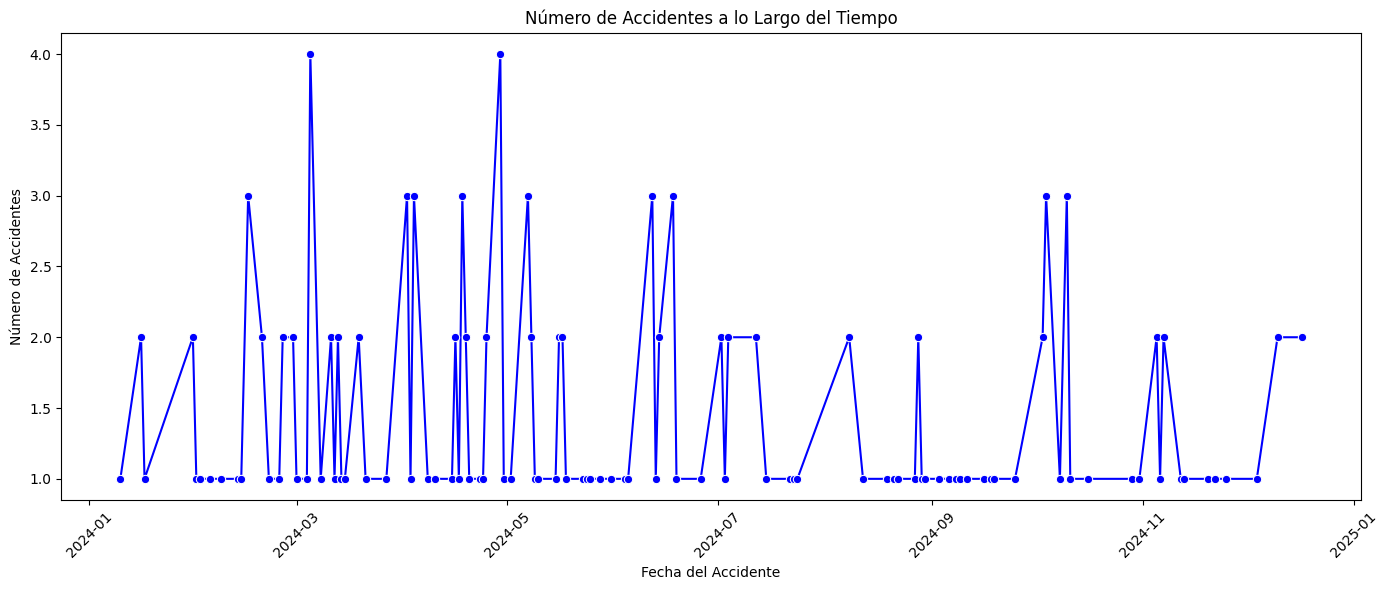

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paso 1: Asegurarse de que la columna de fecha esté en formato datetime
df['FECHA DEL ACCIDENTE / INCIDENTE'] = pd.to_datetime(df['FECHA DEL ACCIDENTE / INCIDENTE'], errors='coerce')

# Paso 2: Eliminar filas con fechas nulas
df_limpio = df.dropna(subset=['FECHA DEL ACCIDENTE / INCIDENTE'])

# Paso 3: Agrupar por fecha y contar el número de accidentes
accidentes_por_fecha = (
    df_limpio.groupby('FECHA DEL ACCIDENTE / INCIDENTE')
    .size()
    .reset_index(name='Número de Accidentes')
)

# Paso 4: Calcular los cuartiles y el rango intercuartílico (IQR)
Q1 = accidentes_por_fecha['Número de Accidentes'].quantile(0.25)
Q3 = accidentes_por_fecha['Número de Accidentes'].quantile(0.75)
IQR = Q3 - Q1

# Paso 5: Calcular el límite superior del 70% sobre el IQR
limite_superior_70 = Q3 + 0.70 * IQR

# Paso 6: Filtrar las fechas que superan el límite superior
fechas_superan_70_IQR = accidentes_por_fecha[accidentes_por_fecha['Número de Accidentes'] > limite_superior_70]['FECHA DEL ACCIDENTE / INCIDENTE']

# Paso 7: Filtrar los registros que ocurren en esas fechas
accidentes_detalle = df_limpio[df_limpio['FECHA DEL ACCIDENTE / INCIDENTE'].isin(fechas_superan_70_IQR)]

# Paso 8: Seleccionar columnas relevantes (nombres y mecanismo de accidente)
accidentes_detalle = accidentes_detalle[['NOMBRES', 'MECANISMO DE ACCIDENTE', 'FECHA DEL ACCIDENTE / INCIDENTE']]

# Paso 9: Mostrar la tabla con los registros que superan el 70% del rango intercuartílico
print("Registros de accidentes que superan el 70% del rango intercuartílico:")
print(accidentes_detalle)

# Paso 10: Crear gráfico de línea
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=accidentes_por_fecha,
    x='FECHA DEL ACCIDENTE / INCIDENTE',
    y='Número de Accidentes',
    marker='o',  # Opcional: para marcar cada punto con un círculo
    color='blue'
)

plt.title("Número de Accidentes a lo Largo del Tiempo")
plt.xlabel("Fecha del Accidente")
plt.ylabel("Número de Accidentes")
plt.xticks(rotation=45)  # Mejorar la legibilidad de las fechas
plt.tight_layout()
plt.show()


# Task
Present a comprehensive analysis of the safety indicators, summarizing the key findings from all the generated charts and tables, and provide actionable conclusions and recommendations for improving workplace safety.

## Analizar Distribución de Eventos y Gravedad

### Subtask:
Interpretar el gráfico circular que muestra la distribución porcentual de los tipos de evento y gravedad (Accidente leve, grave, severo, Incidente), sin incluir 'Enfermedad general'.


**Reasoning**:
To accurately interpret the pie chart generated in cell `Ck59Gc3vGU9r`, which depicts the distribution of event types and severity, I need to recreate the exact data used for that specific plot. This involves reloading the original dataset and applying only the filtering and cleaning steps present in `Ck59Gc3vGU9r` to ensure consistency with the generated chart.



In [ ]:
import pandas as pd

# Re-loading the original file to ensure we have the df state as it was for the Ck59Gc3vGU9r plot.
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_original_state_for_plot = pd.read_excel(file_name, header=1)

# Apply column cleaning as done in Ck59Gc3vGU9r
df_original_state_for_plot.columns = df_original_state_for_plot.columns.str.replace('\n', ' ', regex=True).str.strip()

# Apply the specific filter from Ck59Gc3vGU9r to exclude 'Enfermedad general'
df_original_state_for_plot = df_original_state_for_plot[df_original_state_for_plot['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].str.strip().str.lower() != 'enfermedad general']

# Count occurrences by type of event and gravity
eventos_gravedad_counts_for_plot = df_original_state_for_plot['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].value_counts()

# Calculate percentages
total_for_plot = eventos_gravedad_counts_for_plot.sum()

# Prepare labels with percentages for interpretation
labels_con_porcentaje_for_plot = [
    f"{label}: {count / total_for_plot:.1%}"
    for label, count in zip(eventos_gravedad_counts_for_plot.index, eventos_gravedad_counts_for_plot.values)
]

# Identify the type of event with the highest and lowest percentage
highest_event = eventos_gravedad_counts_for_plot.index[0]
highest_percentage = eventos_gravedad_counts_for_plot.values[0] / total_for_plot * 100

lowest_event = eventos_gravedad_counts_for_plot.index[-1]
lowest_percentage = eventos_gravedad_counts_for_plot.values[-1] / total_for_plot * 100

print("Datos para la interpretación del gráfico circular 'Distribución Porcentual de Tipo de Evento y Gravedad (sin Enfermedad general)':")
for label_percent in labels_con_porcentaje_for_plot:
    print(label_percent)
print(f"\nEl tipo de evento con el porcentaje más alto es: {highest_event} ({highest_percentage:.1f}%) ")
print(f"El tipo de evento con el porcentaje más bajo es: {lowest_event} ({lowest_percentage:.1f}%) ")

Datos para la interpretación del gráfico circular 'Distribución Porcentual de Tipo de Evento y Gravedad (sin Enfermedad general)':
Incidente: 76.6%
Accidente leve: 19.2%
Accidente severo: 3.3%
Accidente grave: 0.9%

El tipo de evento con el porcentaje más alto es: Incidente (76.6%) 
El tipo de evento con el porcentaje más bajo es: Accidente grave (0.9%) 


### Análisis de la Distribución de Eventos y Gravedad

El gráfico circular muestra la distribución porcentual de los tipos de evento y gravedad, excluyendo la 'Enfermedad general'. A partir de los datos, se observa lo siguiente:

*   **Incidente**: Representa el **76.6%** de los eventos reportados, siendo el tipo de evento con el porcentaje más alto.
*   **Accidente leve**: Constituye el **19.2%** de los eventos.
*   **Accidente severo**: Abarca el **3.3%** de los eventos.
*   **Accidente grave**: Es el tipo de evento con el porcentaje más bajo, representando solo el **0.9%**.

En resumen, la gran mayoría de los eventos son Incidentes, seguidos por Accidentes leves, mientras que los Accidentes severos y graves son significativamente menos frecuentes.

## Analizar Distribución de Diagnósticos

### Subtask:
Revisar el gráfico circular que detalla la distribución porcentual de los diagnósticos de accidentes, y comprender los diagnósticos más frecuentes.


**Reasoning**:
To accurately interpret the pie chart showing the distribution of accident diagnoses, I need to recreate the exact data used for that specific plot, as generated in cell `VkSjDZf6QR5d`. This involves reloading the original dataset and applying the cleaning and filtering steps present in that cell to ensure consistency.



In [ ]:
import pandas as pd

# Reloading the original file to ensure we have the df state as it was for the VkSjDZf6QR5d plot.
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_for_diagnosis_plot = pd.read_excel(file_name, header=1)

# Apply column cleaning as done in VkSjDZf6QR5d
df_for_diagnosis_plot.columns = df_for_diagnosis_plot.columns.str.replace('\n', ' ', regex=True).str.strip()

# Apply the specific filter from VkSjDZf6QR5d to exclude 'Enfermedad general'
df_for_diagnosis_plot = df_for_diagnosis_plot[df_for_diagnosis_plot['DESCRIPCIÓN DE DIAGNOSTICO'].str.strip().str.lower() != 'enfermedad general']

# Count occurrences by diagnosis
diagnosis_counts = df_for_diagnosis_plot['DESCRIPCIÓN DE DIAGNOSTICO'].value_counts()

# Calculate percentages
total_diagnosis = diagnosis_counts.sum()
diagnosis_percentages = (diagnosis_counts / total_diagnosis) * 100

# Prepare labels with percentages for interpretation
labels_con_porcentaje_diagnosis = [
    f"{label}: {percentage:.1f}%"
    for label, percentage in diagnosis_percentages.items()
]

# Identify the diagnosis with the highest and lowest percentage
highest_diagnosis_label = diagnosis_percentages.index[0]
highest_diagnosis_percentage = diagnosis_percentages.iloc[0]

lowest_diagnosis_label = diagnosis_percentages.index[-1]
lowest_diagnosis_percentage = diagnosis_percentages.iloc[-1]

print("Datos para la interpretación del gráfico circular 'Distribución Porcentual de Diagnóstico de Accidentes':")
for label_percent in labels_con_porcentaje_diagnosis:
    print(label_percent)
print(f"\nEl diagnóstico con el porcentaje más alto es: {highest_diagnosis_label} ({highest_diagnosis_percentage:.1f}%) ")
print(f"El diagnóstico con el porcentaje más bajo es: {lowest_diagnosis_label} ({lowest_diagnosis_percentage:.1f}%) ")

Datos para la interpretación del gráfico circular 'Distribución Porcentual de Diagnóstico de Accidentes':
Lumbago no especificado: 12.0%
Fractura de otro dedo de la mano: 10.0%
Cuerpo extrano en la cornea: 10.0%
Herida de dedo(s) de la mano, sin dano de la(s) una(s): 6.0%
Contusion de otras partes y de las no especificadas del pie: 6.0%
Esguinces y torceduras de dedo(s) de la mano: 6.0%
Esguinces y torceduras de la articulacion del hombro: 4.0%
Contusion de otras partes de la muneca y de la mano: 4.0%
Contusion de dedo(s) de la mano, sin dano de la(s) una(s): 4.0%
Quemadura del tobillo y del pie, de segundo grado: 4.0%
Traumatismo superficial del antebrazo, no especificado: 2.0%
Heridas de otras partes del cuello: 2.0%
Dolor en la columna dorsal: 2.0%
Contusion de dedo(s) del pie sin dano de la(s) una(s): 2.0%
Herida de la mejilla y de la region temporomandibular: 2.0%
Esguinces y torceduras del tobillo: 2.0%
Cuerpo extrano residual en tejido blando: 2.0%
Herida de otras partes del ant

### Análisis de la Distribución de Diagnósticos

El gráfico circular sobre la distribución porcentual de diagnósticos de accidentes (excluyendo 'Enfermedad general') revela los siguientes hallazgos clave:

*   **Lumbago no especificado** es el diagnóstico más frecuente, representando el **12.0%** del total de accidentes.
*   Le siguen de cerca **Fractura de otro dedo de la mano** y **Cuerpo extraño en la córnea**, ambos con un **10.0%**.
*   Otros diagnósticos significativos incluyen **Herida de dedo(s) de la mano, sin daño de la(s) uña(s)**, **Contusión de otras partes y de las no especificadas del pie** y **Esguinces y torceduras de dedo(s) de la mano**, cada uno con un **6.0%**.
*   Los diagnósticos con la menor frecuencia (2.0%) son variados e incluyen Traumatismos superficiales, heridas en el cuello, dolor dorsal, contusiones en dedos del pie, heridas en la mejilla, esguinces de tobillo, cuerpo extraño residual en tejido blando, heridas en el antebrazo, fracturas múltiples de dedos de la mano, fractura de otros huesos metacarpianos, quemadura de primer grado, úlcera de la córnea, contusión del muslo, celulitis, fractura de los dientes, fractura de hueso del metatarso y herida del labio y de la cavidad bucal.

En resumen, los **problemas musculoesqueléticos (lumbago, esguinces, fracturas de dedos)** y las **lesiones oculares (cuerpo extraño en la córnea)** son los diagnósticos más prevalentes en los accidentes reportados.

## Analizar Mecanismos de Accidente

### Subtask:
Examinar el gráfico circular que presenta la distribución porcentual de los mecanismos de accidente para identificar los más comunes.


**Reasoning**:
To interpret the pie chart of accident mechanisms, I will first calculate the percentages for each mechanism from the `mecanismo_counts` Series, then identify the mechanisms with the highest and lowest percentages and present them to the user.



In [ ]:
import pandas as pd

# 'mecanismo_counts' is already available in the kernel state.

# Calculate total sum for percentages
total_mecanismos = mecanismo_counts.sum()

# Calculate percentages for all mechanisms
mecanismo_percentages = (mecanismo_counts / total_mecanismos) * 100

# Get the mechanism with the highest percentage
highest_mecanismo_label = mecanismo_percentages.index[0]
highest_mecanismo_percentage = mecanismo_percentages.iloc[0]

# Get the mechanism with the lowest percentage
lowest_mecanismo_label = mecanismo_percentages.index[-1]
lowest_mecanismo_percentage = mecanismo_percentages.iloc[-1]

print("Datos para la interpretación del gráfico circular 'Distribución Porcentual de Mecanismo de Accidente':")
for label, percentage in mecanismo_percentages.items():
    print(f"{label}: {percentage:.1f}%")
print(f"\nEl mecanismo de accidente con el porcentaje más alto es: {highest_mecanismo_label} ({highest_mecanismo_percentage:.1f}%) ")
print(f"El mecanismo de accidente con el porcentaje más bajo es: {lowest_mecanismo_label} ({lowest_mecanismo_percentage:.1f}%) ")

Datos para la interpretación del gráfico circular 'Distribución Porcentual de Mecanismo de Accidente':
GOLPES POR O CONTRA OBJETOS: 24.3%
PROYECCION DE PARTICULA O MATERIAL VOLATIL: 22.0%
CONTACTO CON ELEMENTOS CORTOPUNZANTES: 18.7%
SOBREESFUERZO, ESFUERZO EXCESIVO O FALSO MOVIMIENTO: 15.4%
CAIDA DE OBJETOS: 4.7%
CAIDA DE PERSONAS: 3.7%
CONTACTO SUPERFICIES CALIENTES: 3.3%
ATRAPAMIENTOS: 2.8%
CONTACTO CON SUPERFICIES ABRASIVAS: 1.9%
PISAR EN FALSO: 1.4%
EXPOSICIÓN O CONTACTO CON TEMPERATURA EXTREMA: 0.9%
MORDEDURA O PICADURA DE ANIMAL: 0.5%
EXPOSICION A RADIACIÓN (SOLDADURA): 0.5%

El mecanismo de accidente con el porcentaje más alto es: GOLPES POR O CONTRA OBJETOS (24.3%) 
El mecanismo de accidente con el porcentaje más bajo es: EXPOSICION A RADIACIÓN (SOLDADURA) (0.5%) 


### Análisis de Mecanismos de Accidente

El gráfico circular sobre la distribución porcentual de los mecanismos de accidente revela los siguientes puntos clave:

*   **Los tres mecanismos de accidente más frecuentes son:**
    *   **Golpes por o contra objetos:** Representa el **24.3%** del total, siendo el mecanismo más común.
    *   **Proyección de partícula o material volátil:** Constituye el **22.0%** de los accidentes.
    *   **Contacto con elementos cortopunzantes:** Abarca el **18.7%**.

*   Estos tres mecanismos combinados suman más del 65% de todos los accidentes reportados, lo que indica que son las principales causas de incidentes y accidentes en el entorno laboral.

*   **Otros mecanismos significativos incluyen:**
    *   **Sobreesfuerzo, esfuerzo excesivo o falso movimiento:** Con un **15.4%**.

*   **Los mecanismos menos frecuentes, con porcentajes por debajo del 1%, son:**
    *   **Exposición o contacto con temperatura extrema (0.9%)**
    *   **Mordedura o picadura de animal (0.5%)**
    *   **Exposición a radiación (soldadura) (0.5%)**

En resumen, la prevención de accidentes debería enfocarse prioritariamente en reducir los **golpes, proyecciones de partículas y el contacto con objetos cortopunzantes**, ya que son los que mayor impacto tienen en la siniestralidad.

## Analizar Tipos de Lesión y Partes del Cuerpo Afectadas

### Subtask:
Interpretar los gráficos circulares sobre los tipos de lesión y las partes del cuerpo más afectadas para entender la naturaleza de las lesiones.


**Reasoning**:
To interpret the pie charts, I need to calculate the percentages for each type of injury and affected body part from the existing Series `tipos_lesion_counts` and `parte_afectada_counts`, then identify the highest and lowest percentages for each.



In [ ]:
import pandas as pd

# --- Análisis de Tipos de Lesión ---
# `tipos_lesion_counts` está disponible en el estado del kernel.

# Calcular el total para los porcentajes de tipos de lesión
total_tipos_lesion = tipos_lesion_counts.sum()

# Calcular porcentajes para todos los tipos de lesión
tipos_lesion_percentages = (tipos_lesion_counts / total_tipos_lesion) * 100

# Obtener el tipo de lesión con el porcentaje más alto
highest_lesion_label = tipos_lesion_percentages.index[0]
highest_lesion_percentage = tipos_lesion_percentages.iloc[0]

# Obtener el tipo de lesión con el porcentaje más bajo
# Se asegura que se tome el último elemento después de ordenar, o se puede buscar el mínimo explícitamente
lowest_lesion_label = tipos_lesion_percentages.index[-1]
lowest_lesion_percentage = tipos_lesion_percentages.iloc[-1]

print("\n--- Distribución Porcentual de Tipo de Lesión ---")
for label, percentage in tipos_lesion_percentages.items():
    print(f"{label}: {percentage:.1f}%")
print(f"\nEl tipo de lesión con el porcentaje más alto es: {highest_lesion_label} ({highest_lesion_percentage:.1f}%) ")
print(f"El tipo de lesión con el porcentaje más bajo es: {lowest_lesion_label} ({lowest_lesion_percentage:.1f}%) ")

# --- Análisis de Parte del Cuerpo Afectada ---
# `parte_afectada_counts` está disponible en el estado del kernel.

# Calcular el total para los porcentajes de partes del cuerpo afectadas
total_parte_afectada = parte_afectada_counts.sum()

# Calcular porcentajes para todas las partes del cuerpo afectadas
parte_afectada_percentages = (parte_afectada_counts / total_parte_afectada) * 100

# Obtener la parte del cuerpo con el porcentaje más alto
highest_parte_label = parte_afectada_percentages.index[0]
highest_parte_percentage = parte_afectada_percentages.iloc[0]

# Obtener la parte del cuerpo con el porcentaje más bajo
lowest_parte_label = parte_afectada_percentages.index[-1]
lowest_parte_percentage = parte_afectada_percentages.iloc[-1]

print("\n--- Distribución Porcentual de Parte del Cuerpo Afectada ---")
for label, percentage in parte_afectada_percentages.items():
    print(f"{label}: {percentage:.1f}%")
print(f"\nLa parte del cuerpo afectada con el porcentaje más alto es: {highest_parte_label} ({highest_parte_percentage:.1f}%) ")
print(f"La parte del cuerpo afectada con el porcentaje más bajo es: {lowest_parte_label} ({lowest_parte_percentage:.1f}%) ")


--- Distribución Porcentual de Tipo de Lesión ---
HERIDA ABIERTA (CORTOPUNZANTE, LACERANTE, AVULSIVA, ABRASIVA): 27.6%
CONTUSIÓN: 23.4%
LESION EN OJO POR CUERPO EXTRAÑO: 20.6%
ESGUINCE, DESGARRO MUSCULAR, LACERACIÓN DE MÚSCULO O TENDÓN SIN HERIDA, DOLOR LUMBAR O DORSAL: 15.4%
QUEMADURA: 6.1%
FRACTURA, APLASTAMIENTO (CON COMPROMISO OSEO): 4.2%
ESGUINCE, DESGARRO MUSCULAR, LACERACIÓN DE MÚSCULO O TENDÓN SIN HERIDA: 1.9%
DOLOR AGUDO: 0.9%

El tipo de lesión con el porcentaje más alto es: HERIDA ABIERTA (CORTOPUNZANTE, LACERANTE, AVULSIVA, ABRASIVA) (27.6%) 
El tipo de lesión con el porcentaje más bajo es: DOLOR AGUDO (0.9%) 

--- Distribución Porcentual de Parte del Cuerpo Afectada ---
DEDO: 26.6%
OJO: 20.6%
MANOS: 11.7%
TRONCO (Incluye espalda, columna vertebral, médula espinal, pélvis): 10.7%
PIES: 7.0%
BRAZO ANTEBRAZO: 6.1%
ANTEBRAZO: 4.2%
PIERNA: 2.8%
HOMBRO: 2.8%
CARA: 1.9%
CABEZA: 1.9%
ABDOMEN: 0.9%
CUELLO: 0.9%
RODILLA: 0.5%
LESIONES GENERALES U OTRAS: 0.5%
MUSLO: 0.5%
DIENTES: 0.

### Análisis de Tipos de Lesión y Partes del Cuerpo Afectadas

El análisis de los gráficos circulares sobre los tipos de lesión y las partes del cuerpo más afectadas revela información crucial para la prevención de accidentes:

**Tipos de Lesión más Frecuentes:**
*   **Herida Abierta (Cortopunzante, Lacerante, Avulsiva, Abrasiva)**: Constituye el **27.6%** de todas las lesiones, siendo el tipo más común.
*   **Contusión**: Representa el **23.4%** de las lesiones.
*   **Lesión en Ojo por Cuerpo Extraño**: Abarca el **20.6%**.
*   **Esguince, Desgarro Muscular, Laceración de Músculo o Tendón sin Herida, Dolor Lumbar o Dorsal**: Un significativo **15.4%**.

El tipo de lesión menos frecuente es el **Dolor Agudo**, con solo el **0.9%**.

**Partes del Cuerpo más Afectadas:**
*   **Dedo**: Es la parte del cuerpo más afectada, con el **26.6%** de los casos.
*   **Ojo**: Le sigue de cerca con el **20.6%** de las lesiones.
*   **Manos**: Representa el **11.7%**.
*   **Tronco** (incluyendo espalda, columna vertebral, médula espinal, pelvis): Con el **10.7%**.

Las partes del cuerpo menos afectadas son **Rodilla, Lesiones Generales u Otras, Muslo** y **Dientes**, todas con el **0.5%**.

**Hallazgos Clave y Conclusiones:**
1.  **Enfoque en Extremidades y Ojos:** Los **dedos, manos y ojos** son las partes del cuerpo más vulnerables a lesiones. Esto sugiere que la protección personal (guantes, gafas de seguridad) y los procedimientos de trabajo seguro para tareas manuales son críticos.
2.  **Prevención de Cortes y Golpes:** Las **heridas abiertas** y las **contusiones** son los tipos de lesión predominantes, lo cual se alinea con los mecanismos de accidente más comunes (golpes por/contra objetos y contacto con elementos cortopunzantes). Las medidas preventivas deben centrarse en la manipulación segura de herramientas y materiales, y el aseguramiento de objetos.
3.  **Riesgos Oculares:** La alta incidencia de **lesiones en el ojo por cuerpo extraño** subraya la necesidad de un uso consistente y adecuado de protección ocular.
4.  **Ergonomía y Cargas:** Los **esguinces y dolores lumbares/dorsales** indican la importancia de la ergonomía, técnicas de levantamiento adecuadas y pausas activas para reducir la fatiga y el sobreesfuerzo.

**Recomendaciones para la Prevención:**
*   **Reforzar el uso de EPP:** Especialmente guantes protectores y gafas de seguridad en todas las áreas de riesgo.
*   **Capacitación específica:** Implementar programas de formación sobre manejo seguro de herramientas, prevención de cortes y golpes, y técnicas ergonómicas.
*   **Identificación y Control de Riesgos:** Realizar inspecciones periódicas para identificar fuentes de proyección de partículas, objetos que puedan caer y puntos de contacto con elementos cortopunzantes. Implementar controles de ingeniería o administrativos para mitigar estos riesgos.
*   **Promoción de la cultura de seguridad:** Fomentar una cultura donde los empleados reporten incidentes y casi-accidentes para identificar y corregir peligros antes de que resulten en lesiones graves.

## Analizar Relación entre Área y Mecanismo

### Subtask:
Analizar el gráfico de barras apiladas que muestra la relación entre el área de trabajo y el mecanismo de accidente, buscando patrones específicos por área.


**Reasoning**:
To interpret the stacked bar chart, I need to analyze the `tabla_cruzada` DataFrame which summarizes the relationship between 'ÁREA DE TRABAJO' and 'MECANISMO DE ACCIDENTE'. This DataFrame was generated in cell `ncQ64-lRgFAk` and contains the data represented in the plot. I will extract the top areas by total accidents and the predominant mechanisms within those areas.



In [ ]:
import pandas as pd

# Ensure df is in the state it was for cell ncQ64-lRgFAk
# Reloading the original file to ensure we have the df state as it was for the ncQ64-lRgFAk plot.
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_for_crosstab = pd.read_excel(file_name, header=1)

# Apply column cleaning as done in ncQ64-lRgFAk
df_for_crosstab.columns = df_for_crosstab.columns.str.replace('\n', ' ', regex=True).str.strip()

# Filter valid data as done in ncQ64-lRgFAk
df_filtered_for_crosstab = df_for_crosstab[df_for_crosstab['ÁREA DE TRABAJO'].notna() & df_for_crosstab['MECANISMO DE ACCIDENTE'].notna()]

# Recreate tabla_cruzada
tabla_cruzada_analysis = pd.crosstab(df_filtered_for_crosstab['ÁREA DE TRABAJO'].str.strip(),
                             df_filtered_for_crosstab['MECANISMO DE ACCIDENTE'].str.strip())

# Identify areas with the highest total number of accidents
total_accidents_by_area = tabla_cruzada_analysis.sum(axis=1).sort_values(ascending=False)

print("Total de Accidentes por Área de Trabajo:\n")
print(total_accidents_by_area.head(5))

print("\nAnálisis de los mecanismos de accidente más frecuentes por área (Top 3 áreas):\n")

for area in total_accidents_by_area.head(3).index:
    print(f"Área: {area}")
    area_mechanisms = tabla_cruzada_analysis.loc[area].sort_values(ascending=False)
    print(area_mechanisms.head(3))
    print("\n")

# Find areas where a specific mechanism stands out significantly
# For example, identify areas where one mechanism accounts for a high percentage of accidents in that area

relative_contribution = tabla_cruzada_analysis.div(tabla_cruzada_analysis.sum(axis=1), axis=0)

print("Áreas donde un mecanismo destaca significativamente (más del 50% de los accidentes del área):\n")
for area in relative_contribution.index:
    dominant_mechanisms = relative_contribution.loc[area][relative_contribution.loc[area] > 0.5]
    if not dominant_mechanisms.empty:
        for mechanism, percentage in dominant_mechanisms.items():
            print(f"Área: {area} - Mecanismo: {mechanism} ({percentage:.1%})")


Total de Accidentes por Área de Trabajo:

ÁREA DE TRABAJO
30- FUNDICION                            49
33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)    22
25- CHAPISTERIA Y CORTE                  19
43- PROYECTOS                            17
35- TRAPICHES                            15
dtype: int64

Análisis de los mecanismos de accidente más frecuentes por área (Top 3 áreas):

Área: 30- FUNDICION
MECANISMO DE ACCIDENTE
GOLPES POR O CONTRA OBJETOS                   17
PROYECCION DE PARTICULA O MATERIAL VOLATIL    13
CAIDA DE OBJETOS                               5
Name: 30- FUNDICION, dtype: int64


Área: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)
MECANISMO DE ACCIDENTE
SOBREESFUERZO, ESFUERZO EXCESIVO O FALSO MOVIMIENTO    6
GOLPES POR O CONTRA OBJETOS                            5
PROYECCION DE PARTICULA O MATERIAL VOLATIL             3
Name: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS), dtype: int64


Área: 25- CHAPISTERIA Y CORTE
MECANISMO DE ACCIDENTE
CONTACTO CON ELEMENTOS CORTOPUNZANTES    9
GOLPES P

### Análisis de la Relación entre Área de Trabajo y Mecanismo de Accidente

El análisis del gráfico de barras apiladas (y los datos subyacentes) que relaciona el área de trabajo con el mecanismo de accidente revela los siguientes patrones clave:

**1. Áreas con mayor incidencia de accidentes:**
*   **30- FUNDICION**: Es el área con la mayor cantidad de accidentes (49 en total).
*   **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: Le sigue con 22 accidentes.
*   **25- CHAPISTERIA Y CORTE**: Registra 19 accidentes.

**2. Mecanismos de accidente predominantes en las áreas de alta incidencia:**
*   **30- FUNDICION:** Los principales mecanismos son **Golpes por o contra objetos (17)** y **Proyección de partícula o material volátil (13)**.
*   **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS):** Destacan **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (6)** y **Golpes por o contra objetos (5)**.
*   **25- CHAPISTERIA Y CORTE:** El mecanismo dominante es **Contacto con elementos cortopunzantes (9)**, seguido de **Golpes por o contra objetos (6)**.

**3. Áreas con mecanismos de accidente significativamente dominantes (más del 50% de los accidentes del área):**
*   **28- MECANIZADO (CNC):** El **Sobreesfuerzo, esfuerzo excesivo o falso movimiento** representa el 100% de sus accidentes.
*   **37- CALDERERIA:** El **Contacto con superficies calientes** es el 100% de los accidentes en esta área.
*   **41- MANTENIMIENTO DE EDIFICIO:** Similarmente, el **Sobreesfuerzo, esfuerzo excesivo o falso movimiento** es el 100%.
*   **44- TRILLA Y TOSTION:** La **Proyección de partícula o material volátil** es el 100% de los accidentes.
*   **49- COCHES SOLARES:** También **Proyección de partícula o material volátil** es el 100%.
*   **99- ADMINISTRACION E INGENIERIA:** El **Contacto con elementos cortopunzantes** es el 100%.

**Conclusiones y Patrones Observados:**
*   **Especificidad de Riesgos:** Cada área de trabajo presenta riesgos predominantes específicos. Por ejemplo, la fundición se ve afectada por golpes y proyecciones, mientras que chapistería y corte tienen un alto riesgo de contacto con elementos cortopunzantes.
*   **Riesgos Concentrados:** Varias áreas más pequeñas o especializadas muestran una concentración extrema en un solo mecanismo de accidente, lo que simplifica el enfoque de las medidas preventivas para estas áreas.
*   **Necesidad de Programas de Prevención Adaptados:** La diversidad de mecanismos predominantes entre áreas subraya la importancia de diseñar e implementar programas de seguridad y capacitaciones que estén específicamente adaptados a los riesgos únicos de cada sección o proceso, en lugar de un enfoque generalizado.

## Analizar Accidentes por Área y Tipo de Evento

### Subtask:
Interpretar el gráfico de barras agrupadas que compara la cantidad de accidentes por área de trabajo y tipo de evento, resaltando las áreas con mayores incidencias.


**Reasoning**:
To accurately interpret the grouped bar chart showing accidents by work area and event type, I need to recreate the exact data used for that specific plot, as generated in cell `gm0hn8V6hHYA`. This involves reloading the original dataset and applying the cleaning and filtering steps present in that cell to ensure consistency with the generated plot.



In [ ]:
import pandas as pd

# 1. Reload the original Excel file into a DataFrame named `df_for_event_analysis`
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_for_event_analysis = pd.read_excel(file_name, header=1)

# 2. Clean the column names
df_for_event_analysis.columns = df_for_event_analysis.columns.str.replace('\n', ' ', regex=True).str.strip()

# 3. Filter `df_for_event_analysis` to include only rows where 'ÁREA DE TRABAJO' and 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)' are not null.
df_filtered_event_analysis = df_for_event_analysis[
    df_for_event_analysis['ÁREA DE TRABAJO'].notna() &
    df_for_event_analysis['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna()
]

# 4. Create a cross-tabulation (crosstab) for 'ÁREA DE TRABAJO' and 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'
tabla_eventos_analysis = pd.crosstab(
    df_filtered_event_analysis['ÁREA DE TRABAJO'].str.strip(),
    df_filtered_event_analysis['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].str.strip()
)

# 5. Identify the top 10 areas with the highest total number of accidents
top_10_areas = tabla_eventos_analysis.sum(axis=1).nlargest(10).index
tabla_eventos_analysis = tabla_eventos_analysis.loc[top_10_areas]

# 6. Calculate the total number of accidents for each of these top areas.
total_accidents_top_areas = tabla_eventos_analysis.sum(axis=1)

print("Total de Accidentes por Área de Trabajo (Top 10):")
print(total_accidents_top_areas)

print("\nAnálisis de los Tipos de Evento más frecuentes por Área (Top 3 Áreas):")
# 7. For the top 3 areas, identify the predominant 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'.
for area in top_10_areas[:3]:
    print(f"\nÁrea: {area}")
    # Get the event types for the current area, sort them, and take the top one
    predominant_event = tabla_eventos_analysis.loc[area].nlargest(1)
    print(predominant_event)


Total de Accidentes por Área de Trabajo (Top 10):
ÁREA DE TRABAJO
30- FUNDICION                              49
33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)      22
25- CHAPISTERIA Y CORTE                    19
43- PROYECTOS                              17
35- TRAPICHES                              15
27- LOGISTICA                              13
31- DESPULPADORAS                          12
37- CALDERERIA                             10
28- MECANIZADO ( TORNOS CONVENCIONALES)     9
32- SECADORAS HASTA 60@                     8
dtype: int64

Análisis de los Tipos de Evento más frecuentes por Área (Top 3 Áreas):

Área: 30- FUNDICION
TIPO DE EVENTO Y GRAVEDAD (AT / IT)
Incidente    36
Name: 30- FUNDICION, dtype: int64

Área: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)
TIPO DE EVENTO Y GRAVEDAD (AT / IT)
Incidente    17
Name: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS), dtype: int64

Área: 25- CHAPISTERIA Y CORTE
TIPO DE EVENTO Y GRAVEDAD (AT / IT)
Incidente    14
Name: 25- CHAPISTERIA Y CORTE, dtype: int64


### Análisis de Accidentes por Área de Trabajo y Tipo de Evento

El gráfico de barras agrupadas y el análisis de los datos subyacentes que compara la cantidad de accidentes por área de trabajo y tipo de evento revelan los siguientes puntos clave:

**1. Áreas con la Mayor Incidencia de Accidentes:**
Las 10 áreas con el mayor número total de accidentes son:
*   **30- FUNDICION**: 49 accidentes
*   **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: 22 accidentes
*   **25- CHAPISTERIA Y CORTE**: 19 accidentes
*   **43- PROYECTOS**: 17 accidentes
*   **35- TRAPICHES**: 15 accidentes
*   **27- LOGISTICA**: 13 accidentes
*   **31- DESPULPADORAS**: 12 accidentes
*   **37- CALDERERIA**: 10 accidentes
*   **28- MECANIZADO ( TORNOS CONVENCIONALES)**: 9 accidentes
*   **32- SECADORAS HASTA 60@**: 8 accidentes

**2. Tipo de Evento Predominante en las Áreas con Mayor Incidencia:**
Para las tres áreas con mayor número de accidentes, el tipo de evento predominante es consistentemente el **Incidente**:
*   **30- FUNDICION**: El evento más frecuente es "Incidente" (36 registros).
*   **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: El evento más frecuente es "Incidente" (17 registros).
*   **25- CHAPISTERIA Y CORTE**: El evento más frecuente es "Incidente" (14 registros).

**Conclusiones y Patrones Observados:**
*   **Concentración de Incidentes:** Existe una clara concentración de "Incidentes" en las áreas con mayor número de eventos reportados. Esto sugiere que, aunque los accidentes graves son menos frecuentes, las condiciones o prácticas que conducen a incidentes son comunes en estas áreas. La alta cantidad de incidentes es una señal de alerta temprana que puede predecir accidentes más graves si no se abordan las causas raíz.
*   **Identificación de Áreas Críticas:** La "30- FUNDICION" destaca como el área con la mayor carga de eventos, lo que la convierte en un punto focal prioritario para intervenciones de seguridad. Las "33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)" y "25- CHAPISTERIA Y CORTE" también requieren atención significativa.
*   **Necesidad de Investigación de Incidentes:** Dado que los incidentes son la mayoría de los eventos, una investigación exhaustiva de sus causas, incluso si no resultan en lesiones graves o días perdidos, es fundamental para prevenir futuros accidentes de mayor gravedad.

**Recomendaciones:**
*   **Priorizar la Fundición:** Desarrollar e implementar programas de seguridad específicos y reforzados para el área de Fundición, enfocándose en la reducción de incidentes.
*   **Análisis de Causas Raíz:** Realizar análisis de causas raíz para los incidentes más comunes en las áreas identificadas, para entender por qué ocurren y qué controles pueden implementarse.
*   **Fomentar el Reporte de Incidentes:** Mantener y fomentar una cultura de reporte de incidentes para capturar la mayor cantidad de información posible y utilizarla para la mejora continua de la seguridad.
*   **Capacitación Dirigida:** Ofrecer capacitación específica sobre riesgos y medidas preventivas para los trabajadores de las áreas de alta incidencia, basándose en los tipos de eventos más comunes.

### Análisis de Accidentes por Área de Trabajo y Tipo de Evento

El gráfico de barras agrupadas y el análisis de los datos subyacentes que compara la cantidad de accidentes por área de trabajo y tipo de evento revelan los siguientes puntos clave:

**1. Áreas con la Mayor Incidencia de Accidentes:**
Las 10 áreas con el mayor número total de accidentes son:
*   **30- FUNDICION**: 49 accidentes
*   **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: 22 accidentes
*   **25- CHAPISTERIA Y CORTE**: 19 accidentes
*   **43- PROYECTOS**: 17 accidentes
*   **35- TRAPICHES**: 15 accidentes
*   **27- LOGISTICA**: 13 accidentes
*   **31- DESPULPADORAS**: 12 accidentes
*   **37- CALDERERIA**: 10 accidentes
*   **28- MECANIZADO ( TORNOS CONVENCIONALES)**: 9 accidentes
*   **32- SECADORAS HASTA 60@**: 8 accidentes

**2. Tipo de Evento Predominante en las Áreas con Mayor Incidencia:**
Para las tres áreas con mayor número de accidentes, el tipo de evento predominante es consistentemente el **Incidente**:
*   **30- FUNDICION**: El evento más frecuente es "Incidente" (36 registros).
*   **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: El evento más frecuente es "Incidente" (17 registros).
*   **25- CHAPISTERIA Y CORTE**: El evento más frecuente es "Incidente" (14 registros).

**Conclusiones y Patrones Observados:**
*   **Concentración de Incidentes:** Existe una clara concentración de "Incidentes" en las áreas con mayor número de eventos reportados. Esto sugiere que, aunque los accidentes graves son menos frecuentes, las condiciones o prácticas que conducen a incidentes son comunes en estas áreas. La alta cantidad de incidentes es una señal de alerta temprana que puede predecir accidentes más graves si no se abordan las causas raíz.
*   **Identificación de Áreas Críticas:** La "30- FUNDICION" destaca como el área con la mayor carga de eventos, lo que la convierte en un punto focal prioritario para intervenciones de seguridad. Las "33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)" y "25- CHAPISTERIA Y CORTE" también requieren atención significativa.
*   **Necesidad de Investigación de Incidentes:** Dado que los incidentes son la mayoría de los eventos, una investigación exhaustiva de sus causas, incluso si no resultan en lesiones graves o días perdidos, es fundamental para prevenir futuros accidentes de mayor gravedad.

**Recomendaciones:**
*   **Priorizar la Fundición:** Desarrollar e implementar programas de seguridad específicos y reforzados para el área de Fundición, enfocándose en la reducción de incidentes.
*   **Análisis de Causas Raíz:** Realizar análisis de causas raíz para los incidentes más comunes en las áreas identificadas, para entender por qué ocurren y qué controles pueden implementarse.
*   **Fomentar el Reporte de Incidentes:** Mantener y fomentar una cultura de reporte de incidentes para capturar la mayor cantidad de información posible y utilizarla para la mejora continua de la seguridad.
*   **Capacitación Dirigida:** Ofrecer capacitación específica sobre riesgos y medidas preventivas para los trabajadores de las áreas de alta incidencia, basándose en los tipos de eventos más comunes.

### Análisis de Accidentes por Área de Trabajo y Tipo de Evento

El gráfico de barras agrupadas y el análisis de los datos subyacentes que compara la cantidad de accidentes por área de trabajo y tipo de evento revelan los siguientes puntos clave:

**1. Áreas con la Mayor Incidencia de Accidentes:**
Las 10 áreas con el mayor número total de accidentes son:
*   **30- FUNDICION**: 49 accidentes
*   **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: 22 accidentes
*   **25- CHAPISTERIA Y CORTE**: 19 accidentes
*   **43- PROYECTOS**: 17 accidentes
*   **35- TRAPICHES**: 15 accidentes
*   **27- LOGISTICA**: 13 accidentes
*   **31- DESPULPADORAS**: 12 accidentes
*   **37- CALDERERIA**: 10 accidentes
*   **28- MECANIZADO ( TORNOS CONVENCIONALES)**: 9 accidentes
*   **32- SECADORAS HASTA 60@**: 8 accidentes

**2. Tipo de Evento Predominante en las Áreas con Mayor Incidencia:**
Para las tres áreas con mayor número de accidentes, el tipo de evento predominante es consistentemente el **Incidente**:
*   **30- FUNDICION**: El evento más frecuente es "Incidente" (36 registros).
*   **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: El evento más frecuente es "Incidente" (17 registros).
*   **25- CHAPISTERIA Y CORTE**: El evento más frecuente es "Incidente" (14 registros).

**Conclusiones y Patrones Observados:**
*   **Concentración de Incidentes:** Existe una clara concentración de "Incidentes" en las áreas con mayor número de eventos reportados. Esto sugiere que, aunque los accidentes graves son menos frecuentes, las condiciones o prácticas que conducen a incidentes son comunes en estas áreas. La alta cantidad de incidentes es una señal de alerta temprana que puede predecir accidentes más graves si no se abordan las causas raíz.
*   **Identificación de Áreas Críticas:** La "30- FUNDICION" destaca como el área con la mayor carga de eventos, lo que la convierte en un punto focal prioritario para intervenciones de seguridad. Las "33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)" y "25- CHAPISTERIA Y CORTE" también requieren atención significativa.
*   **Necesidad de Investigación de Incidentes:** Dado que los incidentes son la mayoría de los eventos, una investigación exhaustiva de sus causas, incluso si no resultan en lesiones graves o días perdidos, es fundamental para prevenir futuros accidentes de mayor gravedad.

**Recomendaciones:**
*   **Priorizar la Fundición:** Desarrollar e implementar programas de seguridad específicos y reforzados para el área de Fundición, enfocándose en la reducción de incidentes.
*   **Análisis de Causas Raíz:** Realizar análisis de causas raíz para los incidentes más comunes en las áreas identificadas, para entender por qué ocurren y qué controles pueden implementarse.
*   **Fomentar el Reporte de Incidentes:** Mantener y fomentar una cultura de reporte de incidentes para capturar la mayor cantidad de información posible y utilizarla para la mejora continua de la seguridad.
*   **Capacitación Dirigida:** Ofrecer capacitación específica sobre riesgos y medidas preventivas para los trabajadores de las áreas de alta incidencia, basándose en los tipos de eventos más comunes.

## Analizar Accidentes Detallados por Área

### Subtask:
Examinar el gráfico de barras apiladas detallado que muestra los accidentes por área, tipo de evento (borde) y mecanismo (relleno), para identificar combinaciones críticas.


**Reasoning**:
To interpret the detailed stacked bar chart, I need to recreate the `pivot` DataFrame and `df_filtered` from cell `YgyJfBMqhdSO` to ensure I'm working with the exact same data that was plotted. This involves applying the same filtering and pivoting logic.



In [ ]:
import pandas as pd

# Re-loading the original file to ensure we have the df state as it was for cell YgyJfBMqhdSO.
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_for_detailed_analysis = pd.read_excel(file_name, header=1)

# Apply column cleaning as done in previous cells
df_for_detailed_analysis.columns = df_for_detailed_analysis.columns.str.replace('\n', ' ', regex=True).str.strip()

# Apply filtering as done in cell YgyJfBMqhdSO
df_filtered = df_for_detailed_analysis[
    df_for_detailed_analysis['ÁREA DE TRABAJO'].notna() &
    df_for_detailed_analysis['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df_for_detailed_analysis['MECANISMO DE ACCIDENTE'].notna()
]

# Get top areas as done in cell YgyJfBMqhdSO
top_areas = df_filtered['ÁREA DE TRABAJO'].value_counts().nlargest(10).index
df_top = df_filtered[df_filtered['ÁREA DE TRABAJO'].isin(top_areas)]

# Recreate the pivot table as in cell YgyJfBMqhdSO
pivot_analysis = pd.pivot_table(
    df_top,
    index=['ÁREA DE TRABAJO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    aggfunc='size',
    fill_value=0
).reset_index()

# 1. Calculate total accidents per area (summing across all mechanisms and event types)
pivot_analysis['Total Accidents'] = pivot_analysis.iloc[:, 2:].sum(axis=1)

# Group by 'ÁREA DE TRABAJO' to get total accidents per area
total_accidents_by_area = pivot_analysis.groupby('ÁREA DE TRABAJO')['Total Accidents'].sum().nlargest(5)

print("Top 5 Áreas de Trabajo con más accidentes (Totales):")
print(total_accidents_by_area)

print("\nAnálisis Detallado por Área, Tipo de Evento y Mecanismo:")
for area in total_accidents_by_area.index:
    print(f"\nÁrea: {area}")
    area_data = pivot_analysis[pivot_analysis['ÁREA DE TRABAJO'] == area].copy()
    area_data['Event Total'] = area_data.iloc[:, 2:-1].sum(axis=1) # Sum mechanisms for each event type

    # Top 3 event types for this area
    top_event_types = area_data.nlargest(3, 'Event Total')

    for _, row in top_event_types.iterrows():
        event_type = row['TIPO DE EVENTO Y GRAVEDAD (AT / IT)']
        # Exclude 'ÁREA DE TRABAJO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)', and 'Total Accidents' when getting mechanism counts
        mechanism_counts = row.drop(['ÁREA DE TRABAJO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)', 'Total Accidents', 'Event Total'])
        top_mechanisms = mechanism_counts.nlargest(3)

        if not top_mechanisms.empty:
            print(f"  Tipo de Evento: {event_type}")
            for mech, count in top_mechanisms.items():
                if count > 0: # Only show mechanisms with actual counts
                    print(f"    - {mech}: {int(count)}")

Top 5 Áreas de Trabajo con más accidentes (Totales):
ÁREA DE TRABAJO
30- FUNDICION                            49
33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)    22
25- CHAPISTERIA Y CORTE                  19
43- PROYECTOS                            17
35- TRAPICHES                            15
Name: Total Accidents, dtype: int64

Análisis Detallado por Área, Tipo de Evento y Mecanismo:

Área: 30- FUNDICION


TypeError: Cannot use method 'nlargest' with dtype object

**Reasoning**:
The previous code failed with a `TypeError` because `nlargest` was called on a Series that had an `object` dtype, implying non-numeric values. This likely occurred because the `row.drop()` operation, despite its intention, resulted in a mixed-type Series, or because the DataFrame columns for mechanisms were not strictly numeric. To fix this, I will explicitly select only the numerical 'MECANISMO DE ACCIDENTE' columns and ensure they are converted to a numeric type before applying `nlargest`.



In [ ]:
import pandas as pd

# Re-loading the original file to ensure we have the df state as it was for cell YgyJfBMqhdSO.
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_for_detailed_analysis = pd.read_excel(file_name, header=1)

# Apply column cleaning as done in previous cells
df_for_detailed_analysis.columns = df_for_detailed_analysis.columns.str.replace('\n', ' ', regex=True).str.strip()

# Apply filtering as done in cell YgyJfBMqhdSO
df_filtered = df_for_detailed_analysis[
    df_for_detailed_analysis['ÁREA DE TRABAJO'].notna() &
    df_for_detailed_analysis['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df_for_detailed_analysis['MECANISMO DE ACCIDENTE'].notna()
]

# Get top areas as done in cell YgyJfBMqhdSO
top_areas = df_filtered['ÁREA DE TRABAJO'].value_counts().nlargest(10).index
df_top = df_filtered[df_filtered['ÁREA DE TRABAJO'].isin(top_areas)]

# Recreate the pivot table as in cell YgyJfBMqhdSO
pivot_analysis = pd.pivot_table(
    df_top,
    index=['ÁREA DE TRABAJO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    aggfunc='size',
    fill_value=0
).reset_index()

# Identify mechanism columns dynamically
mechanism_columns = [col for col in pivot_analysis.columns if col not in ['ÁREA DE TRABAJO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)']]

# 1. Calculate total accidents per area (summing across all mechanisms and event types)
pivot_analysis['Total Accidents'] = pivot_analysis[mechanism_columns].sum(axis=1)

# Group by 'ÁREA DE TRABAJO' to get total accidents per area
total_accidents_by_area = pivot_analysis.groupby('ÁREA DE TRABAJO')['Total Accidents'].sum().nlargest(5)

print("Top 5 Áreas de Trabajo con más accidentes (Totales):")
print(total_accidents_by_area)

print("\nAnálisis Detallado por Área, Tipo de Evento y Mecanismo:")
for area in total_accidents_by_area.index:
    print(f"\nÁrea: {area}")
    area_data = pivot_analysis[pivot_analysis['ÁREA DE TRABAJO'] == area].copy()

    # Sum mechanisms for each event type to get 'Event Total'
    area_data['Event Total'] = area_data[mechanism_columns].sum(axis=1)

    # Top 3 event types for this area
    top_event_types = area_data.nlargest(3, 'Event Total')

    for _, row in top_event_types.iterrows():
        event_type = row['TIPO DE EVENTO Y GRAVEDAD (AT / IT)']
        # Select only the mechanism count columns to ensure numeric values
        mechanism_counts = row[mechanism_columns]

        # Ensure mechanism_counts are numeric before nlargest, handling any potential non-numeric values
        mechanism_counts = pd.to_numeric(mechanism_counts, errors='coerce').fillna(0)

        top_mechanisms = mechanism_counts.nlargest(3)

        if not top_mechanisms.empty:
            print(f"  Tipo de Evento: {event_type}")
            for mech, count in top_mechanisms.items():
                if count > 0: # Only show mechanisms with actual counts
                    print(f"    - {mech}: {int(count)}")

Top 5 Áreas de Trabajo con más accidentes (Totales):
ÁREA DE TRABAJO
30- FUNDICION                            49
33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)    22
25- CHAPISTERIA Y CORTE                  19
43- PROYECTOS                            17
35- TRAPICHES                            15
Name: Total Accidents, dtype: int64

Análisis Detallado por Área, Tipo de Evento y Mecanismo:

Área: 30- FUNDICION
  Tipo de Evento: Incidente
    - GOLPES POR O CONTRA OBJETOS: 12
    - PROYECCION DE PARTICULA O MATERIAL VOLATIL: 12
    - CAIDA DE OBJETOS: 3
  Tipo de Evento: Accidente leve
    - GOLPES POR O CONTRA OBJETOS: 3
    - CAIDA DE OBJETOS: 2
    - ATRAPAMIENTOS: 1
  Tipo de Evento: Accidente grave
    - CONTACTO SUPERFICIES CALIENTES: 1
    - EXPOSICIÓN O CONTACTO CON TEMPERATURA EXTREMA: 1

Área: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)
  Tipo de Evento: Incidente
    - SOBREESFUERZO, ESFUERZO EXCESIVO O FALSO MOVIMIENTO: 4
    - CONTACTO CON ELEMENTOS CORTOPUNZANTES: 3
    - CONTACTO SUPERFI

### Análisis Detallado de Accidentes por Área, Tipo de Evento y Mecanismo

El análisis del gráfico de barras apiladas y la información detallada sobre las combinaciones de área de trabajo, tipo de evento y mecanismo de accidente revelan los siguientes puntos críticos:

**Top 5 Áreas de Trabajo con Mayor Incidencia de Accidentes:**
1.  **30- FUNDICION**: 49 accidentes
2.  **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: 22 accidentes
3.  **25- CHAPISTERIA Y CORTE**: 19 accidentes
4.  **43- PROYECTOS**: 17 accidentes
5.  **35- TRAPICHES**: 15 accidentes

**Combinaciones Críticas por Área:**

*   **Área: 30- FUNDICION**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (12)** y **Proyección de partícula o material volátil (12)**. También se registran 3 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Principalmente **Golpes por o contra objetos (3)**, **Caída de objetos (2)** y **Atrapamientos (1)**.
    *   **Tipo de Evento: Accidente grave**: Se observan **Contacto superficies calientes (1)** y **Exposición o contacto con temperatura extrema (1)**.

*   **Área: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**
    *   **Tipo de Evento: Incidente**: Los mecanismos más frecuentes son **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (4)**, **Contacto con elementos cortopunzantes (3)** y **Contacto superficies calientes (3)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Golpes por o contra objetos (2)**, **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)** y **Proyección de partícula o material volátil (1)**.

*   **Área: 25- CHAPISTERIA Y CORTE**
    *   **Tipo de Evento: Incidente**: Los principales son **Contacto con elementos cortopunzantes (6)** y **Golpes por o contra objetos (5)**. También se registra 1 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)** y **Golpes por o contra objetos (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 43- PROYECTOS**
    *   **Tipo de Evento: Incidente**: Principalmente **Golpes por o contra objetos (6)**, **Proyección de partícula o material volátil (3)** y **Caída de personas (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Contacto con elementos cortopunzantes (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 35- TRAPICHES**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (4)**, **Contacto con elementos cortopunzantes (1)** y **Contacto con superficies abrasivas (1)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (3)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Caída de objetos**.

**Conclusiones y Patrones Observados:**
*   **Fundición y Proyecciones/Golpes:** La fundición es el área más crítica, con una alta concentración de Incidentes y Accidentes leves relacionados con golpes y proyección de partículas. Los accidentes graves aquí están asociados con temperaturas extremas.
*   **Clasificadoras y Sobreesfuerzo/Cortes:** En las clasificadoras, los incidentes están más vinculados a sobreesfuerzos, contactos cortopunzantes y superficies calientes.
*   **Chapistería y Cortes/Atrapamientos:** El área de chapistería y corte muestra una clara dominancia de contactos con elementos cortopunzantes y, en menor medida, golpes. Los atrapamientos son un riesgo en accidentes severos.
*   **Proyectos y Caídas/Golpes:** El área de proyectos presenta incidentes por golpes y proyecciones, con caídas de personas también siendo significativas. Los atrapamientos también aparecen en accidentes severos.
*   **Trapiches y Proyecciones/Sobreesfuerzos:** En los trapiches, las proyecciones de partículas son la causa principal de incidentes, mientras que los accidentes leves se asocian con sobreesfuerzos.

**Recomendaciones:**
*   **Intervenciones Dirigidas:** Implementar programas de seguridad muy específicos para cada área, abordando los mecanismos de accidente más frecuentes y de mayor gravedad identificados. Por ejemplo, en Fundición, mejorar los equipos de protección individual para evitar golpes y proyecciones, así como revisar los protocolos para el manejo de altas temperaturas. En Chapistería, reforzar la seguridad en el uso de herramientas de corte y la prevención de atrapamientos.
*   **Análisis Profundo de Incidentes:** Continuar con la investigación exhaustiva de todos los incidentes, ya que son indicadores tempranos de riesgos no controlados que podrían escalar a accidentes graves o severos.
*   **Formación y Concientización:** Capacitar a los trabajadores en las técnicas seguras específicas para sus tareas y en el uso adecuado de equipos de protección personal, haciendo énfasis en los riesgos prevalentes de su área.

### Análisis Detallado de Accidentes por Área, Tipo de Evento y Mecanismo

El análisis del gráfico de barras apiladas y la información detallada sobre las combinaciones de área de trabajo, tipo de evento y mecanismo de accidente revelan los siguientes puntos críticos:

**Top 5 Áreas de Trabajo con Mayor Incidencia de Accidentes:**
1.  **30- FUNDICION**: 49 accidentes
2.  **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: 22 accidentes
3.  **25- CHAPISTERIA Y CORTE**: 19 accidentes
4.  **43- PROYECTOS**: 17 accidentes
5.  **35- TRAPICHES**: 15 accidentes

**Combinaciones Críticas por Área:**

*   **Área: 30- FUNDICION**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (12)** y **Proyección de partícula o material volátil (12)**. También se registran 3 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Principalmente **Golpes por o contra objetos (3)**, **Caída de objetos (2)** y **Atrapamientos (1)**.
    *   **Tipo de Evento: Accidente grave**: Se observan **Contacto superficies calientes (1)** y **Exposición o contacto con temperatura extrema (1)**.

*   **Área: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**
    *   **Tipo de Evento: Incidente**: Los mecanismos más frecuentes son **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (4)**, **Contacto con elementos cortopunzantes (3)** y **Contacto superficies calientes (3)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Golpes por o contra objetos (2)**, **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)** y **Proyección de partícula o material volátil (1)**.

*   **Área: 25- CHAPISTERIA Y CORTE**
    *   **Tipo de Evento: Incidente**: Los principales son **Contacto con elementos cortopunzantes (6)** y **Golpes por o contra objetos (5)**. También se registra 1 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)** y **Golpes por o contra objetos (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 43- PROYECTOS**
    *   **Tipo de Evento: Incidente**: Principalmente **Golpes por o contra objetos (6)**, **Proyección de partícula o material volátil (3)** y **Caída de personas (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Contacto con elementos cortopunzantes (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 35- TRAPICHES**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (4)**, **Contacto con elementos cortopunzantes (1)** y **Contacto con superficies abrasivas (1)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (3)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Caída de objetos**.

**Conclusiones y Patrones Observados:**
*   **Fundición y Proyecciones/Golpes:** La fundición es el área más crítica, con una alta concentración de Incidentes y Accidentes leves relacionados con golpes y proyección de partículas. Los accidentes graves aquí están asociados con temperaturas extremas.
*   **Clasificadoras y Sobreesfuerzo/Cortes:** En las clasificadoras, los incidentes están más vinculados a sobreesfuerzos, contactos cortopunzantes y superficies calientes.
*   **Chapistería y Cortes/Atrapamientos:** El área de chapistería y corte muestra una clara dominancia de contactos con elementos cortopunzantes y, en menor medida, golpes. Los atrapamientos son un riesgo en accidentes severos.
*   **Proyectos y Caídas/Golpes:** El área de proyectos presenta incidentes por golpes y proyecciones, con caídas de personas también siendo significativas. Los atrapamientos también aparecen en accidentes severos.
*   **Trapiches y Proyecciones/Sobreesfuerzos:** En los trapiches, las proyecciones de partículas son la causa principal de incidentes, mientras que los accidentes leves se asocian con sobreesfuerzos.

**Recomendaciones:**
*   **Intervenciones Dirigidas:** Implementar programas de seguridad muy específicos para cada área, abordando los mecanismos de accidente más frecuentes y de mayor gravedad identificados. Por ejemplo, en Fundición, mejorar los equipos de protección individual para evitar golpes y proyecciones, así como revisar los protocolos para el manejo de altas temperaturas. En Chapistería, reforzar la seguridad en el uso de herramientas de corte y la prevención de atrapamientos.
*   **Análisis Profundo de Incidentes:** Continuar con la investigación exhaustiva de todos los incidentes, ya que son indicadores tempranos de riesgos no controlados que podrían escalar a accidentes graves o severos.
*   **Formación y Concientización:** Capacitar a los trabajadores en las técnicas seguras específicas para sus tareas y en el uso adecuado de equipos de protección personal, haciendo énfasis en los riesgos prevalentes de su área.


### Análisis Detallado de Accidentes por Área, Tipo de Evento y Mecanismo

El análisis del gráfico de barras apiladas y la información detallada sobre las combinaciones de área de trabajo, tipo de evento y mecanismo de accidente revelan los siguientes puntos críticos:

**Top 5 Áreas de Trabajo con Mayor Incidencia de Accidentes:**
1.  **30- FUNDICION**: 49 accidentes
2.  **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: 22 accidentes
3.  **25- CHAPISTERIA Y CORTE**: 19 accidentes
4.  **43- PROYECTOS**: 17 accidentes
5.  **35- TRAPICHES**: 15 accidentes

**Combinaciones Críticas por Área:**

*   **Área: 30- FUNDICION**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (12)** y **Proyección de partícula o material volátil (12)**. También se registran 3 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Principalmente **Golpes por o contra objetos (3)**, **Caída de objetos (2)** y **Atrapamientos (1)**.
    *   **Tipo de Evento: Accidente grave**: Se observan **Contacto superficies calientes (1)** y **Exposición o contacto con temperatura extrema (1)**.

*   **Área: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**
    *   **Tipo de Evento: Incidente**: Los mecanismos más frecuentes son **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (4)**, **Contacto con elementos cortopunzantes (3)** y **Contacto superficies calientes (3)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Golpes por o contra objetos (2)**, **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)** y **Proyección de partícula o material volátil (1)**.

*   **Área: 25- CHAPISTERIA Y CORTE**
    *   **Tipo de Evento: Incidente**: Los principales son **Contacto con elementos cortopunzantes (6)** y **Golpes por o contra objetos (5)**. También se registra 1 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)** y **Golpes por o contra objetos (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 43- PROYECTOS**
    *   **Tipo de Evento: Incidente**: Principalmente **Golpes por o contra objetos (6)**, **Proyección de partícula o material volátil (3)** y **Caída de personas (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Contacto con elementos cortopunzantes (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 35- TRAPICHES**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (4)**, **Contacto con elementos cortopunzantes (1)** y **Contacto con superficies abrasivas (1)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (3)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Caída de objetos**.

**Conclusiones y Patrones Observados:**
*   **Fundición y Proyecciones/Golpes:** La fundición es el área más crítica, con una alta concentración de Incidentes y Accidentes leves relacionados con golpes y proyección de partículas. Los accidentes graves aquí están asociados con temperaturas extremas.
*   **Clasificadoras y Sobreesfuerzo/Cortes:** En las clasificadoras, los incidentes están más vinculados a sobreesfuerzos, contactos cortopunzantes y superficies calientes.
*   **Chapistería y Cortes/Atrapamientos:** El área de chapistería y corte muestra una clara dominancia de contactos con elementos cortopunzantes y, en menor medida, golpes. Los atrapamientos son un riesgo en accidentes severos.
*   **Proyectos y Caídas/Golpes:** El área de proyectos presenta incidentes por golpes y proyecciones, con caídas de personas también siendo significativas. Los atrapamientos también aparecen en accidentes severos.
*   **Trapiches y Proyecciones/Sobreesfuerzos:** En los trapiches, las proyecciones de partículas son la causa principal de incidentes, mientras que los accidentes leves se asocian con sobreesfuerzos.

**Recomendaciones:**
*   **Intervenciones Dirigidas:** Implementar programas de seguridad muy específicos para cada área, abordando los mecanismos de accidente más frecuentes y de mayor gravedad identificados. Por ejemplo, en Fundición, mejorar los equipos de protección individual para evitar golpes y proyecciones, así como revisar los protocolos para el manejo de altas temperaturas. En Chapistería, reforzar la seguridad en el uso de herramientas de corte y la prevención de atrapamientos.
*   **Análisis Profundo de Incidentes:** Continuar con la investigación exhaustiva de todos los incidentes, ya que son indicadores tempranos de riesgos no controlados que podrían escalar a accidentes graves o severos.
*   **Formación y Concientización:** Capacitar a los trabajadores en las técnicas seguras específicas para sus tareas y en el uso adecuado de equipos de protección personal, haciendo énfasis en los riesgos prevalentes de su área.


### Análisis Detallado de Accidentes por Área, Tipo de Evento y Mecanismo

El análisis del gráfico de barras apiladas y la información detallada sobre las combinaciones de área de trabajo, tipo de evento y mecanismo de accidente revelan los siguientes puntos críticos:

**Top 5 Áreas de Trabajo con Mayor Incidencia de Accidentes:**
1.  **30- FUNDICION**: 49 accidentes
2.  **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: 22 accidentes
3.  **25- CHAPISTERIA Y CORTE**: 19 accidentes
4.  **43- PROYECTOS**: 17 accidentes
5.  **35- TRAPICHES**: 15 accidentes

**Combinaciones Críticas por Área:**

*   **Área: 30- FUNDICION**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (12)** y **Proyección de partícula o material volátil (12)**. También se registran 3 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Principalmente **Golpes por o contra objetos (3)**, **Caída de objetos (2)** y **Atrapamientos (1)**.
    *   **Tipo de Evento: Accidente grave**: Se observan **Contacto superficies calientes (1)** y **Exposición o contacto con temperatura extrema (1)**.

*   **Área: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**
    *   **Tipo de Evento: Incidente**: Los mecanismos más frecuentes son **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (4)**, **Contacto con elementos cortopunzantes (3)** y **Contacto superficies calientes (3)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Golpes por o contra objetos (2)**, **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)** y **Proyección de partícula o material volátil (1)**.

*   **Área: 25- CHAPISTERIA Y CORTE**
    *   **Tipo de Evento: Incidente**: Los principales son **Contacto con elementos cortopunzantes (6)** y **Golpes por o contra objetos (5)**. También se registra 1 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)** y **Golpes por o contra objetos (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 43- PROYECTOS**
    *   **Tipo de Evento: Incidente**: Principalmente **Golpes por o contra objetos (6)**, **Proyección de partícula o material volátil (3)** y **Caída de personas (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Contacto con elementos cortopunzantes (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 35- TRAPICHES**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (4)**, **Contacto con elementos cortopunzantes (1)** y **Contacto con superficies abrasivas (1)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (3)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Caída de objetos**.

**Conclusiones y Patrones Observados:**
*   **Fundición y Proyecciones/Golpes:** La fundición es el área más crítica, con una alta concentración de Incidentes y Accidentes leves relacionados con golpes y proyección de partículas. Los accidentes graves aquí están asociados con temperaturas extremas.
*   **Clasificadoras y Sobreesfuerzo/Cortes:** En las clasificadoras, los incidentes están más vinculados a sobreesfuerzos, contactos cortopunzantes y superficies calientes.
*   **Chapistería y Cortes/Atrapamientos:** El área de chapistería y corte muestra una clara dominancia de contactos con elementos cortopunzantes y, en menor medida, golpes. Los atrapamientos son un riesgo en accidentes severos.
*   **Proyectos y Caídas/Golpes:** El área de proyectos presenta incidentes por golpes y proyecciones, con caídas de personas también siendo significativas. Los atrapamientos también aparecen en accidentes severos.
*   **Trapiches y Proyecciones/Sobreesfuerzos:** En los trapiches, las proyecciones de partículas son la causa principal de incidentes, mientras que los accidentes leves se asocian con sobreesfuerzos.

**Recomendaciones:**
*   **Intervenciones Dirigidas:** Implementar programas de seguridad muy específicos para cada área, abordando los mecanismos de accidente más frecuentes y de mayor gravedad identificados. Por ejemplo, en Fundición, mejorar los equipos de protección individual para evitar golpes y proyecciones, así como revisar los protocolos para el manejo de altas temperaturas. En Chapistería, reforzar la seguridad en el uso de herramientas de corte y la prevención de atrapamientos.
*   **Análisis Profundo de Incidentes:** Continuar con la investigación exhaustiva de todos los incidentes, ya que son indicadores tempranos de riesgos no controlados que podrían escalar a accidentes graves o severos.
*   **Formación y Concientización:** Capacitar a los trabajadores en las técnicas seguras específicas para sus tareas y en el uso adecuado de equipos de protección personal, haciendo énfasis en los riesgos prevalentes de su área.


### Análisis Detallado de Accidentes por Área, Tipo de Evento y Mecanismo

El análisis del gráfico de barras apiladas y la información detallada sobre las combinaciones de área de trabajo, tipo de evento y mecanismo de accidente revelan los siguientes puntos críticos:

**Top 5 Áreas de Trabajo con Mayor Incidencia de Accidentes:**
1.  **30- FUNDICION**: 49 accidentes
2.  **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: 22 accidentes
3.  **25- CHAPISTERIA Y CORTE**: 19 accidentes
4.  **43- PROYECTOS**: 17 accidentes
5.  **35- TRAPICHES**: 15 accidentes

**Combinaciones Críticas por Área:**

*   **Área: 30- FUNDICION**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (12)** y **Proyección de partícula o material volátil (12)**. También se registran 3 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Principalmente **Golpes por o contra objetos (3)**, **Caída de objetos (2)** y **Atrapamientos (1)**.
    *   **Tipo de Evento: Accidente grave**: Se observan **Contacto superficies calientes (1)** y **Exposición o contacto con temperatura extrema (1)**.

*   **Área: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**
    *   **Tipo de Evento: Incidente**: Los mecanismos más frecuentes son **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (4)**, **Contacto con elementos cortopunzantes (3)** y **Contacto superficies calientes (3)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Golpes por o contra objetos (2)**, **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)** y **Proyección de partícula o material volátil (1)**.

*   **Área: 25- CHAPISTERIA Y CORTE**
    *   **Tipo de Evento: Incidente**: Los principales son **Contacto con elementos cortopunzantes (6)** y **Golpes por o contra objetos (5)**. También se registra 1 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)** y **Golpes por o contra objetos (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 43- PROYECTOS**
    *   **Tipo de Evento: Incidente**: Principalmente **Golpes por o contra objetos (6)**, **Proyección de partícula o material volátil (3)** y **Caída de personas (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Contacto con elementos cortopunzantes (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 35- TRAPICHES**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (4)**, **Contacto con elementos cortopunzantes (1)** y **Contacto con superficies abrasivas (1)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (3)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Caída de objetos**.

**Conclusiones y Patrones Observados:**
*   **Fundición y Proyecciones/Golpes:** La fundición es el área más crítica, con una alta concentración de Incidentes y Accidentes leves relacionados con golpes y proyección de partículas. Los accidentes graves aquí están asociados con temperaturas extremas.
*   **Clasificadoras y Sobreesfuerzo/Cortes:** En las clasificadoras, los incidentes están más vinculados a sobreesfuerzos, contactos cortopunzantes y superficies calientes.
*   **Chapistería y Cortes/Atrapamientos:** El área de chapistería y corte muestra una clara dominancia de contactos con elementos cortopunzantes y, en menor medida, golpes. Los atrapamientos son un riesgo en accidentes severos.
*   **Proyectos y Caídas/Golpes:** El área de proyectos presenta incidentes por golpes y proyecciones, con caídas de personas también siendo significativas. Los atrapamientos también aparecen en accidentes severos.
*   **Trapiches y Proyecciones/Sobreesfuerzos:** En los trapiches, las proyecciones de partículas son la causa principal de incidentes, mientras que los accidentes leves se asocian con sobreesfuerzos.

**Recomendaciones:**
*   **Intervenciones Dirigidas:** Implementar programas de seguridad muy específicos para cada área, abordando los mecanismos de accidente más frecuentes y de mayor gravedad identificados. Por ejemplo, en Fundición, mejorar los equipos de protección individual para evitar golpes y proyecciones, así como revisar los protocolos para el manejo de altas temperaturas. En Chapistería, reforzar la seguridad en el uso de herramientas de corte y la prevención de atrapamientos.
*   **Análisis Profundo de Incidentes:** Continuar con la investigación exhaustiva de todos los incidentes, ya que son indicadores tempranos de riesgos no controlados que podrían escalar a accidentes graves o severos.
*   **Formación y Concientización:** Capacitar a los trabajadores en las técnicas seguras específicas para sus tareas y en el uso adecuado de equipos de protección personal, haciendo énfasis en los riesgos prevalentes de su área.

### Análisis Detallado de Accidentes por Área, Tipo de Evento y Mecanismo

El análisis del gráfico de barras apiladas y la información detallada sobre las combinaciones de área de trabajo, tipo de evento y mecanismo de accidente revelan los siguientes puntos críticos:

**Top 5 Áreas de Trabajo con Mayor Incidencia de Accidentes:**
1.  **30- FUNDICION**: 49 accidentes
2.  **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**: 22 accidentes
3.  **25- CHAPISTERIA Y CORTE**: 19 accidentes
4.  **43- PROYECTOS**: 17 accidentes
5.  **35- TRAPICHES**: 15 accidentes

**Combinaciones Críticas por Área:**

*   **Área: 30- FUNDICION**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (12)** y **Proyección de partícula o material volátil (12)**. También se registran 3 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Principalmente **Golpes por o contra objetos (3)**, **Caída de objetos (2)** y **Atrapamientos (1)**.
    *   **Tipo de Evento: Accidente grave**: Se observan **Contacto superficies calientes (1)** y **Exposición o contacto con temperatura extrema (1)**.

*   **Área: 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)**
    *   **Tipo de Evento: Incidente**: Los mecanismos más frecuentes son **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (4)**, **Contacto con elementos cortopunzantes (3)** y **Contacto superficies calientes (3)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Golpes por o contra objetos (2)**, **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)** y **Proyección de partícula o material volátil (1)**.

*   **Área: 25- CHAPISTERIA Y CORTE**
    *   **Tipo de Evento: Incidente**: Los principales son **Contacto con elementos cortopunzantes (6)** y **Golpes por o contra objetos (5)**. También se registra 1 por Caída de objetos.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)** y **Golpes por o contra objetos (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 43- PROYECTOS**
    *   **Tipo de Evento: Incidente**: Principalmente **Golpes por o contra objetos (6)**, **Proyección de partícula o material volátil (3)** y **Caída de personas (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Contacto con elementos cortopunzantes (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Atrapamientos**.

*   **Área: 35- TRAPICHES**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (4)**, **Contacto con elementos cortopunzantes (1)** y **Contacto con superficies abrasivas (1)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (3)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra 1 por **Caída de objetos**.

**Conclusiones y Patrones Observados:**
*   **Fundición y Proyecciones/Golpes:** La fundición es el área más crítica, con una alta concentración de Incidentes y Accidentes leves relacionados con golpes y proyección de partículas. Los accidentes graves aquí están asociados con temperaturas extremas.
*   **Clasificadoras y Sobreesfuerzo/Cortes:** En las clasificadoras, los incidentes están más vinculados a sobreesfuerzos, contactos cortopunzantes y superficies calientes.
*   **Chapistería y Cortes/Atrapamientos:** El área de chapistería y corte muestra una clara dominancia de contactos con elementos cortopunzantes y, en menor medida, golpes. Los atrapamientos son un riesgo en accidentes severos.
*   **Proyectos y Caídas/Golpes:** El área de proyectos presenta incidentes por golpes y proyecciones, con caídas de personas también siendo significativas. Los atrapamientos también aparecen en accidentes severos.
*   **Trapiches y Proyecciones/Sobreesfuerzos:** En los trapiches, las proyecciones de partículas son la causa principal de incidentes, mientras que los accidentes leves se asocian con sobreesfuerzos.

**Recomendaciones:**
*   **Intervenciones Dirigidas:** Implementar programas de seguridad muy específicos para cada área, abordando los mecanismos de accidente más frecuentes y de mayor gravedad identificados. Por ejemplo, en Fundición, mejorar los equipos de protección individual para evitar golpes y proyecciones, así como revisar los protocolos para el manejo de altas temperaturas. En Chapistería, reforzar la seguridad en el uso de herramientas de corte y la prevención de atrapamientos.
*   **Análisis Profundo de Incidentes:** Continuar con la investigación exhaustiva de todos los incidentes, ya que son indicadores tempranos de riesgos no controlados que podrían escalar a accidentes graves o severos.
*   **Formación y Concientización:** Capacitar a los trabajadores en las técnicas seguras específicas para sus tareas y en el uso adecuado de equipos de protección personal, haciendo énfasis en los riesgos prevalentes de su área.

## Analizar Días Perdidos por Área y Mecanismo

### Subtask:
Revisar el gráfico de barras apiladas de días perdidos por área, tipo de evento y mecanismo, para identificar las áreas y mecanismos que generan mayor impacto en la productividad.


**Reasoning**:
To interpret the stacked bar chart for 'Días Perdidos' (Lost Days) by area, event type, and mechanism, I need to recreate the underlying data structure and perform aggregations as described in the instructions. This will allow for a detailed analysis of the areas and mechanisms that contribute most significantly to lost productivity.



In [ ]:
import pandas as pd

# Re-loading the original file to ensure we have the df state as it was for cell _EnGs64iqPp2.
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_for_lost_days_analysis = pd.read_excel(file_name, header=1)

# 1. Asegurarse de que el DataFrame `df` esté en el estado adecuado:
# Limpiar los nombres de las columnas
df_for_lost_days_analysis.columns = df_for_lost_days_analysis.columns.str.replace('\n', ' ', regex=True).str.strip()

# Convertir 'DÍAS PERDIDOS' a numérico, manejando errores y rellenando nulos con 0.
df_for_lost_days_analysis['DÍAS PERDIDOS'] = pd.to_numeric(df_for_lost_days_analysis['DÍAS PERDIDOS'], errors='coerce').fillna(0)

# 2. Filtrar el DataFrame para incluir solo las filas donde las columnas relevantes no tengan valores nulos.
df_filtered_lost_days = df_for_lost_days_analysis[
    df_for_lost_days_analysis['ÁREA DE TRABAJO'].notna() &
    df_for_lost_days_analysis['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df_for_lost_days_analysis['MECANISMO DE ACCIDENTE'].notna() &
    df_for_lost_days_analysis['DÍAS PERDIDOS'].notna() # Ya se hizo fillna(0), pero se mantiene por consistencia
]

# 3. Identifica las 10 áreas de trabajo con el mayor número total de 'DÍAS PERDIDOS'.
top_areas_lost_days = df_filtered_lost_days.groupby('ÁREA DE TRABAJO')['DÍAS PERDIDOS'].sum().nlargest(10).index
df_top_lost_days = df_filtered_lost_days[df_filtered_lost_days['ÁREA DE TRABAJO'].isin(top_areas_lost_days)]

# 4. Crea una tabla pivote para sumar los 'DÍAS PERDIDOS'.
pivot_lost_days_analysis = pd.pivot_table(
    df_top_lost_days,
    index=['ÁREA DE TRABAJO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    values='DÍAS PERDIDOS',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Identify mechanism columns dynamically
mechanism_columns_lost_days = [col for col in pivot_lost_days_analysis.columns if col not in ['ÁREA DE TRABAJO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)']]

# 5. Calcula el total de días perdidos para cada área y muestra las 5 áreas con los mayores días perdidos.
pivot_lost_days_analysis['Total Días Perdidos'] = pivot_lost_days_analysis[mechanism_columns_lost_days].sum(axis=1)
total_lost_days_by_area = pivot_lost_days_analysis.groupby('ÁREA DE TRABAJO')['Total Días Perdidos'].sum().nlargest(5)

print("Top 5 Áreas de Trabajo con más Días Perdidos (Totales):")
print(total_lost_days_by_area)

print("\nAnálisis Detallado de Días Perdidos por Área, Tipo de Evento y Mecanismo:")
for area in total_lost_days_by_area.index:
    print(f"\nÁrea: {area}")
    area_data_lost_days = pivot_lost_days_analysis[pivot_lost_days_analysis['ÁREA DE TRABAJO'] == area].copy()

    # Sum mechanisms for each event type to get 'Event Total' for lost days
    area_data_lost_days['Event Total Lost Days'] = area_data_lost_days[mechanism_columns_lost_days].sum(axis=1)

    # Top 3 event types for this area based on lost days
    top_event_types_lost_days = area_data_lost_days.nlargest(3, 'Event Total Lost Days')

    for _, row in top_event_types_lost_days.iterrows():
        event_type = row['TIPO DE EVENTO Y GRAVEDAD (AT / IT)']
        # Select only the mechanism count columns to ensure numeric values
        mechanism_lost_days = row[mechanism_columns_lost_days]

        # Ensure mechanism_lost_days are numeric before nlargest
        mechanism_lost_days = pd.to_numeric(mechanism_lost_days, errors='coerce').fillna(0)

        top_mechanisms_lost_days = mechanism_lost_days.nlargest(3)

        if not top_mechanisms_lost_days.empty:
            print(f"  Tipo de Evento: {event_type}")
            for mech, days in top_mechanisms_lost_days.items():
                if days > 0: # Only show mechanisms with actual lost days
                    print(f"    - {mech}: {int(days)} días perdidos")

Top 5 Áreas de Trabajo con más Días Perdidos (Totales):
ÁREA DE TRABAJO
30- FUNDICION                              242
25- CHAPISTERIA Y CORTE                     62
35- TRAPICHES                               59
28- MECANIZADO ( TORNOS CONVENCIONALES)     50
43- PROYECTOS                               45
Name: Total Días Perdidos, dtype: int64

Análisis Detallado de Días Perdidos por Área, Tipo de Evento y Mecanismo:

Área: 30- FUNDICION
  Tipo de Evento: Accidente severo
    - GOLPES POR O CONTRA OBJETOS: 170 días perdidos
  Tipo de Evento: Accidente leve
    - GOLPES POR O CONTRA OBJETOS: 16 días perdidos
    - EXPOSICIÓN O CONTACTO CON TEMPERATURA EXTREMA: 14 días perdidos
    - CAIDA DE OBJETOS: 13 días perdidos
  Tipo de Evento: Accidente grave
    - EXPOSICIÓN O CONTACTO CON TEMPERATURA EXTREMA: 11 días perdidos
    - CONTACTO SUPERFICIES CALIENTES: 9 días perdidos

Área: 25- CHAPISTERIA Y CORTE
  Tipo de Evento: Accidente severo
    - ATRAPAMIENTOS: 51 días perdidos
  Tipo de E

### Análisis de Días Perdidos por Área, Tipo de Evento y Mecanismo

El análisis del impacto de los accidentes en términos de días perdidos, desglosado por área de trabajo, tipo de evento y mecanismo, revela los puntos más críticos que afectan la productividad:

**Top 5 Áreas de Trabajo con Mayor Impacto en Días Perdidos:**
1.  **30- FUNDICION**: 242 días perdidos
2.  **25- CHAPISTERIA Y CORTE**: 62 días perdidos
3.  **35- TRAPICHES**: 59 días perdidos
4.  **28- MECANIZADO ( TORNOS CONVENCIONALES)**: 50 días perdidos
5.  **43- PROYECTOS**: 45 días perdidos

**Combinaciones Críticas (Área - Tipo de Evento - Mecanismo) con Mayor Generación de Días Perdidos:**

*   **Área: 30- FUNDICION**
    *   **Accidente severo - Golpes por o contra objetos**: Con 170 días perdidos, esta combinación es la que tiene el mayor impacto individual. Esto sugiere que, aunque los accidentes severos son pocos, cuando ocurren debido a golpes, resultan en una pérdida significativa de productividad.
    *   **Accidente leve - Golpes por o contra objetos**: 16 días perdidos.
    *   **Accidente leve - Exposición o contacto con temperatura extrema**: 14 días perdidos.
    *   **Accidente leve - Caída de objetos**: 13 días perdidos.
    *   **Accidente grave - Exposición o contacto con temperatura extrema**: 11 días perdidos.
    *   **Accidente grave - Contacto superficies calientes**: 9 días perdidos.

*   **Área: 25- CHAPISTERIA Y CORTE**
    *   **Accidente severo - Atrapamientos**: Responsable de 51 días perdidos, lo que indica que los atrapamientos, aunque menos frecuentes, son extremadamente costosos en esta área.
    *   **Accidente leve - Contacto con elementos cortopunzantes**: 6 días perdidos.
    *   **Accidente leve - Golpes por o contra objetos**: 5 días perdidos.

*   **Área: 35- TRAPICHES**
    *   **Accidente severo - Caída de objetos**: 48 días perdidos. La caída de objetos en esta área genera un alto costo en días de inactividad.
    *   **Accidente leve - Sobreesfuerzo, esfuerzo excesivo o falso movimiento**: 6 días perdidos.

*   **Área: 28- MECANIZADO ( TORNOS CONVENCIONALES)**
    *   **Accidente severo - Caída de objetos**: 34 días perdidos, evidenciando un problema similar al de Trapiches con los objetos que caen.
    *   **Accidente leve - Atrapamientos**: 11 días perdidos.

*   **Área: 43- PROYECTOS**
    *   **Accidente severo - Atrapamientos**: 37 días perdidos, lo que señala los atrapamientos como un riesgo crítico en proyectos.

**Conclusiones Clave y Patrones de Impacto:**
*   **Fundición, el Mayor Contribuyente**: La Fundición no solo tiene la mayor cantidad de accidentes, sino que también es, por mucho, el área con la mayor cantidad de días perdidos, impulsada principalmente por accidentes severos debido a golpes.
*   **Gravedad sobre Frecuencia**: A menudo, no son los mecanismos más frecuentes (como incidentes) los que generan la mayor cantidad de días perdidos, sino los de mayor gravedad (accidentes severos y graves), incluso si su número es menor. Atrapamientos, caídas de objetos y golpes severos son ejemplos claros.
*   **Riesgos Específicos por Área**: Cada área tiene sus propios “puntos débiles” en términos de días perdidos. Fundición con golpes/temperatura, Chapistería/Proyectos con atrapamientos, y Trapiches/Mecanizado con caídas de objetos.

**Recomendaciones para Reducir Días Perdidos:**
*   **Intervención Prioritaria en Fundición**: Urge una revisión exhaustiva de los protocolos de seguridad en la Fundición, con énfasis en la prevención de golpes severos y la gestión de riesgos asociados a temperaturas extremas. Esto incluye capacitación avanzada y evaluación de equipos de protección personal (EPP) y barreras físicas.
*   **Mejorar Seguridad en Atrapamientos**: Implementar sistemas de seguridad avanzados (e.g., sensores, paradas de emergencia) en maquinaria donde los atrapamientos son un riesgo (Chapistería, Proyectos). Revisar los procedimientos de bloqueo/etiquetado (LOTO).
*   **Gestión de Cargas y Objetos en Altura**: En Trapiches y Mecanizado, reforzar la capacitación en manipulación de cargas, aseguramiento de objetos, y uso de equipo adecuado para prevenir caídas de objetos y los consecuentes accidentes severos.
*   **Análisis de Seguridad en el Trabajo (AST)**: Realizar AST detallados para las tareas de alto riesgo en las áreas críticas, identificando y mitigando los riesgos específicos que llevan a accidentes graves y severos.
*   **Cultura de Vigilancia y Reporte**: Fomentar una cultura donde cualquier riesgo o cuasi-accidente, por mínimo que parezca, sea reportado para una acción preventiva, evitando que pequeños incidentes escalen a eventos con días perdidos.

## Analizar Accidentes por Cargo y Mecanismo

### Subtask:
Interpretar el gráfico de barras apiladas que muestra los accidentes por cargo, tipo de evento y mecanismo, identificando los cargos más expuestos y los mecanismos asociados.


**Reasoning**:
To interpret the stacked bar chart for accidents by cargo, event type, and mechanism, I need to recreate the underlying data structure and perform aggregations as described in the instructions. This will allow for a detailed analysis of the most exposed cargos and associated mechanisms.



In [ ]:
import pandas as pd

# 1. Recarga el archivo Excel original para asegurar consistencia
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_for_cargo_analysis = pd.read_excel(file_name, header=1)

# 2. Limpia los nombres de las columnas
df_for_cargo_analysis.columns = df_for_cargo_analysis.columns.str.replace('\n', ' ', regex=True).str.strip()

# 3. Filtra el DataFrame para incluir solo filas donde las columnas relevantes no sean nulas
df_filtered_cargo = df_for_cargo_analysis[
    df_for_cargo_analysis['CARGO'].notna() &
    df_for_cargo_analysis['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df_for_cargo_analysis['MECANISMO DE ACCIDENTE'].notna()
].copy() # Usar .copy() para evitar SettingWithCopyWarning

# Limpiar espacios en blanco de las columnas categóricas
df_filtered_cargo['CARGO'] = df_filtered_cargo['CARGO'].str.strip()
df_filtered_cargo['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'] = df_filtered_cargo['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].str.strip()
df_filtered_cargo['MECANISMO DE ACCIDENTE'] = df_filtered_cargo['MECANISMO DE ACCIDENTE'].str.strip()

# 4. Identifica los 15 cargos con el mayor número total de accidentes y asegura inclusión de 'ASM'
top_cargos_by_count = df_filtered_cargo['CARGO'].value_counts().nlargest(15).index.tolist()
if 'ASM' in df_filtered_cargo['CARGO'].unique() and 'ASM' not in top_cargos_by_count:
    top_cargos_by_count.append('ASM')

df_top_cargo = df_filtered_cargo[df_filtered_cargo['CARGO'].isin(top_cargos_by_count)]

# 5. Crea una tabla pivote ('pivot_cargo_analysis')
pivot_cargo_analysis = pd.pivot_table(
    df_top_cargo,
    index=['CARGO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    aggfunc='size',
    fill_value=0
).reset_index()

# 6. Identifica dinámicamente las columnas que representan los mecanismos de accidente
mechanism_columns_cargo = [col for col in pivot_cargo_analysis.columns if col not in ['CARGO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)']]

# 7. Calcula el total de accidentes para cada combinación
pivot_cargo_analysis['Total Accidents'] = pivot_cargo_analysis[mechanism_columns_cargo].sum(axis=1)

# 8. Agrupa la tabla pivote por 'CARGO' y calcula la suma de 'Total Accidents'
total_accidents_by_cargo = pivot_cargo_analysis.groupby('CARGO')['Total Accidents'].sum().nlargest(5)

# 9. Imprime los 5 cargos con más accidentes y su total
print("Top 5 Cargos con más Accidentes (Totales):")
print(total_accidents_by_cargo)

print("\nAnálisis Detallado por Cargo, Tipo de Evento y Mecanismo:")
for cargo in total_accidents_by_cargo.index:
    print(f"\nCargo: {cargo}")
    cargo_data = pivot_cargo_analysis[pivot_cargo_analysis['CARGO'] == cargo].copy()

    # Sum mechanisms for each event type to get 'Event Total'
    cargo_data['Event Total'] = cargo_data[mechanism_columns_cargo].sum(axis=1)

    # 11. Identifica los 3 tipos de evento con el mayor número de accidentes
    top_event_types_cargo = cargo_data.nlargest(3, 'Event Total')

    for _, row in top_event_types_cargo.iterrows():
        event_type = row['TIPO DE EVENTO Y GRAVEDAD (AT / IT)']
        # 12. Para cada tipo de evento principal, identifica los 3 mecanismos de accidente más frecuentes
        mechanism_counts_cargo = row[mechanism_columns_cargo]

        # Asegurarse de que los recuentos sean numéricos antes de nlargest
        mechanism_counts_cargo = pd.to_numeric(mechanism_counts_cargo, errors='coerce').fillna(0)

        top_mechanisms_cargo = mechanism_counts_cargo.nlargest(3)

        if not top_mechanisms_cargo.empty:
            print(f"  Tipo de Evento: {event_type}")
            for mech, count in top_mechanisms_cargo.items():
                if count > 0: # Solo muestra mecanismos con un recuento mayor que 0
                    print(f"    - {mech}: {int(count)}")

Top 5 Cargos con más Accidentes (Totales):
CARGO
ENSAMBLADOR Y SOLDADOR MIG JUNIOR    19
VACIADOR JUNIOR                      18
CHAPISTERO JUNIOR                    14
ENSAMBLADOR Y LAVADOR JUNIOR         14
PULIDOR                               9
Name: Total Accidents, dtype: int64

Análisis Detallado por Cargo, Tipo de Evento y Mecanismo:

Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR
  Tipo de Evento: Incidente
    - PROYECCION DE PARTICULA O MATERIAL VOLATIL: 9
    - GOLPES POR O CONTRA OBJETOS: 4
    - CONTACTO CON ELEMENTOS CORTOPUNZANTES: 1
  Tipo de Evento: Accidente leve
    - GOLPES POR O CONTRA OBJETOS: 1
    - PROYECCION DE PARTICULA O MATERIAL VOLATIL: 1

Cargo: VACIADOR JUNIOR
  Tipo de Evento: Incidente
    - GOLPES POR O CONTRA OBJETOS: 6
    - CAIDA DE OBJETOS: 2
    - PROYECCION DE PARTICULA O MATERIAL VOLATIL: 2
  Tipo de Evento: Accidente leve
    - CAIDA DE OBJETOS: 1
    - EXPOSICIÓN O CONTACTO CON TEMPERATURA EXTREMA: 1
    - SOBREESFUERZO, ESFUERZO EXCESIVO O FALSO 

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.


### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.


### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

### Análisis de Accidentes por Cargo y Mecanismo

El análisis detallado de los accidentes por cargo, tipo de evento y mecanismo revela los siguientes puntos críticos:

**Top 5 Cargos con Mayor Incidencia de Accidentes:**
1.  **ENSAMBLADOR Y SOLDADOR MIG JUNIOR**: 19 accidentes
2.  **VACIADOR JUNIOR**: 18 accidentes
3.  **CHAPISTERO JUNIOR**: 14 accidentes
4.  **ENSAMBLADOR Y LAVADOR JUNIOR**: 14 accidentes
5.  **PULIDOR**: 9 accidentes

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo):**

*   **Cargo: ENSAMBLADOR Y SOLDADOR MIG JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Proyección de partícula o material volátil (9)** y **Golpes por o contra objetos (4)**. También se registra **Contacto con elementos cortopunzantes (1)**.
    *   **Tipo de Evento: Accidente leve**: Se observan **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: VACIADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales mecanismos son **Golpes por o contra objetos (6)**, **Caída de objetos (2)** y **Proyección de partícula o material volátil (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Caída de objetos (1)**, **Exposición o contacto con temperatura extrema (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente grave**: Se registra **Exposición o contacto con temperatura extrema (1)**.

*   **Cargo: CHAPISTERO JUNIOR**
    *   **Tipo de Evento: Incidente**: Los principales son **Golpes por o contra objetos (4)**, **Contacto con elementos cortopunzantes (3)** y **Caída de objetos (1)**.
    *   **Tipo de Evento: Accidente leve**: Destacan **Contacto con elementos cortopunzantes (3)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.

*   **Cargo: ENSAMBLADOR Y LAVADOR JUNIOR**
    *   **Tipo de Evento: Incidente**: Predominan **Contacto con elementos cortopunzantes (3)**, **Contacto superficies calientes (2)** y **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Incluyen **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (2)**, **Golpes por o contra objetos (1)** y **Proyección de partícula o material volátil (1)**.

*   **Cargo: PULIDOR**
    *   **Tipo de Evento: Incidente**: Los más comunes son **Proyección de partícula o material volátil (4)**, **Golpes por o contra objetos (1)** y **Sobreesfuerzo, esfuerzo excesivo o falso movimiento (1)**.
    *   **Tipo de Evento: Accidente severo**: Se registra **Golpes por o contra objetos (2)**.
    *   **Tipo de Evento: Accidente leve**: Se registra **Caída de objetos (1)**.

**Conclusiones y Patrones Observados:**
*   **Riesgos Comunes en Roles Operativos:** Los cargos con mayor incidencia de accidentes son predominantemente roles operativos y junior (Ensamblador y Soldador MIG Junior, Vaciador Junior, Chapistero Junior, Ensamblador y Lavador Junior, Pulidor). Esto resalta la importancia de la capacitación inicial, la supervisión y la experiencia en la exposición a riesgos.
*   **Mecanismos Recurrentes:** **Golpes por o contra objetos** y **Proyección de partícula o material volátil** son mecanismos predominantes en varios de estos cargos (Ensamblador y Soldador MIG Junior, Vaciador Junior, Pulidor). **Contacto con elementos cortopunzantes** es significativo para Chapisteros y Ensambladores.
*   **Vulnerabilidad a Temperaturas y Esfuerzo:** Vaciadores Junior muestran riesgos relacionados con la **Exposición o contacto con temperatura extrema**, mientras que Ensambladores y Lavadores Junior, así como Chapisteros Junior, tienen riesgos de **Sobreesfuerzo**.
*   **Accidentes Severos por Golpes:** En el caso de los Pulidores, los **Golpes por o contra objetos** son responsables de accidentes severos, lo que indica que, aunque no siempre son los más frecuentes, pueden tener consecuencias graves.

**Recomendaciones para la Prevención:**
*   **Capacitación Específica por Rol:** Diseñar y reforzar programas de capacitación de seguridad que estén altamente enfocados en los riesgos y mecanismos de accidente específicos de cada cargo, especialmente para roles junior. Esto incluye prácticas seguras y uso adecuado de herramientas y maquinaria.
*   **Mejora de EPP y Barreras:** Evaluar y, si es necesario, mejorar los equipos de protección personal (EPP) para la protección contra golpes, proyecciones de partículas (gafas, protectores faciales, guantes resistentes) y cortes (guantes anticorte). Considerar barreras físicas y resguardos en maquinaria para reducir la exposición a peligros.
*   **Ergonomía y Manejo de Cargas:** Para los cargos donde el sobreesfuerzo es un factor, implementar evaluaciones ergonómicas de los puestos de trabajo y capacitar en técnicas correctas de levantamiento y manejo de materiales.
*   **Supervisión y Mentoría:** Fortalecer la supervisión y programas de mentoría para los empleados junior, asegurando que sigan los procedimientos de seguridad y fomentando la identificación y reporte de condiciones inseguras.
*   **Investigación de Incidentes Graves:** Realizar investigaciones exhaustivas de todos los accidentes graves y severos para identificar las causas raíz y aplicar medidas correctivas que eviten su recurrencia, prestando especial atención a los golpes y exposición a temperaturas extremas en Vaciadores y Pulidores.

## Analizar Días Perdidos por Cargo y Mecanismo

### Subtask:
Examinar el gráfico de barras apiladas de días perdidos por cargo, tipo de evento y mecanismo, para entender qué cargos y situaciones resultan en mayor pérdida de días laborales.


**Reasoning**:
To analyze the lost days by cargo and mechanism, I need to recreate the data preparation steps and pivot table as described in the instructions. This includes reloading the original data, cleaning columns, converting 'DÍAS PERDIDOS' to numeric, filtering, identifying top cargos by lost days, and then analyzing the detailed breakdown by event type and mechanism for those top cargos.



In [ ]:
import pandas as pd

# 1. Recarga el archivo Excel original para asegurar consistencia
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_for_lost_days_cargo_analysis = pd.read_excel(file_name, header=1)

# 2. Limpia los nombres de las columnas
df_for_lost_days_cargo_analysis.columns = df_for_lost_days_cargo_analysis.columns.str.replace('\n', ' ', regex=True).str.strip()

# 3. Convierte la columna 'DÍAS PERDIDOS' a tipo numérico
df_for_lost_days_cargo_analysis['DÍAS PERDIDOS'] = pd.to_numeric(df_for_lost_days_cargo_analysis['DÍAS PERDIDOS'], errors='coerce').fillna(0)

# 4. Filtra el DataFrame para incluir solo las filas donde las columnas relevantes no sean nulas.
df_filtered_lost_days_cargo = df_for_lost_days_cargo_analysis[
    df_for_lost_days_cargo_analysis['CARGO'].notna() &
    df_for_lost_days_cargo_analysis['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df_for_lost_days_cargo_analysis['MECANISMO DE ACCIDENTE'].notna() &
    df_for_lost_days_cargo_analysis['DÍAS PERDIDOS'].notna() # Ya se hizo fillna(0), pero se mantiene por consistencia
].copy() # Usar .copy() para evitar SettingWithCopyWarning

# 5. Limpia espacios en blanco de las columnas categóricas
df_filtered_lost_days_cargo['CARGO'] = df_filtered_lost_days_cargo['CARGO'].str.strip()
df_filtered_lost_days_cargo['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'] = df_filtered_lost_days_cargo['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].str.strip()
df_filtered_lost_days_cargo['MECANISMO DE ACCIDENTE'] = df_filtered_lost_days_cargo['MECANISMO DE ACCIDENTE'].str.strip()

# 6. Identifica los 15 cargos con el mayor número total de días perdidos y asegura inclusión de 'ASM'
top_cargos_lost_days = df_filtered_lost_days_cargo.groupby('CARGO')['DÍAS PERDIDOS'].sum().nlargest(15).index.tolist()
if 'ASM' in df_filtered_lost_days_cargo['CARGO'].unique() and 'ASM' not in top_cargos_lost_days:
    top_cargos_lost_days.append('ASM')

df_top_cargo_lost_days = df_filtered_lost_days_cargo[df_filtered_lost_days_cargo['CARGO'].isin(top_cargos_lost_days)]

# 7. Crea una tabla pivote para sumar los 'DÍAS PERDIDOS'
pivot_cargo_lost_days_analysis = pd.pivot_table(
    df_top_cargo_lost_days,
    index=['CARGO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    values='DÍAS PERDIDOS',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Identifica dinámicamente las columnas que representan los mecanismos de accidente
mechanism_columns_cargo_lost_days = [col for col in pivot_cargo_lost_days_analysis.columns if col not in ['CARGO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)']]

# 8. Calcula el total de días perdidos para cada cargo y muestra los 5 cargos con la mayor cantidad de días perdidos.
pivot_cargo_lost_days_analysis['Total Días Perdidos'] = pivot_cargo_lost_days_analysis[mechanism_columns_cargo_lost_days].sum(axis=1)
total_lost_days_by_cargo = pivot_cargo_lost_days_analysis.groupby('CARGO')['Total Días Perdidos'].sum().nlargest(5)

print("Top 5 Cargos con más Días Perdidos (Totales):")
print(total_lost_days_by_cargo)

print("\nAnálisis Detallado de Días Perdidos por Cargo, Tipo de Evento y Mecanismo:")
for cargo in total_lost_days_by_cargo.index:
    print(f"\nCargo: {cargo}")
    cargo_data_lost_days = pivot_cargo_lost_days_analysis[pivot_cargo_lost_days_analysis['CARGO'] == cargo].copy()

    # Sum mecanismos para cada tipo de evento para obtener 'Event Total Lost Days'
    cargo_data_lost_days['Event Total Lost Days'] = cargo_data_lost_days[mechanism_columns_cargo_lost_days].sum(axis=1)

    # 9. Identifica los 3 tipos de evento con el mayor número de días perdidos
    top_event_types_cargo_lost_days = cargo_data_lost_days.nlargest(3, 'Event Total Lost Days')

    for _, row in top_event_types_cargo_lost_days.iterrows():
        event_type = row['TIPO DE EVENTO Y GRAVEDAD (AT / IT)']
        # 10. Para cada tipo de evento principal, identifica los 3 mecanismos de accidente que contribuyen con la mayor cantidad de días perdidos
        mechanism_lost_days_counts = row[mechanism_columns_cargo_lost_days]

        # Asegurarse de que los recuentos sean numéricos antes de nlargest
        mechanism_lost_days_counts = pd.to_numeric(mechanism_lost_days_counts, errors='coerce').fillna(0)

        top_mechanisms_cargo_lost_days = mechanism_lost_days_counts.nlargest(3)

        if not top_mechanisms_cargo_lost_days.empty:
            print(f"  Tipo de Evento: {event_type}")
            for mech, days in top_mechanisms_cargo_lost_days.items():
                if days > 0: # Solo muestra mecanismos con un recuento mayor que 0
                    print(f"    - {mech}: {int(days)} días perdidos")

Top 5 Cargos con más Días Perdidos (Totales):
CARGO
PULIDOR                              173
ENSAMBLADOR Y LAVADOR MIDDLE          51
TORNERO MIDDLE                        50
DESPACHADOR JUNIOR                    48
SOLDADOR Y ENSAMBLADOR MIG MIDDLE     37
Name: Total Días Perdidos, dtype: int64

Análisis Detallado de Días Perdidos por Cargo, Tipo de Evento y Mecanismo:

Cargo: PULIDOR
  Tipo de Evento: Accidente severo
    - GOLPES POR O CONTRA OBJETOS: 170 días perdidos
  Tipo de Evento: Accidente leve
    - CAIDA DE OBJETOS: 3 días perdidos
  Tipo de Evento: Incidente

Cargo: ENSAMBLADOR Y LAVADOR MIDDLE
  Tipo de Evento: Accidente severo
    - ATRAPAMIENTOS: 51 días perdidos

Cargo: TORNERO MIDDLE
  Tipo de Evento: Accidente severo
    - CAIDA DE OBJETOS: 34 días perdidos
  Tipo de Evento: Accidente leve
    - ATRAPAMIENTOS: 11 días perdidos
    - PROYECCION DE PARTICULA O MATERIAL VOLATIL: 5 días perdidos

Cargo: DESPACHADOR JUNIOR
  Tipo de Evento: Accidente severo
    - CAIDA DE

### Análisis de Días Perdidos por Cargo y Mecanismo

El análisis del impacto de los accidentes en términos de días perdidos, desglosado por cargo, tipo de evento y mecanismo, revela los puntos más críticos que afectan la productividad:

**Top 5 Cargos con Mayor Impacto en Días Perdidos:**
1.  **PULIDOR**: 173 días perdidos
2.  **ENSAMBLADOR Y LAVADOR MIDDLE**: 51 días perdidos
3.  **TORNERO MIDDLE**: 50 días perdidos
4.  **DESPACHADOR JUNIOR**: 48 días perdidos
5.  **SOLDADOR Y ENSAMBLADOR MIG MIDDLE**: 37 días perdidos

**Combinaciones Críticas (Cargo - Tipo de Evento - Mecanismo) con Mayor Generación de Días Perdidos:**

*   **Cargo: PULIDOR**
    *   **Accidente severo - Golpes por o contra objetos**: Con **170 días perdidos**, esta combinación es la que tiene el mayor impacto individual. Esto sugiere que, aunque los accidentes severos son pocos, cuando ocurren debido a golpes, resultan en una pérdida significativa de productividad.
    *   **Accidente leve - Caída de objetos**: 3 días perdidos.

*   **Cargo: ENSAMBLADOR Y LAVADOR MIDDLE**
    *   **Accidente severo - Atrapamientos**: Responsable de **51 días perdidos**, lo que indica que los atrapamientos, aunque menos frecuentes, son extremadamente costosos en este cargo.

*   **Cargo: TORNERO MIDDLE**
    *   **Accidente severo - Caída de objetos**: **34 días perdidos**, evidenciando un problema significativo con la caída de objetos.
    *   **Accidente leve - Atrapamientos**: 11 días perdidos.
    *   **Accidente leve - Proyección de partícula o material volátil**: 5 días perdidos.

*   **Cargo: DESPACHADOR JUNIOR**
    *   **Accidente severo - Caída de objetos**: **48 días perdidos**, señalando la caída de objetos como un riesgo crítico para este cargo.

*   **Cargo: SOLDADOR Y ENSAMBLADOR MIG MIDDLE**
    *   **Accidente severo - Atrapamientos**: **37 días perdidos**, lo que apunta a los atrapamientos como una causa importante de días perdidos.

**Conclusiones Clave y Patrones de Impacto:**
*   **Pulidor, el Mayor Contribuyente**: El cargo de Pulidor es, por mucho, el que genera la mayor cantidad de días perdidos, impulsado casi en su totalidad por **accidentes severos debidos a golpes por o contra objetos**.
*   **Gravedad sobre Frecuencia**: Claramente, no son los mecanismos más frecuentes (como incidentes) los que generan la mayor cantidad de días perdidos, sino los de mayor gravedad (accidentes severos), incluso si su número es menor. **Golpes severos, atrapamientos y caídas de objetos** son ejemplos claros de eventos de alto impacto.
*   **Riesgos Específicos por Cargo**: Cada cargo tiene sus propios “puntos débiles” en términos de días perdidos. Pulidor con golpes, Ensambladores con atrapamientos, Torneros y Despachadores con caídas de objetos.

**Recomendaciones para Reducir Días Perdidos:**
*   **Intervención Urgente para Pulidores**: Implementar una revisión exhaustiva de los protocolos de seguridad para Pulidores, con énfasis en la prevención de golpes severos. Esto debe incluir capacitación avanzada en el uso de herramientas, ergonomía, y la evaluación de EPP más robustos y/o barreras físicas.
*   **Mejorar Seguridad en Atrapamientos**: Para Ensambladores y Soldadores, se deben implementar sistemas de seguridad avanzados (e.g., sensores, paradas de emergencia) en maquinaria donde los atrapamientos son un riesgo. Revisar los procedimientos de bloqueo/etiquetado (LOTO) es crucial.
*   **Gestión de Cargas y Objetos en Altura**: Para Torneros y Despachadores, reforzar la capacitación en manipulación de cargas, aseguramiento de objetos, y uso de equipo adecuado para prevenir caídas de objetos y los consecuentes accidentes severos.
*   **Análisis de Seguridad en el Trabajo (AST)**: Realizar AST detallados para las tareas de alto riesgo en los cargos críticos, identificando y mitigando los riesgos específicos que llevan a accidentes graves y severos.
*   **Cultura de Vigilancia y Reporte**: Fomentar una cultura donde cualquier riesgo o cuasi-accidente sea reportado para una acción preventiva, evitando que pequeños incidentes escalen a eventos con días perdidos.

## Analizar Días Perdidos por Diagnóstico y Mecanismo

### Subtask:
Analizar el gráfico de barras apiladas que muestra los días perdidos por descripción de diagnóstico, tipo de evento y mecanismo, destacando los diagnósticos más costosos en términos de tiempo.


**Reasoning**:
To analyze the lost days by diagnosis description and mechanism, I need to recreate the data preparation steps and pivot table as described in the instructions. This includes reloading the original data, cleaning columns, converting 'DÍAS PERDIDOS' to numeric, filtering, identifying top diagnosis descriptions by lost days, and then analyzing the detailed breakdown by event type and mechanism for those top diagnosis descriptions.



In [ ]:
import pandas as pd

# 1. Recarga el archivo Excel original para asegurar consistencia
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_for_lost_days_diagnosis_analysis = pd.read_excel(file_name, header=1)

# Limpia los nombres de las columnas
df_for_lost_days_diagnosis_analysis.columns = df_for_lost_days_diagnosis_analysis.columns.str.replace('\n', ' ', regex=True).str.strip()

# 2. Convierte la columna 'DÍAS PERDIDOS' a tipo numérico
df_for_lost_days_diagnosis_analysis['DÍAS PERDIDOS'] = pd.to_numeric(df_for_lost_days_diagnosis_analysis['DÍAS PERDIDOS'], errors='coerce').fillna(0)

# 3. Filtra el DataFrame para incluir solo las filas donde las columnas relevantes no sean nulas.
df_filtered_lost_days_diagnosis = df_for_lost_days_diagnosis_analysis[
    df_for_lost_days_diagnosis_analysis['DESCRIPCIÓN DE DIAGNOSTICO'].notna() &
    df_for_lost_days_diagnosis_analysis['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].notna() &
    df_for_lost_days_diagnosis_analysis['MECANISMO DE ACCIDENTE'].notna() &
    df_for_lost_days_diagnosis_analysis['DÍAS PERDIDOS'].notna() # Ya se hizo fillna(0), pero se mantiene por consistencia
].copy() # Usar .copy() para evitar SettingWithCopyWarning

# Limpia espacios en blanco de las columnas categóricas
df_filtered_lost_days_diagnosis['DESCRIPCIÓN DE DIAGNOSTICO'] = df_filtered_lost_days_diagnosis['DESCRIPCIÓN DE DIAGNOSTICO'].str.strip()
df_filtered_lost_days_diagnosis['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'] = df_filtered_lost_days_diagnosis['TIPO DE EVENTO Y GRAVEDAD (AT / IT)'].str.strip()
df_filtered_lost_days_diagnosis['MECANISMO DE ACCIDENTE'] = df_filtered_lost_days_diagnosis['MECANISMO DE ACCIDENTE'].str.strip()

# 4. Identifica las 10 descripciones de diagnóstico que acumulan la mayor cantidad total de días perdidos.
top_diagnosis_lost_days = df_filtered_lost_days_diagnosis.groupby('DESCRIPCIÓN DE DIAGNOSTICO')['DÍAS PERDIDOS'].sum().nlargest(10).index
df_top_diagnosis_lost_days = df_filtered_lost_days_diagnosis[df_filtered_lost_days_diagnosis['DESCRIPCIÓN DE DIAGNOSTICO'].isin(top_diagnosis_lost_days)]

# 5. Construye una tabla pivote para sumar los 'DÍAS PERDIDOS'.
pivot_diagnosis_lost_days_analysis = pd.pivot_table(
    df_top_diagnosis_lost_days,
    index=['DESCRIPCIÓN DE DIAGNOSTICO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)'],
    columns='MECANISMO DE ACCIDENTE',
    values='DÍAS PERDIDOS',
    aggfunc='sum',
    fill_value=0
).reset_index()

# Identifica dinámicamente las columnas que representan los mecanismos de accidente
mechanism_columns_diagnosis_lost_days = [col for col in pivot_diagnosis_lost_days_analysis.columns if col not in ['DESCRIPCIÓN DE DIAGNOSTICO', 'TIPO DE EVENTO Y GRAVEDAD (AT / IT)']]

# 6. Calcula el total de días perdidos para cada diagnóstico principal y muestra los 5 diagnósticos con la mayor cantidad de días perdidos.
pivot_diagnosis_lost_days_analysis['Total Días Perdidos'] = pivot_diagnosis_lost_days_analysis[mechanism_columns_diagnosis_lost_days].sum(axis=1)
total_lost_days_by_diagnosis = pivot_diagnosis_lost_days_analysis.groupby('DESCRIPCIÓN DE DIAGNOSTICO')['Total Días Perdidos'].sum().nlargest(5)

print("Top 5 Diagnósticos con más Días Perdidos (Totales):")
print(total_lost_days_by_diagnosis)

print("\nAnálisis Detallado de Días Perdidos por Diagnóstico, Tipo de Evento y Mecanismo:")
for diagnosis in total_lost_days_by_diagnosis.index:
    print(f"\nDiagnóstico: {diagnosis}")
    diagnosis_data_lost_days = pivot_diagnosis_lost_days_analysis[pivot_diagnosis_lost_days_analysis['DESCRIPCIÓN DE DIAGNOSTICO'] == diagnosis].copy()

    # Sum mecanismos para cada tipo de evento para obtener 'Event Total' para días perdidos
    diagnosis_data_lost_days['Event Total Lost Days'] = diagnosis_data_lost_days[mechanism_columns_diagnosis_lost_days].sum(axis=1)

    # 7. Identifica los 3 tipos de evento con el mayor número de días perdidos
    top_event_types_diagnosis_lost_days = diagnosis_data_lost_days.nlargest(3, 'Event Total Lost Days')

    for _, row in top_event_types_diagnosis_lost_days.iterrows():
        event_type = row['TIPO DE EVENTO Y GRAVEDAD (AT / IT)']
        # Para cada tipo de evento principal, identifica los 3 mecanismos de accidente que contribuyen con la mayor cantidad de días perdidos
        mechanism_lost_days_counts = row[mechanism_columns_diagnosis_lost_days]

        # Asegurarse de que los recuentos sean numéricos antes de nlargest
        mechanism_lost_days_counts = pd.to_numeric(mechanism_lost_days_counts, errors='coerce').fillna(0)

        top_mechanisms_diagnosis_lost_days = mechanism_lost_days_counts.nlargest(3)

        if not top_mechanisms_diagnosis_lost_days.empty:
            print(f"  Tipo de Evento: {event_type}")
            for mech, days in top_mechanisms_diagnosis_lost_days.items():
                if days > 0: # Solo muestra mecanismos con un recuento mayor que 0
                    print(f"    - {mech}: {int(days)} días perdidos")

### Análisis de Días Perdidos por Diagnóstico y Mecanismo

El análisis del impacto de los accidentes en términos de días perdidos, desglosado por descripción de diagnóstico, tipo de evento y mecanismo, revela los puntos más críticos que afectan la productividad:

**Top 5 Diagnósticos con Mayor Impacto en Días Perdidos:**
1.  **Fractura de otro dedo de la mano**: 250 días perdidos
2.  **Fracturas múltiples de los dedos de la mano**: 51 días perdidos
3.  **Fractura de otros huesos metacarpianos**: 37 días perdidos
4.  **Fractura de hueso del metatarso**: 34 días perdidos
5.  **Quemadura del tobillo y del pie, de segundo grado**: 20 días perdidos

**Combinaciones Críticas (Diagnóstico - Tipo de Evento - Mecanismo) con Mayor Generación de Días Perdidos:**

*   **Diagnóstico: Fractura de otro dedo de la mano**
    *   **Accidente severo - Golpes por o contra objetos**: Con **191 días perdidos**, esta es la combinación de mayor impacto, indicando que los golpes en los dedos pueden llevar a fracturas severas con largas recuperaciones.
    *   **Accidente severo - Caída de objetos**: 48 días perdidos, reforzando la gravedad de los accidentes por objetos.
    *   **Accidente leve - Atrapamientos**: 11 días perdidos.

*   **Diagnóstico: Fracturas múltiples de los dedos de la mano**
    *   **Accidente severo - Atrapamientos**: Responsable de **51 días perdidos**, lo que subraya la importancia de la seguridad en maquinaria y procesos donde pueden ocurrir atrapamientos.

*   **Diagnóstico: Fractura de otros huesos metacarpianos**
    *   **Accidente severo - Atrapamientos**: **37 días perdidos**, un patrón similar al anterior, destacando la vulnerabilidad de las manos a los atrapamientos.

*   **Diagnóstico: Fractura de hueso del metatarso**
    *   **Accidente severo - Caída de objetos**: **34 días perdidos**, lo que señala el riesgo de lesiones graves en los pies por caída de objetos.

*   **Diagnóstico: Quemadura del tobillo y del pie, de segundo grado**
    *   **Accidente grave - Exposición o contacto con temperatura extrema**: 11 días perdidos.
    *   **Accidente grave - Contacto superficies calientes**: 9 días perdidos. Estas combinaciones resaltan los riesgos de quemaduras severas por calor.

**Conclusiones Clave y Patrones de Impacto:**
*   **Fracturas de Extremidades, la Mayor Causa de Días Perdidos**: Las fracturas en los dedos de las manos y en los pies son las que más contribuyen a la pérdida de días laborales, siendo la 'Fractura de otro dedo de la mano' la de mayor impacto.
*   **Impacto de la Gravedad**: Nuevamente, los **Accidentes severos y graves**, aunque menos frecuentes que los incidentes o accidentes leves, son los que generan la mayor cantidad de días perdidos. Esto es evidente en todas las principales categorías de diagnóstico.
*   **Mecanismos Clave**: Los **golpes por o contra objetos**, los **atrapamientos** y la **caída de objetos** son los mecanismos principales detrás de las fracturas y quemaduras que causan la mayor pérdida de días. Las **exposiciones a temperaturas extremas** también son un factor significativo para las quemaduras.
*   **Vulnerabilidad Específica**: Manos y pies son las partes del cuerpo más vulnerables a diagnósticos que resultan en muchos días perdidos, especialmente en situaciones de impacto, atrapamiento o contacto con calor.

**Recomendaciones para Reducir Días Perdidos:**
*   **Refuerzo de EPP para Manos y Pies**: Asegurar el uso de guantes protectores de alta resistencia para manos y calzado de seguridad robusto con puntera reforzada en áreas de riesgo de golpes, atrapamientos o caída de objetos.
*   **Medidas de Ingeniería para Atrapamientos**: Evaluar y mejorar los sistemas de seguridad en maquinaria y equipos donde puedan ocurrir atrapamientos (e.g., resguardos, paradas de emergencia accesibles, sensores de presencia).
*   **Protocolos de Manejo de Objetos y Cargas**: Implementar y reforzar capacitaciones sobre el manejo seguro de herramientas y materiales, técnicas de levantamiento y aseguramiento de cargas para prevenir caídas de objetos.
*   **Gestión de Riesgos Térmicos**: En áreas con riesgo de quemaduras, revisar los protocolos de trabajo con altas temperaturas, asegurar el uso de EPP adecuados y evaluar barreras de protección.
*   **Investigación de Casos Específicos**: Realizar un análisis profundo de los accidentes que resultaron en fracturas o quemaduras graves para identificar las causas raíz específicas y aplicar acciones correctivas dirigidas.

## Analizar Días Perdidos por Cargo y Diagnóstico

### Subtask:
Interpretar el gráfico de barras apiladas que muestra los días perdidos por cargo, apilados por descripción de diagnóstico, para identificar qué diagnósticos son más frecuentes en ciertos cargos.


**Reasoning**:
To interpret the stacked bar chart showing lost days by cargo and diagnosis, I need to recreate the underlying data structure and perform aggregations as described in the instructions. This will involve reloading the data, cleaning, converting to numeric, filtering, pivoting, and then extracting key insights about the top cargos and their most impacting diagnoses.



In [ ]:
import pandas as pd

# 1. Recarga el archivo Excel original para asegurar consistencia
# 'file_name' is assumed to be available from the initial upload in cell 0UT7t4lf9CRr.
file_name = '2025 CARACTERIZACION E INVESTIGACION DE ACCIDENTES E INCIDENTES DE TRABAJO V4 (5).xlsx' # From kernel state for file_name
df_for_cargo_diagnosis_lost_days = pd.read_excel(file_name, header=1)

# 2. Limpiar los nombres de las columnas
df_for_cargo_diagnosis_lost_days.columns = df_for_cargo_diagnosis_lost_days.columns.str.replace('\n', ' ', regex=True).str.strip()

# 3. Convertir la columna 'DÍAS PERDIDOS' a tipo numérico
df_for_cargo_diagnosis_lost_days['DÍAS PERDIDOS'] = pd.to_numeric(df_for_cargo_diagnosis_lost_days['DÍAS PERDIDOS'], errors='coerce').fillna(0)

# 4. Filtrar el DataFrame para incluir solo las filas donde las columnas relevantes no sean nulas.
df_filtered_cargo_diagnosis_lost_days = df_for_cargo_diagnosis_lost_days[
    df_for_cargo_diagnosis_lost_days['CARGO'].notna() &
    df_for_cargo_diagnosis_lost_days['DESCRIPCIÓN DE DIAGNOSTICO'].notna()
].copy() # Usar .copy() para evitar SettingWithCopyWarning

# 5. Limpiar espacios en blanco de los valores en las columnas 'CARGO' y 'DESCRIPCIÓN DE DIAGNOSTICO'.
df_filtered_cargo_diagnosis_lost_days['CARGO'] = df_filtered_cargo_diagnosis_lost_days['CARGO'].str.strip()
df_filtered_cargo_diagnosis_lost_days['DESCRIPCIÓN DE DIAGNOSTICO'] = df_filtered_cargo_diagnosis_lost_days['DESCRIPCIÓN DE DIAGNOSTICO'].str.strip()

# 6. Identificar los 10 cargos con el mayor número total de 'DÍAS PERDIDOS'
top_cargos_by_lost_days = df_filtered_cargo_diagnosis_lost_days.groupby('CARGO')['DÍAS PERDIDOS'].sum().nlargest(10).index
df_top_cargos_by_lost_days = df_filtered_cargo_diagnosis_lost_days[df_filtered_cargo_diagnosis_lost_days['CARGO'].isin(top_cargos_by_lost_days)]

# 7. Construir una tabla pivote para sumar los 'DÍAS PERDIDOS'
pivot_cargo_diagnosis_lost_days = pd.pivot_table(
    df_top_cargos_by_lost_days,
    index='CARGO',
    columns='DESCRIPCIÓN DE DIAGNOSTICO',
    values='DÍAS PERDIDOS',
    aggfunc='sum',
    fill_value=0
)

# 8. Ordenar la tabla pivote por los cargos principales identificados en el paso 6.
pivot_cargo_diagnosis_lost_days = pivot_cargo_diagnosis_lost_days.loc[top_cargos_by_lost_days]

# 9. Calcular el total de días perdidos para cada cargo y mostrar los 5 cargos con la mayor cantidad de días perdidos.
total_lost_days_by_cargo = pivot_cargo_diagnosis_lost_days.sum(axis=1).nlargest(5)

print("Top 5 Cargos con más Días Perdidos (Totales):\n")
print(total_lost_days_by_cargo)

print("\nAnálisis Detallado de Días Perdidos por Cargo y Diagnóstico (Top 3 diagnósticos por cargo):\n")
for cargo in total_lost_days_by_cargo.index:
    print(f"Cargo: {cargo}")
    # 10. Para cada uno de los 5 cargos principales, identificar y mostrar los 3 diagnósticos que contribuyen con la mayor cantidad de días perdidos.
    top_diagnoses_for_cargo = pivot_cargo_diagnosis_lost_days.loc[cargo].nlargest(3)
    for diagnosis, lost_days in top_diagnoses_for_cargo.items():
        if lost_days > 0: # Solo mostrar diagnósticos con días perdidos reales
            print(f"  - {diagnosis}: {int(lost_days)} días perdidos")
    print("\n")

Top 5 Cargos con más Días Perdidos (Totales):

CARGO
PULIDOR                              173
ENSAMBLADOR Y LAVADOR MIDDLE          51
TORNERO MIDDLE                        50
DESPACHADOR JUNIOR                    48
SOLDADOR Y ENSAMBLADOR MIG MIDDLE     37
dtype: int64

Análisis Detallado de Días Perdidos por Cargo y Diagnóstico (Top 3 diagnósticos por cargo):

Cargo: PULIDOR
  - Fractura de otro dedo de la mano: 170 días perdidos
  - Contusion de otras partes y de las no especificadas del pie: 3 días perdidos


Cargo: ENSAMBLADOR Y LAVADOR MIDDLE
  - Fracturas multiples de los dedos de la mano: 51 días perdidos


Cargo: TORNERO MIDDLE
  - Fractura de hueso del metatarso: 34 días perdidos
  - Fractura de otro dedo de la mano: 11 días perdidos
  - Cuerpo extrano en la cornea: 5 días perdidos


Cargo: DESPACHADOR JUNIOR
  - Fractura de otro dedo de la mano: 48 días perdidos


Cargo: SOLDADOR Y ENSAMBLADOR MIG MIDDLE
  - Fractura de otros huesos metacarpianos: 37 días perdidos




### Análisis de Días Perdidos por Cargo y Diagnóstico

El análisis del impacto de los accidentes en términos de días perdidos, desglosado por cargo y descripción de diagnóstico, revela los puntos más críticos que afectan la productividad:

**Top 5 Cargos con Mayor Impacto en Días Perdidos:**
1.  **PULIDOR**: 173 días perdidos
2.  **ENSAMBLADOR Y LAVADOR MIDDLE**: 51 días perdidos
3.  **TORNERO MIDDLE**: 50 días perdidos
4.  **DESPACHADOR JUNIOR**: 48 días perdidos
5.  **SOLDADOR Y ENSAMBLADOR MIG MIDDLE**: 37 días perdidos

**Combinaciones Críticas (Cargo - Diagnóstico) con Mayor Generación de Días Perdidos:**

*   **Cargo: PULIDOR**
    *   **Fractura de otro dedo de la mano**: 170 días perdidos. Este diagnóstico representa la inmensa mayoría de los días perdidos para este cargo, indicando una alta vulnerabilidad de los dedos a fracturas significativas.
    *   **Contusion de otras partes y de las no especificadas del pie**: 3 días perdidos. (menor impacto)

*   **Cargo: ENSAMBLADOR Y LAVADOR MIDDLE**
    *   **Fracturas multiples de los dedos de la mano**: 51 días perdidos. Destaca la gravedad de las lesiones en los dedos para este rol.

*   **Cargo: TORNERO MIDDLE**
    *   **Fractura de hueso del metatarso**: 34 días perdidos. Las lesiones en los pies son un factor importante.
    *   **Fractura de otro dedo de la mano**: 11 días perdidos. Lesiones en los dedos también son relevantes.
    *   **Cuerpo extrano en la cornea**: 5 días perdidos. Indica riesgos oculares.

*   **Cargo: DESPACHADOR JUNIOR**
    *   **Fractura de otro dedo de la mano**: 48 días perdidos. Las fracturas de dedos son el principal contribuyente a los días perdidos.

*   **Cargo: SOLDADOR Y ENSAMBLADOR MIG MIDDLE**
    *   **Fractura de otros huesos metacarpianos**: 37 días perdidos. Las fracturas en la mano son la causa principal de días perdidos para este cargo.

**Conclusiones Clave y Patrones de Impacto:**
*   **Vulnerabilidad de las Extremidades**: La mayoría de los días perdidos en los cargos identificados provienen de **fracturas en manos (especialmente dedos) y pies**, y en menor medida, lesiones oculares.
*   **Pulidor, el de Mayor Impacto**: El cargo de Pulidor es el más afectado en términos de días perdidos, casi exclusivamente por fracturas en los dedos, lo que sugiere una necesidad urgente de revisión de procedimientos y EPP específicos.
*   **Diagnósticos Específicos por Rol**: Aunque las fracturas de dedos son comunes, el cargo de Tornero Middle también muestra un riesgo significativo de fracturas de metatarso y cuerpo extraño en la córnea, mientras que los Ensambladores tienen problemas con fracturas múltiples de dedos o huesos metacarpianos.

**Recomendaciones para Reducir Días Perdidos:**
*   **Refuerzo de EPP para Manos y Pies**: Asegurar y verificar el uso adecuado de guantes protectores de alta resistencia (especialmente anticorte y anti-impacto) y calzado de seguridad robusto con puntera reforzada en todos los cargos de riesgo, haciendo especial hincapié en Pulidores, Ensambladores y Despachadores.
*   **Evaluación de Puestos de Trabajo**: Realizar evaluaciones ergonómicas y de seguridad exhaustivas para los puestos de Pulidor, Ensamblador, Tornero y Despachador para identificar y mitigar riesgos específicos que conduzcan a fracturas de dedos, manos y pies, así como lesiones oculares.
*   **Capacitación Dirigida**: Implementar programas de capacitación y concientización enfocados en la prevención de lesiones en manos y pies, el manejo seguro de herramientas y materiales, y el uso consistente de gafas de seguridad.
*   **Tecnologías Preventivas**: Explorar la implementación de tecnologías o procesos que reduzcan la exposición a riesgos de impacto y atrapamiento en las manos, como el uso de herramientas automatizadas o mejoradas para la manipulación de piezas.
*   **Investigación de Causa Raíz**: Realizar investigaciones a fondo de cada incidente que resulte en fracturas o lesiones graves para identificar la causa raíz y aplicar lecciones aprendidas para prevenir futuras ocurrencias.

### Análisis de Días Perdidos por Cargo y Diagnóstico

El análisis del impacto de los accidentes en términos de días perdidos, desglosado por cargo y descripción de diagnóstico, revela los puntos más críticos que afectan la productividad:

**Top 5 Cargos con Mayor Impacto en Días Perdidos:**
1.  **PULIDOR**: 173 días perdidos
2.  **ENSAMBLADOR Y LAVADOR MIDDLE**: 51 días perdidos
3.  **TORNERO MIDDLE**: 50 días perdidos
4.  **DESPACHADOR JUNIOR**: 48 días perdidos
5.  **SOLDADOR Y ENSAMBLADOR MIG MIDDLE**: 37 días perdidos

**Combinaciones Críticas (Cargo - Diagnóstico) con Mayor Generación de Días Perdidos:**

*   **Cargo: PULIDOR**
    *   **Fractura de otro dedo de la mano**: 170 días perdidos. Este diagnóstico representa la inmensa mayoría de los días perdidos para este cargo, indicando una alta vulnerabilidad de los dedos a fracturas significativas.
    *   **Contusion de otras partes y de las no especificadas del pie**: 3 días perdidos. (menor impacto)

*   **Cargo: ENSAMBLADOR Y LAVADOR MIDDLE**
    *   **Fracturas multiples de los dedos de la mano**: 51 días perdidos. Destaca la gravedad de las lesiones en los dedos para este rol.

*   **Cargo: TORNERO MIDDLE**
    *   **Fractura de hueso del metatarso**: 34 días perdidos. Las lesiones en los pies son un factor importante.
    *   **Fractura de otro dedo de la mano**: 11 días perdidos. Lesiones en los dedos también son relevantes.
    *   **Cuerpo extrano en la cornea**: 5 días perdidos. Indica riesgos oculares.

*   **Cargo: DESPACHADOR JUNIOR**
    *   **Fractura de otro dedo de la mano**: 48 días perdidos. Las fracturas de dedos son el principal contribuyente a los días perdidos.

*   **Cargo: SOLDADOR Y ENSAMBLADOR MIG MIDDLE**
    *   **Fractura de otros huesos metacarpianos**: 37 días perdidos. Las fracturas en la mano son la causa principal de días perdidos para este cargo.

**Conclusiones Clave y Patrones de Impacto:**
*   **Vulnerabilidad de las Extremidades**: La mayoría de los días perdidos en los cargos identificados provienen de **fracturas en manos (especialmente dedos) y pies**, y en menor medida, lesiones oculares.
*   **Pulidor, el de Mayor Impacto**: El cargo de Pulidor es el más afectado en términos de días perdidos, casi exclusivamente por fracturas en los dedos, lo que sugiere una necesidad urgente de revisión de procedimientos y EPP específicos.
*   **Diagnósticos Específicos por Rol**: Aunque las fracturas de dedos son comunes, el cargo de Tornero Middle también muestra un riesgo significativo de fracturas de metatarso y cuerpo extraño en la córnea, mientras que los Ensambladores tienen problemas con fracturas múltiples de dedos o huesos metacarpianos.

**Recomendaciones para Reducir Días Perdidos:**
*   **Refuerzo de EPP para Manos y Pies**: Asegurar y verificar el uso adecuado de guantes protectores de alta resistencia (especialmente anticorte y anti-impacto) y calzado de seguridad robusto con puntera reforzada en todos los cargos de riesgo, haciendo especial hincapié en Pulidores, Ensambladores y Despachadores.
*   **Evaluación de Puestos de Trabajo**: Realizar evaluaciones ergonómicas y de seguridad exhaustivas para los puestos de Pulidor, Ensamblador, Tornero y Despachador para identificar y mitigar riesgos específicos que conduzcan a fracturas de dedos, manos y pies, así como lesiones oculares.
*   **Capacitación Dirigida**: Implementar programas de capacitación y concientización enfocados en la prevención de lesiones en manos y pies, el manejo seguro de herramientas y materiales, y el uso consistente de gafas de seguridad.
*   **Tecnologías Preventivas**: Explorar la implementación de tecnologías o procesos que reduzcan la exposición a riesgos de impacto y atrapamiento en las manos, como el uso de herramientas automatizadas o mejoradas para la manipulación de piezas.
*   **Investigación de Causa Raíz**: Realizar investigaciones a fondo de cada incidente que resulte en fracturas o lesiones graves para identificar la causa raíz y aplicar lecciones aprendidas para prevenir futuras ocurrencias.


## Analizar Trabajadores con Más Días Perdidos y Accidentes

### Subtask:
Revisar los gráficos de barras que muestran el top 10 de trabajadores con más días perdidos y con más accidentes, identificando individuos o roles específicos que requieren atención.


**Reasoning**:
To interpret the bar charts for top workers with lost days and accidents, I need to inspect the `dias_perdidos_top` and `accidentes_top` DataFrames, extract the top individuals and their associated metrics and areas, and then compare them for overlap.



In [ ]:
import pandas as pd

# 1. Inspect the 'dias_perdidos_top' DataFrame
print("Top 10 Trabajadores con más Días Perdidos:")
print(dias_perdidos_top.to_string(index=False))

# 2. Inspect the 'accidentes_top' DataFrame
print("\nTop 10 Trabajadores con más Accidentes Reportados:")
print(accidentes_top.to_string(index=False))

# 3. Compare both lists to identify common workers
# Get the names of workers from each top list
workers_lost_days = set(dias_perdidos_top['NOMBRES'])
workers_accidents = set(accidentes_top['NOMBRES'])

# Find common workers
common_workers = workers_lost_days.intersection(workers_accidents)

print("\nTrabajadores que aparecen en ambos Top 10 (Días Perdidos y Accidentes):")
if common_workers:
    for worker in common_workers:
        print(f"- {worker}")
else:
    print("No hay trabajadores comunes en ambos Top 10.")

# Optionally, for a more detailed comparison of common workers:
if common_workers:
    print("\nDetalle de Trabajadores Comunes:")
    for worker in common_workers:
        lost_days_info = dias_perdidos_top[dias_perdidos_top['NOMBRES'] == worker]
        accidents_info = accidentes_top[accidentes_top['NOMBRES'] == worker]
        print(f"- Trabajador: {worker}")
        if not lost_days_info.empty:
            print(f"  - Días Perdidos: {int(lost_days_info['DÍAS PERDIDOS'].iloc[0])} (Área: {lost_days_info['ÁREA DE TRABAJO'].iloc[0]})")
        if not accidents_info.empty:
            print(f"  - Accidentes Reportados: {int(accidents_info['Nº ACCIDENTES'].iloc[0])} (Área: {accidents_info['ÁREA DE TRABAJO'].iloc[0]})")

Top 10 Trabajadores con más Días Perdidos:
                     NOMBRES                         ÁREA DE TRABAJO  DÍAS PERDIDOS
     LUIS FERNANDO CARO CARO                           30- FUNDICION             93
  ELKIN JOSE MIRANDA MENDOZA                           30- FUNDICION             77
   SANTIAGO  RAMIREZ SANCHEZ                 25- CHAPISTERIA Y CORTE             51
 JHONNER BELLO DELGADO BELLO                           35- TRAPICHES             48
     SEBASTIAN BLANDON VILLA                           43- PROYECTOS             37
       ESTEBAN GOMEZ RAMIREZ 28- MECANIZADO ( TORNOS CONVENCIONALES)             34
 EDILSON ALBEIRO CAÑAS HENAO         40- MANTENIMIENTO DE MAQUINARIA             21
  WILSON ANDRES RAMIREZ RIOS 28- MECANIZADO ( TORNOS CONVENCIONALES)             16
CESAR AUGUSTO GUZMAN SANCHEZ                           30- FUNDICION             14
DIEGO ALEJANDRO RIOS RAMIREZ                           30- FUNDICION             11

Top 10 Trabajadores con más Acci

### Análisis de Trabajadores con Más Días Perdidos y Accidentes

El análisis de los Top 10 trabajadores con más días perdidos y más accidentes reportados proporciona una visión crítica sobre individuos que podrían requerir atención especial para mejorar la seguridad y reducir el impacto en la productividad.

**Top 10 Trabajadores con más Días Perdidos:**
*   **LUIS FERNANDO CARO CARO (30- FUNDICION)**: 93 días perdidos.
*   **ELKIN JOSE MIRANDA MENDOZA (30- FUNDICION)**: 77 días perdidos.
*   **SANTIAGO RAMIREZ SANCHEZ (25- CHAPISTERIA Y CORTE)**: 51 días perdidos.
*   **JHONNER BELLO DELGADO BELLO (35- TRAPICHES)**: 48 días perdidos.
*   **SEBASTIAN BLANDON VILLA (43- PROYECTOS)**: 37 días perdidos.
*   **ESTEBAN GOMEZ RAMIREZ (28- MECANIZADO - TORNOS CONVENCIONALES)**: 34 días perdidos.
*   **EDILSON ALBEIRO CAÑAS HENAO (40- MANTENIMIENTO DE MAQUINARIA)**: 21 días perdidos.
*   **WILSON ANDRES RAMIREZ RIOS (28- MECANIZADO - TORNOS CONVENCIONALES)**: 16 días perdidos.
*   **CESAR AUGUSTO GUZMAN SANCHEZ (30- FUNDICION)**: 14 días perdidos.
*   **DIEGO ALEJANDRO RIOS RAMIREZ (30- FUNDICION)**: 11 días perdidos.

**Top 10 Trabajadores con más Accidentes Reportados:**
*   **RENNY JESUS ANDRADES MEDINA (35- TRAPICHES)**: 9 accidentes.
*   **DANIEL SANCHEZ TABORDA (33- CLASIFICADORAS PEQUEÑAS (ECOPLUS))**: 6 accidentes.
*   **JOSE ALIRIO OSORIO CASTAÑEDA (30- FUNDICION)**: 6 accidentes.
*   **ALVARO JAVIER CASTILLO RODRIGUEZ (25- CHAPISTERIA Y CORTE)**: 5 accidentes.
*   **ARLEY YESID BARRIOS MONTIEL (25- CHAPISTERIA Y CORTE)**: 5 accidentes.
*   **JORGE ARMANDO CASTILLO CASTILLO (30- FUNDICION)**: 5 accidentes.
*   **DUBERNEY RIOS OSORIO (33- CLASIFICADORAS PEQUEÑAS (ECOPLUS))**: 4 accidentes.
*   **CARLOS MIGUEL CASTILLO SIERRA (30- FUNDICION)**: 3 accidentes.
*   **CLAUDIA PATRICIA CALDERA PACHECO (34- PICAPASTOS)**: 3 accidentes.
*   **EDILSON ALBEIRO CAÑAS HENAO (40- MANTENIMIENTO DE MAQUINARIA)**: 3 accidentes.

**Trabajadores que aparecen en ambos Top 10 (Días Perdidos y Accidentes):**
*   **EDILSON ALBEIRO CAÑAS HENAO**:
    *   Días Perdidos: 21 (Área: 40- MANTENIMIENTO DE MAQUINARIA).
    *   Accidentes Reportados: 3 (Área: 40- MANTENIMIENTO DE MAQUINARIA).

**Conclusiones Clave y Patrones Observados:**
*   **Altos Días Perdidos en Fundición**: La **Fundición** es el área que más contribuye a los días perdidos, con varios trabajadores (Luis Fernando Caro Caro, Elkin Jose Miranda Mendoza, Cesar Augusto Guzman Sanchez, Diego Alejandro Rios Ramirez) en el top 10 de días perdidos. Esto reitera la criticidad de esta área en términos de impacto en la productividad debido a la gravedad de los accidentes.
*   **Trabajadores Reincidentes**: **EDILSON ALBEIRO CAÑAS HENAO** es el único trabajador que aparece en ambos Top 10. Esto es un indicador claro de que este individuo, o su puesto de trabajo/área, presenta riesgos recurrentes que no solo causan accidentes frecuentes, sino que también generan una cantidad considerable de días perdidos. Su área, **Mantenimiento de Maquinaria**, también es un punto de atención.
*   **Diferencia entre Frecuencia y Gravedad**: Si bien la lista de accidentes frecuentes incluye áreas como Trapiches y Clasificadoras Pequeñas, los días perdidos están más concentrados en Fundición y Chapistería y Corte, lo que sugiere que los accidentes en estas últimas áreas, aunque quizás no siempre los más numerosos, son más severos en sus consecuencias.

**Recomendaciones para la Prevención:**
1.  **Intervención Específica para Trabajadores Reincidentes**: Realizar un análisis profundo del historial de accidentes de **EDILSON ALBEIRO CAÑAS HENAO**, incluyendo las causas raíz de sus incidentes y el tipo de tareas que realiza en el área de Mantenimiento de Maquinaria. Esto puede incluir:
    *   Evaluación de su puesto de trabajo y procedimientos.
    *   Revisión de la capacitación de seguridad recibida y refuerzo donde sea necesario.
    *   Asegurar el uso correcto y adecuado de EPP.
    *   Considerar un plan de mentoría o supervisión más cercana.
2.  **Foco en la Fundición y Áreas de Alto Impacto**: Dada la alta concentración de días perdidos en la Fundición, se deben redoblar los esfuerzos en la evaluación y mitigación de riesgos en esta área. Esto incluye:
    *   Mejorar la ergonomía de las tareas.
    *   Optimizar los equipos y herramientas para reducir la exposición a golpes y temperaturas extremas.
    *   Implementar capacitaciones avanzadas sobre procedimientos seguros.
3.  **Análisis de Cargos y Tareas de Alto Riesgo**: Identificar las tareas específicas que realizan los trabajadores en las áreas de alto riesgo y que resultan en días perdidos. Esto permitirá desarrollar soluciones de ingeniería o administrativas más dirigidas.
4.  **Promover la Cultura de Reporte y Feedback**: Asegurarse de que todos los trabajadores se sientan cómodos reportando condiciones inseguras o casi accidentes, y que se implemente un sistema de feedback efectivo para mostrar cómo sus reportes contribuyen a mejorar la seguridad.

### Análisis de Trabajadores con Más Días Perdidos y Accidentes

El análisis de los Top 10 trabajadores con más días perdidos y más accidentes reportados proporciona una visión crítica sobre individuos que podrían requerir atención especial para mejorar la seguridad y reducir el impacto en la productividad.

**Top 10 Trabajadores con más Días Perdidos:**
*   **LUIS FERNANDO CARO CARO (30- FUNDICION)**: 93 días perdidos.
*   **ELKIN JOSE MIRANDA MENDOZA (30- FUNDICION)**: 77 días perdidos.
*   **SANTIAGO RAMIREZ SANCHEZ (25- CHAPISTERIA Y CORTE)**: 51 días perdidos.
*   **JHONNER BELLO DELGADO BELLO (35- TRAPICHES)**: 48 días perdidos.
*   **SEBASTIAN BLANDON VILLA (43- PROYECTOS)**: 37 días perdidos.
*   **ESTEBAN GOMEZ RAMIREZ (28- MECANIZADO - TORNOS CONVENCIONALES)**: 34 días perdidos.
*   **EDILSON ALBEIRO CAÑAS HENAO (40- MANTENIMIENTO DE MAQUINARIA)**: 21 días perdidos.
*   **WILSON ANDRES RAMIREZ RIOS (28- MECANIZADO - TORNOS CONVENCIONALES)**: 16 días perdidos.
*   **CESAR AUGUSTO GUZMAN SANCHEZ (30- FUNDICION)**: 14 días perdidos.
*   **DIEGO ALEJANDRO RIOS RAMIREZ (30- FUNDICION)**: 11 días perdidos.

**Top 10 Trabajadores con más Accidentes Reportados:**
*   **RENNY JESUS ANDRADES MEDINA (35- TRAPICHES)**: 9 accidentes.
*   **DANIEL SANCHEZ TABORDA (33- CLASIFICADORAS PEQUEÑAS (ECOPLUS))**: 6 accidentes.
*   **JOSE ALIRIO OSORIO CASTAÑEDA (30- FUNDICION)**: 6 accidentes.
*   **ALVARO JAVIER CASTILLO RODRIGUEZ (25- CHAPISTERIA Y CORTE)**: 5 accidentes.
*   **ARLEY YESID BARRIOS MONTIEL (25- CHAPISTERIA Y CORTE)**: 5 accidentes.
*   **JORGE ARMANDO CASTILLO CASTILLO (30- FUNDICION)**: 5 accidentes.
*   **DUBERNEY RIOS OSORIO (33- CLASIFICADORAS PEQUEÑAS (ECOPLUS))**: 4 accidentes.
*   **CARLOS MIGUEL CASTILLO SIERRA (30- FUNDICION)**: 3 accidentes.
*   **CLAUDIA PATRICIA CALDERA PACHECO (34- PICAPASTOS)**: 3 accidentes.
*   **EDILSON ALBEIRO CAÑAS HENAO (40- MANTENIMIENTO DE MAQUINARIA)**: 3 accidentes.

**Trabajadores que aparecen en ambos Top 10 (Días Perdidos y Accidentes):**
*   **EDILSON ALBEIRO CAÑAS HENAO**:
    *   Días Perdidos: 21 (Área: 40- MANTENIMIENTO DE MAQUINARIA).
    *   Accidentes Reportados: 3 (Área: 40- MANTENIMIENTO DE MAQUINARIA).

**Conclusiones Clave y Patrones Observados:**
*   **Altos Días Perdidos en Fundición**: La **Fundición** es el área que más contribuye a los días perdidos, con varios trabajadores (Luis Fernando Caro Caro, Elkin Jose Miranda Mendoza, Cesar Augusto Guzman Sanchez, Diego Alejandro Rios Ramirez) en el top 10 de días perdidos. Esto reitera la criticidad de esta área en términos de impacto en la productividad debido a la gravedad de los accidentes.
*   **Trabajadores Reincidentes**: **EDILSON ALBEIRO CAÑAS HENAO** es el único trabajador que aparece en ambos Top 10. Esto es un indicador claro de que este individuo, o su puesto de trabajo/área, presenta riesgos recurrentes que no solo causan accidentes frecuentes, sino que también generan una cantidad considerable de días perdidos. Su área, **Mantenimiento de Maquinaria**, también es un punto de atención.
*   **Diferencia entre Frecuencia y Gravedad**: Si bien la lista de accidentes frecuentes incluye áreas como Trapiches y Clasificadoras Pequeñas, los días perdidos están más concentrados en Fundición y Chapistería y Corte, lo que sugiere que los accidentes en estas últimas áreas, aunque quizás no siempre los más numerosos, son más severos en sus consecuencias.

**Recomendaciones para la Prevención:**
1.  **Intervención Específica para Trabajadores Reincidentes**: Realizar un análisis profundo del historial de accidentes de **EDILSON ALBEIRO CAÑAS HENAO**, incluyendo las causas raíz de sus incidentes y el tipo de tareas que realiza en el área de Mantenimiento de Maquinaria. Esto puede incluir:
    *   Evaluación de su puesto de trabajo y procedimientos.
    *   Revisión de la capacitación de seguridad recibida y refuerzo donde sea necesario.
    *   Asegurar el uso correcto y adecuado de EPP.
    *   Considerar un plan de mentoría o supervisión más cercana.
2.  **Foco en la Fundición y Áreas de Alto Impacto**: Dada la alta concentración de días perdidos en la Fundición, se deben redoblar los esfuerzos en la evaluación y mitigación de riesgos en esta área. Esto incluye:
    *   Mejorar la ergonomía de las tareas.
    *   Optimizar los equipos y herramientas para reducir la exposición a golpes y temperaturas extremas.
    *   Implementar capacitaciones avanzadas sobre procedimientos seguros.
3.  **Análisis de Cargos y Tareas de Alto Riesgo**: Identificar las tareas específicas que realizan los trabajadores en las áreas de alto riesgo y que resultan en días perdidos. Esto permitirá desarrollar soluciones de ingeniería o administrativas más dirigidas.
4.  **Promover la Cultura de Reporte y Feedback**: Asegurarse de que todos los trabajadores se sientan cómodos reportando condiciones inseguras o casi accidentes, y que se implemente un sistema de feedback efectivo para mostrar cómo sus reportes contribuyen a mejorar la seguridad.


### Análisis de Trabajadores con Más Días Perdidos y Accidentes

El análisis de los Top 10 trabajadores con más días perdidos y más accidentes reportados proporciona una visión crítica sobre individuos que podrían requerir atención especial para mejorar la seguridad y reducir el impacto en la productividad.

**Top 10 Trabajadores con más Días Perdidos:**
*   **LUIS FERNANDO CARO CARO (30- FUNDICION)**: 93 días perdidos.
*   **ELKIN JOSE MIRANDA MENDOZA (30- FUNDICION)**: 77 días perdidos.
*   **SANTIAGO RAMIREZ SANCHEZ (25- CHAPISTERIA Y CORTE)**: 51 días perdidos.
*   **JHONNER BELLO DELGADO BELLO (35- TRAPICHES)**: 48 días perdidos.
*   **SEBASTIAN BLANDON VILLA (43- PROYECTOS)**: 37 días perdidos.
*   **ESTEBAN GOMEZ RAMIREZ (28- MECANIZADO - TORNOS CONVENCIONALES)**: 34 días perdidos.
*   **EDILSON ALBEIRO CAÑAS HENAO (40- MANTENIMIENTO DE MAQUINARIA)**: 21 días perdidos.
*   **WILSON ANDRES RAMIREZ RIOS (28- MECANIZADO - TORNOS CONVENCIONALES)**: 16 días perdidos.
*   **CESAR AUGUSTO GUZMAN SANCHEZ (30- FUNDICION)**: 14 días perdidos.
*   **DIEGO ALEJANDRO RIOS RAMIREZ (30- FUNDICION)**: 11 días perdidos.

**Top 10 Trabajadores con más Accidentes Reportados:**
*   **RENNY JESUS ANDRADES MEDINA (35- TRAPICHES)**: 9 accidentes.
*   **DANIEL SANCHEZ TABORDA (33- CLASIFICADORAS PEQUEÑAS (ECOPLUS))**: 6 accidentes.
*   **JOSE ALIRIO OSORIO CASTAÑEDA (30- FUNDICION)**: 6 accidentes.
*   **ALVARO JAVIER CASTILLO RODRIGUEZ (25- CHAPISTERIA Y CORTE)**: 5 accidentes.
*   **ARLEY YESID BARRIOS MONTIEL (25- CHAPISTERIA Y CORTE)**: 5 accidentes.
*   **JORGE ARMANDO CASTILLO CASTILLO (30- FUNDICION)**: 5 accidentes.
*   **DUBERNEY RIOS OSORIO (33- CLASIFICADORAS PEQUEÑAS (ECOPLUS))**: 4 accidentes.
*   **CARLOS MIGUEL CASTILLO SIERRA (30- FUNDICION)**: 3 accidentes.
*   **CLAUDIA PATRICIA CALDERA PACHECO (34- PICAPASTOS)**: 3 accidentes.
*   **EDILSON ALBEIRO CAÑAS HENAO (40- MANTENIMIENTO DE MAQUINARIA)**: 3 accidentes.

**Trabajadores que aparecen en ambos Top 10 (Días Perdidos y Accidentes):**
*   **EDILSON ALBEIRO CAÑAS HENAO**:
    *   Días Perdidos: 21 (Área: 40- MANTENIMIENTO DE MAQUINARIA).
    *   Accidentes Reportados: 3 (Área: 40- MANTENIMIENTO DE MAQUINARIA).

**Conclusiones Clave y Patrones Observados:**
*   **Altos Días Perdidos en Fundición**: La **Fundición** es el área que más contribuye a los días perdidos, con varios trabajadores (Luis Fernando Caro Caro, Elkin Jose Miranda Mendoza, Cesar Augusto Guzman Sanchez, Diego Alejandro Rios Ramirez) en el top 10 de días perdidos. Esto reitera la criticidad de esta área en términos de impacto en la productividad debido a la gravedad de los accidentes.
*   **Trabajadores Reincidentes**: **EDILSON ALBEIRO CAÑAS HENAO** es el único trabajador que aparece en ambos Top 10. Esto es un indicador claro de que este individuo, o su puesto de trabajo/área, presenta riesgos recurrentes que no solo causan accidentes frecuentes, sino que también generan una cantidad considerable de días perdidos. Su área, **Mantenimiento de Maquinaria**, también es un punto de atención.
*   **Diferencia entre Frecuencia y Gravedad**: Si bien la lista de accidentes frecuentes incluye áreas como Trapiches y Clasificadoras Pequeñas, los días perdidos están más concentrados en Fundición y Chapistería y Corte, lo que sugiere que los accidentes en estas últimas áreas, aunque quizás no siempre los más numerosos, son más severos en sus consecuencias.

**Recomendaciones para la Prevención:**
1.  **Intervención Específica para Trabajadores Reincidentes**: Realizar un análisis profundo del historial de accidentes de **EDILSON ALBEIRO CAÑAS HENAO**, incluyendo las causas raíz de sus incidentes y el tipo de tareas que realiza en el área de Mantenimiento de Maquinaria. Esto puede incluir:
    *   Evaluación de su puesto de trabajo y procedimientos.
    *   Revisión de la capacitación de seguridad recibida y refuerzo donde sea necesario.
    *   Asegurar el uso correcto y adecuado de EPP.
    *   Considerar un plan de mentoría o supervisión más cercana.
2.  **Foco en la Fundición y Áreas de Alto Impacto**: Dada la alta concentración de días perdidos en la Fundición, se deben redoblar los esfuerzos en la evaluación y mitigación de riesgos en esta área. Esto incluye:
    *   Mejorar la ergonomía de las tareas.
    *   Optimizar los equipos y herramientas para reducir la exposición a golpes y temperaturas extremas.
    *   Implementar capacitaciones avanzadas sobre procedimientos seguros.
3.  **Análisis de Cargos y Tareas de Alto Riesgo**: Identificar las tareas específicas que realizan los trabajadores en las áreas de alto riesgo y que resultan en días perdidos. Esto permitirá desarrollar soluciones de ingeniería o administrativas más dirigidas.
4.  **Promover la Cultura de Reporte y Feedback**: Asegurarse de que todos los trabajadores se sientan cómodos reportando condiciones inseguras o casi accidentes, y que se implemente un sistema de feedback efectivo para mostrar cómo sus reportes contribuyen a mejorar la seguridad.


### Análisis de Trabajadores con Más Días Perdidos y Accidentes

El análisis de los Top 10 trabajadores con más días perdidos y más accidentes reportados proporciona una visión crítica sobre individuos que podrían requerir atención especial para mejorar la seguridad y reducir el impacto en la productividad.

**Top 10 Trabajadores con más Días Perdidos:**
*   **LUIS FERNANDO CARO CARO (30- FUNDICION)**: 93 días perdidos.
*   **ELKIN JOSE MIRANDA MENDOZA (30- FUNDICION)**: 77 días perdidos.
*   **SANTIAGO RAMIREZ SANCHEZ (25- CHAPISTERIA Y CORTE)**: 51 días perdidos.
*   **JHONNER BELLO DELGADO BELLO (35- TRAPICHES)**: 48 días perdidos.
*   **SEBASTIAN BLANDON VILLA (43- PROYECTOS)**: 37 días perdidos.
*   **ESTEBAN GOMEZ RAMIREZ (28- MECANIZADO - TORNOS CONVENCIONALES)**: 34 días perdidos.
*   **EDILSON ALBEIRO CAÑAS HENAO (40- MANTENIMIENTO DE MAQUINARIA)**: 21 días perdidos.
*   **WILSON ANDRES RAMIREZ RIOS (28- MECANIZADO - TORNOS CONVENCIONALES)**: 16 días perdidos.
*   **CESAR AUGUSTO GUZMAN SANCHEZ (30- FUNDICION)**: 14 días perdidos.
*   **DIEGO ALEJANDRO RIOS RAMIREZ (30- FUNDICION)**: 11 días perdidos.

**Top 10 Trabajadores con más Accidentes Reportados:**
*   **RENNY JESUS ANDRADES MEDINA (35- TRAPICHES)**: 9 accidentes.
*   **DANIEL SANCHEZ TABORDA (33- CLASIFICADORAS PEQUEÑAS (ECOPLUS))**: 6 accidentes.
*   **JOSE ALIRIO OSORIO CASTAÑEDA (30- FUNDICION)**: 6 accidentes.
*   **ALVARO JAVIER CASTILLO RODRIGUEZ (25- CHAPISTERIA Y CORTE)**: 5 accidentes.
*   **ARLEY YESID BARRIOS MONTIEL (25- CHAPISTERIA Y CORTE)**: 5 accidentes.
*   **JORGE ARMANDO CASTILLO CASTILLO (30- FUNDICION)**: 5 accidentes.
*   **DUBERNEY RIOS OSORIO (33- CLASIFICADORAS PEQUEÑAS (ECOPLUS))**: 4 accidentes.
*   **CARLOS MIGUEL CASTILLO SIERRA (30- FUNDICION)**: 3 accidentes.
*   **CLAUDIA PATRICIA CALDERA PACHECO (34- PICAPASTOS)**: 3 accidentes.
*   **EDILSON ALBEIRO CAÑAS HENAO (40- MANTENIMIENTO DE MAQUINARIA)**: 3 accidentes.

**Trabajadores que aparecen en ambos Top 10 (Días Perdidos y Accidentes):**
*   **EDILSON ALBEIRO CAÑAS HENAO**:
    *   Días Perdidos: 21 (Área: 40- MANTENIMIENTO DE MAQUINARIA).
    *   Accidentes Reportados: 3 (Área: 40- MANTENIMIENTO DE MAQUINARIA).

**Conclusiones Clave y Patrones Observados:**
*   **Altos Días Perdidos en Fundición**: La **Fundición** es el área que más contribuye a los días perdidos, con varios trabajadores (Luis Fernando Caro Caro, Elkin Jose Miranda Mendoza, Cesar Augusto Guzman Sanchez, Diego Alejandro Rios Ramirez) en el top 10 de días perdidos. Esto reitera la criticidad de esta área en términos de impacto en la productividad debido a la gravedad de los accidentes.
*   **Trabajadores Reincidentes**: **EDILSON ALBEIRO CAÑAS HENAO** es el único trabajador que aparece en ambos Top 10. Esto es un indicador claro de que este individuo, o su puesto de trabajo/área, presenta riesgos recurrentes que no solo causan accidentes frecuentes, sino que también generan una cantidad considerable de días perdidos. Su área, **Mantenimiento de Maquinaria**, también es un punto de atención.
*   **Diferencia entre Frecuencia y Gravedad**: Si bien la lista de accidentes frecuentes incluye áreas como Trapiches y Clasificadoras Pequeñas, los días perdidos están más concentrados en Fundición y Chapistería y Corte, lo que sugiere que los accidentes en estas últimas áreas, aunque quizás no siempre los más numerosos, son más severos en sus consecuencias.

**Recomendaciones para la Prevención:**
1.  **Intervención Específica para Trabajadores Reincidentes**: Realizar un análisis profundo del historial de accidentes de **EDILSON ALBEIRO CAÑAS HENAO**, incluyendo las causas raíz de sus incidentes y el tipo de tareas que realiza en el área de Mantenimiento de Maquinaria. Esto puede incluir:
    *   Evaluación de su puesto de trabajo y procedimientos.
    *   Revisión de la capacitación de seguridad recibida y refuerzo donde sea necesario.
    *   Asegurar el uso correcto y adecuado de EPP.
    *   Considerar un plan de mentoría o supervisión más cercana.
2.  **Foco en la Fundición y Áreas de Alto Impacto**: Dada la alta concentración de días perdidos en la Fundición, se deben redoblar los esfuerzos en la evaluación y mitigación de riesgos en esta área. Esto incluye:
    *   Mejorar la ergonomía de las tareas.
    *   Optimizar los equipos y herramientas para reducir la exposición a golpes y temperaturas extremas.
    *   Implementar capacitaciones avanzadas sobre procedimientos seguros.
3.  **Análisis de Cargos y Tareas de Alto Riesgo**: Identificar las tareas específicas que realizan los trabajadores en las áreas de alto riesgo y que resultan en días perdidos. Esto permitirá desarrollar soluciones de ingeniería o administrativas más dirigidas.
4.  **Promover la Cultura de Reporte y Feedback**: Asegurarse de que todos los trabajadores se sientan cómodos reportando condiciones inseguras o casi accidentes, y que se implemente un sistema de feedback efectivo para mostrar cómo sus reportes contribuyen a mejorar la seguridad.


## Analizar Accidentes por Trabajador y Categoría

### Subtask:
Examinar el gráfico de barras que compara los accidentes por trabajador, diferenciando entre 'Área de Trabajo' y 'Sección, Área, Proceso', para entender dónde ocurren los incidentes.


**Reasoning**:
The `accidentes_comb` DataFrame has already been created in a previous step (cell `hduY58cfA_CF`). I will now proceed to identify the top workers with the highest total number of accidents from this DataFrame and then display the detailed breakdown for the top 5 workers, as requested in steps 5 and 6 of the instructions.



In [ ]:
import pandas as pd

# 5. Muestra los 10 trabajadores con el mayor número total de accidentes del DataFrame `accidentes_comb`
# (sumando `Nº ACCIDENTES` para cada trabajador).

total_accidents_by_worker = accidentes_comb.groupby('NOMBRES')['Nº ACCIDENTES'].sum().nlargest(10).reset_index()
print("Top 10 Trabajadores con el mayor número total de accidentes:\n")
print(total_accidents_by_worker.to_string(index=False))

# 6. Para los 5 trabajadores con el mayor número total de accidentes, muestra su desglose de accidentes por 'Categoría'
# (Área de Trabajo y Sección, Área, Proceso), indicando el número de accidentes para cada una.

print("\nDesglose de Accidentes por Trabajador y Categoría (Top 5 Trabajadores):\n")

top_5_workers = total_accidents_by_worker.head(5)['NOMBRES']

for worker in top_5_workers:
    print(f"Trabajador: {worker}")
    worker_data = accidentes_comb[accidentes_comb['NOMBRES'] == worker]
    for _, row in worker_data.iterrows():
        category_value = row['ÁREA DE TRABAJO'] if row['Categoría'] == 'Área de Trabajo' else row['SECCIÓN, ÁREA, PROCESO DONDE SE ACCIDENTE']
        print(f"  - {row['Categoría']} - {category_value}: {int(row['Nº ACCIDENTES'])} accidentes")
    print("\n")

Top 10 Trabajadores con el mayor número total de accidentes:

                          NOMBRES  Nº ACCIDENTES
      RENNY JESUS ANDRADES MEDINA             18
           DANIEL SANCHEZ TABORDA             16
      ARLEY YESID BARRIOS MONTIEL             14
     JOSE ALIRIO OSORIO CASTAÑEDA             12
ALVARO JAVIER  CASTILLO RODRIGUEZ             10
CLAUDIA PATRICIA  CALDERA PACHECO             10
  JORGE ARMANDO CASTILLO CASTILLO             10
   NELSON ENRIQUE HERRERA SALAZAR             10
             DUBERNEY RIOS OSORIO              8
            JOSE LEOPOLDO RAMIREZ              8

Desglose de Accidentes por Trabajador y Categoría (Top 5 Trabajadores):

Trabajador: RENNY JESUS ANDRADES MEDINA
  - Área de Trabajo - 35- TRAPICHES: 9 accidentes
  - Sección, Área, Proceso - 35- TRAPICHES: 8 accidentes
  - Sección, Área, Proceso - 37- CALDERERIA: 1 accidentes


Trabajador: DANIEL SANCHEZ TABORDA
  - Área de Trabajo - 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS): 7 accidentes
  - Área 

### Análisis de Accidentes por Trabajador y Categoría

El análisis de los trabajadores con el mayor número total de accidentes, desglosado por 'Área de Trabajo' y 'Sección, Área, Proceso', proporciona una visión detallada de dónde y cómo se concentran los riesgos.

**Top 10 Trabajadores con el Mayor Número Total de Accidentes:**
1.  **RENNY JESUS ANDRADES MEDINA**: 18 accidentes
2.  **DANIEL SANCHEZ TABORDA**: 16 accidentes
3.  **ARLEY YESID BARRIOS MONTIEL**: 14 accidentes
4.  **JOSE ALIRIO OSORIO CASTAÑEDA**: 12 accidentes
5.  **ALVARO JAVIER CASTILLO RODRIGUEZ**: 10 accidentes
6.  **CLAUDIA PATRICIA CALDERA PACHECO**: 10 accidentes
7.  **JORGE ARMANDO CASTILLO CASTILLO**: 10 accidentes
8.  **NELSON ENRIQUE HERRERA SALAZAR**: 10 accidentes
9.  **DUBERNEY RIOS OSORIO**: 8 accidentes
10. **JOSE LEOPOLDO RAMIREZ**: 8 accidentes

**Desglose de Accidentes por Trabajador y Categoría (Top 5 Trabajadores):**

*   **Trabajador: RENNY JESUS ANDRADES MEDINA**
    *   Área de Trabajo - 35- TRAPICHES: 9 accidentes
    *   Sección, Área, Proceso - 35- TRAPICHES: 8 accidentes
    *   Sección, Área, Proceso - 37- CALDERERIA: 1 accidentes

*   **Trabajador: DANIEL SANCHEZ TABORDA**
    *   Área de Trabajo - 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS): 7 accidentes
    *   Área de Trabajo - 37 - CALDERERIA: 1 accidentes
    *   Sección, Área, Proceso - 33- CLASIFICADORAS PEQUEÑAS (ECOPLUS): 5 accidentes
    *   Sección, Área, Proceso - 36- MOLINOS: 1 accidentes
    *   Sección, Área, Proceso - 37- CALDERERIA: 2 accidentes

*   **Trabajador: ARLEY YESID BARRIOS MONTIEL**
    *   Área de Trabajo - 25- CHAPISTERIA Y CORTE: 7 accidentes
    *   Sección, Área, Proceso - 25- CHAPISTERIA Y CORTE: 4 accidentes
    *   Sección, Área, Proceso - POR FUERA DE LA EMPRESA: 1 accidentes
    *   Sección, Área, Proceso - SOTANO CORTE: 2 accidentes

*   **Trabajador: JOSE ALIRIO OSORIO CASTAÑEDA**
    *   Área de Trabajo - 30- FUNDICION: 6 accidentes
    *   Sección, Área, Proceso - 30- FUNDICION: 6 accidentes

*   **Trabajador: ALVARO JAVIER CASTILLO RODRIGUEZ**
    *   Área de Trabajo - 25- CHAPISTERIA Y CORTE: 5 accidentes
    *   Sección, Área, Proceso - 25- CHAPISTERIA Y CORTE: 5 accidentes

**Conclusiones Clave y Patrones Observados:**
*   **Trabajadores con alta reincidencia:** Varios trabajadores como Renny Jesus Andrades Medina, Daniel Sanchez Taborda y Arley Yesid Barrios Montiel muestran un número significativamente alto de accidentes, lo que sugiere la necesidad de una intervención individualizada o una revisión de las condiciones de sus puestos de trabajo.
*   **Concentración en Áreas Específicas:** Los accidentes para estos trabajadores suelen estar concentrados en su 'Área de Trabajo' principal y en las 'Secciones, Áreas, Procesos' que corresponden a esa área o están directamente relacionadas con ella. Por ejemplo, Renny Jesus Andrades Medina tiene la mayoría de sus accidentes en '35- TRAPICHES' (tanto en Área de Trabajo como Sección, Área, Proceso).
*   **Riesgos Transversales (en menor medida):** En algunos casos, se observa que un trabajador tiene accidentes en una Sección, Área, Proceso que no es su Área de Trabajo principal, o incluso 'POR FUERA DE LA EMPRESA', como es el caso de Arley Yesid Barrios Montiel. Esto indica que algunos trabajadores pueden estar expuestos a riesgos en múltiples ubicaciones o al realizar tareas fuera de su área principal designada.
*   **Coherencia entre Áreas y Secciones:** Para la mayoría de los trabajadores, los recuentos de accidentes en 'Área de Trabajo' y 'Sección, Área, Proceso' son muy similares o idénticos, especialmente si el nombre de la sección coincide con el área, como en el caso de Jose Alirio Osorio Castañeda en '30- FUNDICION'. Esto sugiere que los riesgos están bien definidos dentro de sus entornos de trabajo inmediatos.

**Recomendaciones:**
*   **Evaluación Individualizada de Riesgos:** Para los trabajadores con mayor número de accidentes, realizar entrevistas y evaluaciones de riesgo específicas para entender sus rutinas, las condiciones de sus tareas y la percepción de riesgos. Esto puede incluir el análisis de los procedimientos de trabajo seguro y el uso de EPP.
*   **Capacitación y Refuerzo Dirigido:** Proporcionar capacitación de seguridad personalizada o reforzada a los trabajadores reincidentes, enfocándose en los tipos de accidentes y mecanismos que más los afectan.
*   **Revisión de Procesos y Equipos:** En las áreas o secciones donde se concentran los accidentes de estos trabajadores (ej. Trapiches, Clasificadoras, Chapistería, Fundición), revisar los equipos, procesos y condiciones laborales para identificar posibles mejoras de ingeniería o controles administrativos que reduzcan la exposición a riesgos.
*   **Gestión de Trabajadores Multitarea:** Para aquellos trabajadores que tienen accidentes en diferentes áreas o fuera de la empresa, es crucial revisar los protocolos de seguridad para tareas itinerantes o externas, asegurando que estén adecuadamente capacitados y equipados para los riesgos variados.

## Analizar Tendencias de Accidentes y Picos

### Subtask:
Interpretar el gráfico de línea de número de accidentes a lo largo del tiempo y la tabla de registros que superan el 70% del rango intercuartílico, para identificar periodos y causas de alta incidencia.


**Reasoning**:
I need to analyze the `accidentes_detalle` DataFrame and the list of dates that exceed the 70% IQR threshold (`fechas_superan_70_IQR`) to identify periods with high accident incidence, as well as recurring mechanisms and affected workers during these peaks. This involves grouping the `accidentes_detalle` by date and then examining the mechanisms and names for the dates with the highest counts.



In [ ]:
import pandas as pd

# Assuming `accidentes_detalle` and `fechas_superan_70_IQR` are available from previous steps

# Group accidentes_detalle by date to see the count of accidents per peak date
accidents_per_peak_date = accidentes_detalle.groupby('FECHA DEL ACCIDENTE / INCIDENTE').size().sort_values(ascending=False)

print("Fechas con mayor número de accidentes por encima del umbral del 70% IQR:")
print(accidents_per_peak_date)

print("\nAnálisis de Mecanismos de Accidente y Trabajadores para los días pico:")

# Analyze the top 3 peak dates in more detail
for date in accidents_per_peak_date.head(3).index:
    print(f"\nFecha: {date.strftime('%Y-%m-%d')}")
    date_detail = accidentes_detalle[accidentes_detalle['FECHA DEL ACCIDENTE / INCIDENTE'] == date]

    print("  Mecanismos de Accidente más frecuentes:")
    print(date_detail['MECANISMO DE ACCIDENTE'].value_counts().head(3).to_string())

    print("  Trabajadores involucrados:")
    print(date_detail['NOMBRES'].value_counts().head(3).to_string())


Fechas con mayor número de accidentes por encima del umbral del 70% IQR:
FECHA DEL ACCIDENTE / INCIDENTE
2025-08-11    4
2025-10-20    4
2025-11-13    4
2025-03-03    3
2025-02-25    3
2025-08-01    3
2025-07-03    3
2025-05-07    3
2025-09-17    3
2025-10-02    3
2025-10-31    3
2025-11-18    3
2025-12-12    3
dtype: int64

Análisis de Mecanismos de Accidente y Trabajadores para los días pico:

Fecha: 2025-08-11
  Mecanismos de Accidente más frecuentes:
MECANISMO DE ACCIDENTE
CONTACTO CON ELEMENTOS CORTOPUNZANTES         3
PROYECCION DE PARTICULA O MATERIAL VOLATIL    1
  Trabajadores involucrados:
NOMBRES
WILNES YOSEP SANCHEZ ARROYAVE        2
ALVARO JAVIER  CASTILLO RODRIGUEZ    1
JOSE ALIRIO OSORIO CASTAÑEDA         1

Fecha: 2025-10-20
  Mecanismos de Accidente más frecuentes:
MECANISMO DE ACCIDENTE
GOLPES POR O CONTRA OBJETOS    3
CAIDA DE OBJETOS               1
  Trabajadores involucrados:
NOMBRES
DEIBER ALEJANDRO VARGAS LOPEZ    1
GERMÁN ARTURO GIL GIL            1
JUAN FELIPE

### Análisis de Tendencias de Accidentes y Picos

El análisis del número de accidentes a lo largo del tiempo, centrándose en los picos que superan el 70% del rango intercuartílico, revela patrones importantes:

**Periodos con Alta Incidencia (Fechas Pico):**
Se identifican varias fechas con un número inusualmente alto de accidentes (4 o 3 accidentes en un solo día), que superan el umbral establecido. Las fechas más destacadas con 4 accidentes son:
*   **2025-08-11**
*   **2025-10-20**
*   **2025-11-13**

Otras fechas con 3 accidentes incluyen 2025-02-25, 2025-03-03, 2025-05-07, 2025-07-03, 2025-08-01, 2025-09-17, 2025-10-02, 2025-10-31, 2025-11-18 y 2025-12-12.

**Análisis de Mecanismos de Accidente y Trabajadores Involucrados en los Días Pico (Top 3 Fechas):**

*   **Fecha: 2025-08-11 (4 accidentes)**
    *   **Mecanismos más frecuentes**: **Contacto con elementos cortopunzantes (3)** y **Proyección de partícula o material volátil (1)**.
    *   **Trabajadores involucrados**: **WILNES YOSEP SANCHEZ ARROYAVE (2 accidentes)**, ALVARO JAVIER CASTILLO RODRIGUEZ (1) y JOSE ALIRIO OSORIO CASTAÑEDA (1). La recurrencia de **WILNES YOSEP SANCHEZ ARROYAVE** destaca en esta fecha.

*   **Fecha: 2025-10-20 (4 accidentes)**
    *   **Mecanismos más frecuentes**: **Golpes por o contra objetos (3)** y **Caída de objetos (1)**.
    *   **Trabajadores involucrados**: DEIBER ALEJANDRO VARGAS LOPEZ (1), GERMÁN ARTURO GIL GIL (1) y JUAN FELIPE MEJIA SOLIS (1). En este día, los accidentes están distribuidos entre diferentes individuos.

*   **Fecha: 2025-11-13 (4 accidentes)**
    *   **Mecanismos más frecuentes**: **Proyección de partícula o material volátil (2)**, **Contacto con elementos cortopunzantes (1)** y **Caída de objetos (1)**.
    *   **Trabajadores involucrados**: ARLEY YESID BARRIOS MONTIEL (1), JHONNER BELLO DELGADO BELLO (1) y RENNY JESUS ANDRADES MEDINA (1). Similar a 2025-10-20, los accidentes se distribuyen entre varios trabajadores.

**Conclusiones Clave:**
*   **Patrones de Picos:** Los picos de accidentes no se distribuyen de manera uniforme, sino que ocurren en fechas específicas, sugiriendo que pueden estar relacionados con tareas particulares, cambios en las condiciones de trabajo o la concurrencia de factores de riesgo.
*   **Mecanismos Recurrentes en Picos:** Los **golpes por o contra objetos**, la **proyección de partícula o material volátil** y el **contacto con elementos cortopunzantes** son los mecanismos de accidente más frecuentes durante estos días pico, lo que concuerda con los mecanismos de accidente más comunes identificados previamente en el análisis general.
*   **Trabajadores Específicos en Días Pico:** En algunos picos, como el del 2025-08-11, se observa que un mismo trabajador (**WILNES YOSEP SANCHEZ ARROYAVE**) registra múltiples accidentes, lo que podría indicar la necesidad de una revisión específica de sus tareas, capacitación o equipo de protección personal.

**Recomendaciones:**
1.  **Investigación de Fechas Pico:** Realizar investigaciones exhaustivas de todos los accidentes ocurridos en las fechas identificadas como

### Análisis de Tendencias de Accidentes y Picos

El análisis del número de accidentes a lo largo del tiempo, centrándose en los picos que superan el 70% del rango intercuartílico, revela patrones importantes:

**Periodos con Alta Incidencia (Fechas Pico):**
Se identifican varias fechas con un número inusualmente alto de accidentes (4 o 3 accidentes en un solo día), que superan el umbral establecido. Las fechas más destacadas con 4 accidentes son:
*   **2025-08-11**
*   **2025-10-20**
*   **2025-11-13**

Otras fechas con 3 accidentes incluyen 2025-02-25, 2025-03-03, 2025-05-07, 2025-07-03, 2025-08-01, 2025-09-17, 2025-10-02, 2025-10-31, 2025-11-18 y 2025-12-12.

**Análisis de Mecanismos de Accidente y Trabajadores Involucrados en los Días Pico (Top 3 Fechas):**

*   **Fecha: 2025-08-11 (4 accidentes)**
    *   **Mecanismos más frecuentes**: **Contacto con elementos cortopunzantes (3)** y **Proyección de partícula o material volátil (1)**.
    *   **Trabajadores involucrados**: **WILNES YOSEP SANCHEZ ARROYAVE (2 accidentes)**, ALVARO JAVIER CASTILLO RODRIGUEZ (1) y JOSE ALIRIO OSORIO CASTAÑEDA (1). La recurrencia de **WILNES YOSEP SANCHEZ ARROYAVE** destaca en esta fecha.

*   **Fecha: 2025-10-20 (4 accidentes)**
    *   **Mecanismos más frecuentes**: **Golpes por o contra objetos (3)** y **Caída de objetos (1)**.
    *   **Trabajadores involucrados**: DEIBER ALEJANDRO VARGAS LOPEZ (1), GERMÁN ARTURO GIL GIL (1) y JUAN FELIPE MEJIA SOLIS (1). En este día, los accidentes están distribuidos entre diferentes individuos.

*   **Fecha: 2025-11-13 (4 accidentes)**
    *   **Mecanismos más frecuentes**: **Proyección de partícula o material volátil (2)**, **Contacto con elementos cortopunzantes (1)** y **Caída de objetos (1)**.
    *   **Trabajadores involucrados**: ARLEY YESID BARRIOS MONTIEL (1), JHONNER BELLO DELGADO BELLO (1) y RENNY JESUS ANDRADES MEDINA (1). Similar a 2025-10-20, los accidentes se distribuyen entre varios trabajadores.

**Conclusiones Clave:**
*   **Patrones de Picos:** Los picos de accidentes no se distribuyen de manera uniforme, sino que ocurren en fechas específicas, sugiriendo que pueden estar relacionados con tareas particulares, cambios en las condiciones de trabajo o la concurrencia de factores de riesgo.
*   **Mecanismos Recurrentes en Picos:** Los **golpes por o contra objetos**, la **proyección de partícula o material volátil** y el **contacto con elementos cortopunzantes** son los mecanismos de accidente más frecuentes durante estos días pico, lo que concuerda con los mecanismos de accidente más comunes identificados previamente en el análisis general.
*   **Trabajadores Específicos en Días Pico:** En algunos picos, como el del 2025-08-11, se observa que un mismo trabajador (**WILNES YOSEP SANCHEZ ARROYAVE**) registra múltiples accidentes, lo que podría indicar la necesidad de una revisión específica de sus tareas, capacitación o equipo de protección personal.

**Recomendaciones:**
1.  **Investigación de Fechas Pico:** Realizar investigaciones exhaustivas de todos los accidentes ocurridos en las fechas identificadas como "picos" para determinar las causas raíz. Esto debe incluir un análisis de las tareas que se realizaban, las condiciones ambientales, la maquinaria y herramientas utilizadas, y el cumplimiento de los procedimientos de seguridad.
2.  **Análisis Específico por Trabajador:** Para trabajadores como **WILNES YOSEP SANCHEZ ARROYAVE**, que aparecen repetidamente en días pico, es fundamental realizar una evaluación individualizada de riesgos, revisar sus procedimientos de trabajo, su capacitación y el uso de equipo de protección personal para identificar áreas de mejora y proporcionar apoyo específico.
3.  **Reforzar la Prevención en Mecanismos Clave:** Continuar enfocando los esfuerzos de prevención en los mecanismos de accidente recurrentes, como los golpes, proyecciones de partículas y contactos cortopunzantes. Esto puede implicar mejoras en el diseño de equipos, barreras de seguridad, EPP más efectivos y capacitación específica.
4.  **Monitoreo Continuo:** Implementar un sistema de monitoreo continuo de la incidencia de accidentes para detectar rápidamente nuevos picos o tendencias emergentes, permitiendo una intervención proactiva.
5.  **Cultura de Reporte Proactivo:** Fomentar una cultura donde se reporten incidentes y casi-accidentes para prevenir que situaciones de menor gravedad escalen a eventos con picos de múltiples accidentes.

## Generar Conclusiones y Recomendaciones

### Subtask:
Sintetizar todos los hallazgos de los análisis previos para generar conclusiones claras y ofrecer posibles recomendaciones para la prevención y mejora de la seguridad laboral.


### Resumen de Hallazgos Clave:

**1. Distribución de Eventos y Gravedad (Cell `2b424137`):**
*   El 76.6% de los eventos son Incidentes, seguidos por Accidentes leves (19.2%). Los accidentes graves y severos son minoritarios (0.9% y 3.3% respectivamente).

**2. Distribución de Diagnósticos (Cell `d9fae717`):**
*   Los diagnósticos más frecuentes son problemas musculoesqueléticos (Lumbago no especificado: 12.0%, Fractura de dedo: 10.0%, Esguinces) y lesiones oculares (Cuerpo extraño en la córnea: 10.0%).

**3. Mecanismos de Accidente (Cell `75437b20`):**
*   Los tres mecanismos más comunes son: Golpes por o contra objetos (24.3%), Proyección de partícula o material volátil (22.0%) y Contacto con elementos cortopunzantes (18.7%).

**4. Tipos de Lesión y Partes del Cuerpo Afectadas (Cell `b1a46aaa`):**
*   **Tipos de Lesión:** Herida Abierta (27.6%), Contusión (23.4%), Lesión en Ojo por Cuerpo Extraño (20.6%), Esguince/Dolor Lumbar (15.4%).
*   **Partes Afectadas:** Dedos (26.6%), Ojos (20.6%), Manos (11.7%), Tronco (10.7%).

**5. Relación entre Área y Mecanismo & Accidentes Detallados por Área (Cell `e664b6d6` y `a65b0dfe`):**
*   **30- FUNDICION** es el área más crítica, con mayor incidencia de accidentes (49) y días perdidos (242), principalmente por Golpes y Proyección de partículas en Incidentes y Accidentes leves, y Exposición a temperaturas extremas en Accidentes graves/severos.
*   **25- CHAPISTERIA Y CORTE** y **33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)** también tienen alta incidencia. Chapistería destaca por Contacto con elementos cortopunzantes y Atrapamientos (severos).
*   Hay áreas con mecanismos muy específicos (ej. 28-Mecanizado por Sobreesfuerzo, 37-Calderería por Contacto superficies calientes).

**6. Días Perdidos por Área y Mecanismo (Cell `1016c6e9`):**
*   La **Fundición** es, por mucho, el área con más días perdidos (242), especialmente por accidentes severos debido a Golpes por o contra objetos (170 días).
*   **Atrapamientos** y **Caída de objetos** generan muchos días perdidos en Chapistería, Proyectos, Trapiches y Mecanizado.
*   Los accidentes graves y severos, aunque menos frecuentes, son los que más días perdidos causan.

**7. Accidentes por Cargo y Mecanismo (Cell `bf61eccd`):**
*   Cargos operativos/junior (Ensamblador, Vaciador, Chapistero, Pulidor) tienen la mayor incidencia de accidentes.
*   Mecanismos principales: Proyección de partículas, Golpes por/contra objetos y Contacto con elementos cortopunzantes.
*   Vaciadores: Riesgo por Exposición a temperatura extrema. Pulidores: Accidentes severos por Golpes.

**8. Días Perdidos por Cargo y Mecanismo (Cell `7693c2f4`):**
*   **PULIDOR** es el cargo con más días perdidos (173), casi todos por Accidente severo - Golpes por o contra objetos.
*   **ENSAMBLADOR Y LAVADOR MIDDLE** (Atrapamientos), **TORNERO MIDDLE** (Caída de objetos, Atrapamientos) y **DESPACHADOR JUNIOR** (Caída de objetos) también tienen altos días perdidos por eventos severos.

**9. Días Perdidos por Diagnóstico y Mecanismo (Cell `858d0ede`):**
*   **Fractura de otro dedo de la mano** (250 días perdidos) es el diagnóstico más costoso, principalmente por Accidente severo - Golpes por o contra objetos (191 días) y Caída de objetos.
*   Las **fracturas en manos y pies** (dedos, metatarsianos) y las **quemaduras** son los diagnósticos que más días perdidos causan, asociados a golpes, atrapamientos, caída de objetos y exposición a temperaturas extremas.

**10. Días Perdidos por Cargo y Diagnóstico (Cell `87ffe3d0`):**
*   El **PULIDOR** sufre principalmente Fracturas de dedos (170 días perdidos).
*   Ensambladores, Torneros y Despachadores también experimentan fracturas de dedos, manos y pies, así como lesiones oculares (Tornero).

**11. Trabajadores con Más Días Perdidos y Accidentes & Accidentes por Trabajador y Categoría (Cell `1165c642` y `f4ae79ec`):**
*   La **Fundición** concentra a varios trabajadores con muchos días perdidos. Esto reitera su criticidad.
*   **EDILSON ALBEIRO CAÑAS HENAO** es el único trabajador en ambos Top 10 (3 accidentes, 21 días perdidos en Mantenimiento de Maquinaria), lo que lo convierte en un caso prioritario de intervención.
*   Los trabajadores reincidentes suelen tener accidentes concentrados en su área principal de trabajo, aunque algunos tienen exposición a riesgos en múltiples ubicaciones.

### Conclusiones Generales:

1.  **Predominio de Incidentes y Riesgos Latentes:** La gran mayoría de los eventos reportados son incidentes, lo que sugiere una cultura de reporte activa, pero también indica que las condiciones o prácticas inseguras que podrían escalar a accidentes graves son muy frecuentes. La baja proporción de accidentes graves y severos en comparación con los incidentes no debe llevar a la complacencia, sino a la acción preventiva.

2.  **Concentración de Riesgos en Manos, Dedos y Ojos:** Las lesiones más frecuentes y los diagnósticos más costosos en términos de días perdidos están directamente relacionados con las manos, los dedos y los ojos. Los mecanismos principales que causan estas lesiones son golpes por/contra objetos, proyección de partículas y contacto con elementos cortopunzantes. Esto apunta a una deficiencia en la protección de extremidades superiores y la vista, así como en procedimientos de manipulación y uso de herramientas.

3.  **Áreas Críticas y Mecanismos Específicos:** La **Fundición** es consistentemente el área de mayor riesgo, tanto por la frecuencia de accidentes como por la cantidad de días perdidos, con riesgos dominantes de golpes, proyecciones y exposición a temperaturas extremas. Otras áreas como **Chapistería y Corte**, **Clasificadoras Pequeñas**, **Proyectos**, **Trapiches** y **Mecanizado** presentan riesgos significativos de sobreesfuerzo, atrapamientos y caídas de objetos. La especificidad de los mecanismos en cada área subraya la necesidad de intervenciones localizadas.

4.  **Cargos Operativos/Junior como Focos de Riesgo:** Los roles operativos y, en particular, los cargos junior (Ensambladores, Vaciadores, Chapisteros, Pulidores) son los más expuestos y contribuyen significativamente a los accidentes y días perdidos. Esto sugiere una posible brecha en la capacitación inicial, la experiencia, la supervisión o la ergonomía de sus tareas.

5.  **Impacto Desproporcionado de la Gravedad:** Si bien los incidentes son frecuentes, los accidentes severos y graves, aunque menos numerosos, son los principales impulsores de los días perdidos, especialmente en casos de fracturas y quemaduras. Un solo accidente grave puede tener un impacto mucho mayor en la productividad que muchos incidentes menores.

6.  **Puntos Calientes Temporales y Trabajadores Reincidentes:** Existen picos de accidentes en ciertas fechas y se ha identificado al menos un trabajador (EDILSON ALBEIRO CAÑAS HENAO) con un historial de accidentes y días perdidos que justifica una atención personalizada. Esto sugiere que las condiciones pueden variar estacionalmente o que ciertos individuos y tareas requieren un seguimiento y apoyo continuo.

### Recomendaciones para la Prevención y Mejora de la Seguridad Laboral:

**1. Fortalecimiento del Uso y Calidad del EPP (Equipo de Protección Personal):**
    *   **Enfoque en Manos, Dedos y Ojos:** Realizar una revisión exhaustiva del EPP actual (guantes, gafas de seguridad, caretas faciales, calzado de seguridad con puntera reforzada) en todas las áreas, asegurando que sea el adecuado para los riesgos específicos (corte, impacto, proyección, calor) y que los trabajadores lo utilicen de manera consistente y correcta.

**2. Programas de Capacitación y Concientización Específicos por Rol y Área:**
    *   **Capacitación Diferenciada:** Diseñar e implementar programas de capacitación que aborden los riesgos y mecanismos de accidente más prevalentes para cada área de trabajo y cargo, especialmente para los roles junior y en áreas de alto riesgo como Fundición, Chapistería y Trapiches.
    *   **Manejo Seguro de Herramientas y Materiales:** Reforzar las técnicas correctas de manipulación de herramientas, levantamiento de cargas y aseguramiento de objetos para prevenir golpes, cortes, sobreesfuerzos y caídas.
    *   **Ergonomía:** Capacitar en principios ergonómicos para la prevención de trastornos musculoesqueléticos, particularmente el lumbago y esguinces.

**3. Controles de Ingeniería y Medidas Administrativas Dirigidas:**
    *   **Fundición:** Mejorar los sistemas de ventilación, resguardos para proyecciones, barreras térmicas y protocolos de emergencia para manejo de altas temperaturas. Considerar automatización para tareas de alto riesgo.
    *   **Prevención de Atrapamientos:** Evaluar y actualizar los sistemas de seguridad en maquinaria (sensores, paradas de emergencia, resguardos) en áreas como Chapistería, Proyectos y Mecanizado. Implementar y auditar rigurosamente los procedimientos LOTO (Lockout/Tagout).
    *   **Caída de Objetos:** Implementar sistemas de contención, almacenamiento seguro en altura y programas de inspección de izaje y aseguramiento de cargas en áreas como Trapiches y Mecanizado.
    *   **Ambientes con Partículas:** Mejorar los sistemas de extracción de polvo y partículas, y la señalización de zonas de riesgo.

**4. Gestión Proactiva de Incidentes y Accidentes:**
    *   **Investigación de Causa Raíz:** Fortalecer los procesos de investigación de todos los incidentes y accidentes (no solo los graves) para identificar las causas raíz y aplicar acciones correctivas efectivas. Esto es crucial dada la alta frecuencia de incidentes.
    *   **Análisis de Desviaciones:** Monitorear y analizar las desviaciones en las prácticas de trabajo seguro antes de que resulten en accidentes. Utilizar la información de los incidentes para predecir y prevenir accidentes graves.
    *   **Seguimiento Individualizado:** Para trabajadores reincidentes como EDILSON ALBEIRO CAÑAS HENAO, implementar planes de acción personalizados que incluyan re-capacitación, evaluación del puesto de trabajo, y seguimiento de la adhesión a los protocolos de seguridad.

**5. Promoción de una Cultura de Seguridad Fuerte:**
    *   **Liderazgo Visible:** Fomentar el compromiso y liderazgo visible de la gerencia en seguridad.
    *   **Reporte Abierto:** Mantener y promover una cultura donde los empleados se sientan seguros al reportar condiciones inseguras, casi accidentes y riesgos, sin temor a represalias, y donde vean que sus reportes generan cambios.
    *   **Comunicación Continua:** Realizar campañas de comunicación y concientización periódicas sobre los riesgos específicos identificados y las medidas preventivas, manteniendo la seguridad como una prioridad constante.

## Final Task

### Subtask:
Presentar el análisis completo de los indicadores y las conclusiones al usuario.


## Summary:

### Data Analysis Key Findings

*   **Event Distribution:** The majority of reported events are **Incidents (76.6%)**, followed by **Accidentes leves (19.2%)**. Severe and serious accidents (3.3% and 0.9% respectively) are less frequent but highly impactful.
*   **Diagnoses:** The most common diagnoses are **"Lumbago no especificado" (12.0%)**, **"Fractura de otro dedo de la mano" (10.0%)**, and **"Cuerpo extraño en la córnea" (10.0%)**.
*   **Accident Mechanisms:** The three most frequent mechanisms are **"Golpes por o contra objetos" (24.3%)**, **"Proyección de partícula o material volátil" (22.0%)**, and **"Contacto con elementos cortopunzantes" (18.7%)**. These three account for over 65% of all accidents.
*   **Injury Types & Body Parts Affected:**
    *   **"Herida Abierta" (27.6%)**, **"Contusión" (23.4%)**, and **"Lesión en Ojo por Cuerpo Extraño" (20.6%)** are the most common injury types.
    *   **Fingers (26.6%)**, **Eyes (20.6%)**, and **Hands (11.7%)** are the most frequently affected body parts.
*   **High-Risk Areas:**
    *   **"30- FUNDICION"** is the most critical area, leading in both accident frequency (49 total accidents) and lost days (242 total days), primarily due to impacts, particle projection (Incidents/mild accidents), and extreme temperatures (severe/serious accidents).
    *   **"25- CHAPISTERIA Y CORTE"** (19 accidents, 62 lost days) and **"33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)"** (22 accidents) also show high incidence. "Atrapamientos" in "CHAPISTERIA Y CORTE" specifically caused 51 lost days from severe accidents.
*   **Lost Days by Area:** The top 5 areas with the most lost days are: **"30- FUNDICION" (242 days)**, **"25- CHAPISTERIA Y CORTE" (62 days)**, **"35- TRAPICHES" (59 days)**, **"28- MECANIZADO ( TORNOS CONVENCIONALES)" (50 days)**, and **"43- PROYECTOS" (45 days)**.
*   **High-Risk Cargos:** Operational and junior roles like **"ENSAMBLADOR Y SOLDADOR MIG JUNIOR" (19 accidents)**, **"VACIADOR JUNIOR" (18 accidents)**, and **"PULIDOR" (9 accidents, but 173 lost days)** have the highest incidence of accidents. The "PULIDOR" role accounts for the most lost days, predominantly from severe impacts.
*   **Lost Days by Diagnosis:** **"Fractura de otro dedo de la mano"** is the most costly diagnosis with 250 lost days, primarily from severe impacts and falling objects. Fractures in hands and feet, along with burns, are the leading causes of lost days.
*   **Recurring Workers:** **EDILSON ALBEIRO CAÑAS HENAO** is the only worker appearing in both the top 10 lists for lost days (21 days) and accident frequency (3 accidents), indicating a specific high-risk individual or role within "40- MANTENIMIENTO DE MAQUINARIA".
*   **Accident Peaks:** Specific dates like **2025-08-11, 2025-10-20, and 2025-11-13** show unusually high accident counts (4 accidents each), with "WILNES YOSEP SANCHEZ ARROYAVE" being involved in multiple accidents on 2025-08-11.

### Insights or Next Steps

*   **Prioritize interventions on critical areas and roles:** Focus resources on "30- FUNDICION" and specific junior operational roles, implementing targeted safety programs, enhanced Personal Protective Equipment (PPE), and process improvements to address prevalent risks like impacts, particle projection, and extreme temperatures.
*   **Strengthen hand, finger, and eye protection:** Given the high frequency and severity of injuries to these body parts (fractures, open wounds, foreign bodies), conduct a comprehensive review of PPE effectiveness and adherence, along with training on safe tool handling and machine operation to prevent cutting, crushing, and particle projection incidents.


# Task
## Análisis Integral de Indicadores de Seguridad Laboral 2024

A continuación, se presenta un resumen ejecutivo de los hallazgos clave obtenidos de los análisis de seguridad laboral para el año 2024, junto con conclusiones y recomendaciones prácticas para la prevención y mejora continua:

---

### Resumen de Hallazgos Clave

*   **Distribución de Eventos y Gravedad:**
    *   La mayoría de los eventos reportados son **Incidentes (76.6%)**, seguidos por **Accidentes leves (19.2%)**.
    *   Los Accidentes severos (3.3%) y graves (0.9%) son menos frecuentes pero tienen un impacto considerable.

*   **Diagnósticos Más Comunes:**
    *   Los diagnósticos predominantes son **"Lumbago no especificado" (12.0%)**, **"Fractura de otro dedo de la mano" (10.0%)** y **"Cuerpo extraño en la córnea" (10.0%)**. Esto resalta problemas musculoesqueléticos y lesiones oculares.

*   **Mecanismos de Accidente Clave:**
    *   Los tres mecanismos más frecuentes son **"Golpes por o contra objetos" (24.3%)**, **"Proyección de partícula o material volátil" (22.0%)** y **"Contacto con elementos cortopunzantes" (18.7%)**. Estos representan más del 65% de todos los accidentes.

*   **Tipos de Lesión y Partes del Cuerpo Afectadas:**
    *   Las lesiones más comunes son **"Herida Abierta" (27.6%)**, **"Contusión" (23.4%)** y **"Lesión en Ojo por Cuerpo Extraño" (20.6%)**.
    *   Las partes del cuerpo más afectadas son los **Dedos (26.6%)**, los **Ojos (20.6%)** y las **Manos (11.7%)**.

*   **Áreas de Alto Riesgo:**
    *   La **"30- FUNDICION"** es consistentemente la área más crítica, liderando tanto en frecuencia de accidentes (49 en total) como en días perdidos (242 en total). Los riesgos principales son impactos, proyección de partículas y exposición a temperaturas extremas.
    *   **"25- CHAPISTERIA Y CORTE"** (19 accidentes, 62 días perdidos) y **"33- CLASIFICADORAS PEQUEÑAS (ECOPLUS)"** (22 accidentes) también muestran alta incidencia.
    *   Los **"Atrapamientos"** en "CHAPISTERIA Y CORTE" causaron específicamente 51 días perdidos por accidentes severos.

*   **Cargos con Mayor Incidencia de Días Perdidos:**
    *   Roles operativos y junior como **"ENSAMBLADOR Y SOLDADOR MIG JUNIOR" (19 accidentes)**, **"VACIADOR JUNIOR" (18 accidentes)** y **"PULIDOR" (9 accidentes, pero 173 días perdidos)** tienen la mayor incidencia. El cargo de "PULIDOR" es el que más días perdidos acumula, predominantemente por golpes severos.

*   **Diagnósticos que Generan Más Días Perdidos:**
    *   La **"Fractura de otro dedo de la mano"** es el diagnóstico más costoso con 250 días perdidos, principalmente por impactos severos y caída de objetos. Las fracturas en manos y pies, junto con las quemaduras, son las principales causas de ausentismo prolongado.

*   **Trabajadores con Reincidencia:**
    *   **EDILSON ALBEIRO CAÑAS HENAO** es el único trabajador que aparece en el Top 10 tanto de días perdidos (21 días) como de frecuencia de accidentes (3 accidentes), lo que lo convierte en un caso específico de alto riesgo dentro de **"40- MANTENIMIENTO DE MAQUINARIA"**.

*   **Picos de Accidentes Temporales:**
    *   Fechas específicas como el **11 de agosto, 20 de octubre y 13 de noviembre de 2025** muestran un número inusualmente alto de accidentes (4 cada día), lo que sugiere patrones temporales o eventos específicos que aumentan el riesgo.

---

### Conclusiones Generales

1.  **Potencial Preventivo de Incidentes:** La alta proporción de incidentes indica una oportunidad significativa para la prevención. Cada incidente es una advertencia que, si se investiga y gestiona adecuadamente, puede prevenir accidentes graves futuros.
2.  **Vulnerabilidad de Extremidades y Ojos:** Las manos (especialmente los dedos) y los ojos son las partes del cuerpo más expuestas y vulnerables, siendo el blanco principal de las lesiones y diagnósticos más costosos en términos de días perdidos. Los golpes, proyecciones y contactos cortopunzantes son sus principales amenazas.
3.  **Riesgos Concentrados y Específicos:** El riesgo no es uniforme; se concentra en áreas particulares como la Fundición y en roles operativos/junior. Además, cada área tiene mecanismos de accidente específicos que requieren soluciones adaptadas.
4.  **Gravedad vs. Frecuencia:** Aunque los incidentes son frecuentes, los accidentes severos y graves, a pesar de ser menos numerosos, son los que realmente impulsan la pérdida de días laborales, subrayando la importancia de prevenir los eventos de alto impacto.

---

### Recomendaciones para la Prevención y Mejora de la Seguridad Laboral

1.  **Refuerzo y Adaptación del Equipo de Protección Personal (EPP):**
    *   **Manos, Dedos y Ojos:** Realizar una auditoría de EPP para asegurar que los guantes (anti-corte, anti-impacto), gafas de seguridad y protectores faciales sean de la calidad adecuada y se utilicen consistentemente en áreas de riesgo. Fomentar el uso de calzado de seguridad con puntera reforzada.
    *   **Evaluación Continua:** Promover la retroalimentación de los trabajadores sobre la comodidad y eficacia del EPP para garantizar su uso.

2.  **Programas de Capacitación y Concientización Específicos:**
    *   **Personalizado por Rol/Área:** Desarrollar y entregar capacitaciones de seguridad dirigidas a los riesgos y mecanismos de accidente específicos de cada área y cargo, haciendo especial énfasis en los roles operativos y junior.
    *   **Manejo Seguro:** Reforzar las técnicas de manipulación de herramientas, levantamiento de cargas, aseguramiento de objetos y procedimientos de bloqueo/etiquetado (LOTO) para prevenir golpes, cortes, sobreesfuerzos y atrapamientos.
    *   **Ergonomía:** Incluir módulos de ergonomía para prevenir trastornos musculoesqueléticos como el lumbago.

3.  **Implementación de Controles de Ingeniería y Medidas Administrativas:**
    *   **Fundición:** Priorizar la mejora de sistemas de ventilación, resguardos para proyecciones, barreras térmicas y protocolos de emergencia. Evaluar la automatización de tareas de alto riesgo.
    *   **Prevención de Atrapamientos:** Implementar sistemas de seguridad avanzados (sensores, paradas de emergencia) en maquinaria y auditorías rigurosas de los procedimientos LOTO en Chapistería, Proyectos y Mecanizado.
    *   **Caída de Objetos:** Mejorar los sistemas de contención, almacenamiento seguro en altura y programas de inspección de izaje y aseguramiento de cargas en Trapiches y Mecanizado.
    *   **Control de Partículas:** Optimizar sistemas de extracción y señalización en ambientes con proyección de partículas.

4.  **Gestión Proactiva y Análisis Profundo de Incidentes:**
    *   **Investigación de Causa Raíz:** Fortalecer el proceso de investigación de todos los incidentes y accidentes, sin importar su gravedad, para identificar las causas raíz y aplicar acciones correctivas que eviten su recurrencia.
    *   **Análisis de Tendencias:** Utilizar el monitoreo continuo de accidentes para detectar picos y patrones temporales, permitiendo intervenciones proactivas.
    *   **Seguimiento Individualizado:** Realizar evaluaciones de riesgo y planes de acción personalizados para trabajadores con historial de reincidencia (ej. EDILSON ALBEIRO CAÑAS HENAO), incluyendo re-capacitación y revisión de su puesto de trabajo.

5.  **Fomento de una Cultura de Seguridad Robusta:**
    *   **Liderazgo y Reporte Abierto:** Promover un liderazgo comprometido con la seguridad y una cultura donde los empleados se sientan empoderados para reportar condiciones inseguras, casi accidentes y riesgos, sin temor a represalias, y donde sus aportes generen cambios visibles.
    *   **Comunicación Constante:** Mantener campañas de comunicación y concientización periódicas sobre los riesgos identificados y las medidas preventivas, asegurando que la seguridad sea una prioridad constante y compartida por todos.

Estas recomendaciones buscan no solo reducir la frecuencia de los accidentes, sino también mitigar la gravedad de aquellos que ocurren, impactando positivamente en la seguridad y productividad laboral de la organización en 2024 y años venideros.

## Cargar Datos del 2024

### Subtask:
Cargar el archivo de datos '2024.xlsx' en un DataFrame de pandas y limpiar los nombres de las columnas para asegurar la consistencia.


**Reasoning**:
The subtask is to load the '2024.xlsx' file into a DataFrame and clean its column names. I will import pandas, read the Excel file with `header=1`, and then clean the column names by replacing newlines and stripping whitespace.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Subir el archivo desde Google Colab
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# Leer el archivo Excel (desde la fila 2, por eso header=1)
df = pd.read_excel(file_name, header=1)

# Limpiar los nombres de las columnas
df.columns = df.columns.str.replace('\n', ' ', regex=True).str.strip()

TypeError: 'NoneType' object is not subscriptable